In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import image as mpimg
from matplotlib.colors import LogNorm
from scipy import special
from scipy.integrate import simpson,quad
from CoolProp.CoolProp import PropsSI 

"""-----------------------------dry air----------------------------------"""
# temperature Kelvin, pressure Pa
# http://www.coolprop.org/coolprop/HighLevelAPI.html#parameter-table

def cp_a(T,p):
    return PropsSI('C','T',T,'P',p,'Air')  #J/kg/K

def cv_a(T,p):
    return PropsSI('O','T',T,'P',p,'Air') #J/kg/K

def rho_a(T,p):
    return PropsSI('D','T',T,'P',p,'Air') #kg/m3

def mu_a(T,p): #dynamic viscosity
    return PropsSI('V','T',T,'P',p,'Air') #Pa s

def ni_a(T,p): #kinematic viscosity
    return mu_a(T,p)/rho_a(T,p)         #m2/s

def k_a(T,p):
    return PropsSI('L','T',T,'P',p,'Air') #W/K/m

def alpha_a(T,p):
    return k_a(T,p)/rho_da(T,p)/cp_a(T,p)

def gamma_a(T,p):    # specific heat ratio
    return cp_a(T,p)/cv_a(T,p)

def he_a(T,p):
    return PropsSI('H','T',T,'P',p,'Air') #J/kg

def T_he_a(H,p): # T from enthalpy
    return PropsSI('T','P',p,'H',H,'Air') #K


mu_0=4*np.pi*1e-7
#coil properties
rho_e_coil=1.68e-8
mu_r_coil=1
mu_coil=mu_0*mu_r_coil
rho_coil=8960
ρCu20=1/58*1e-6  
αCu=0.00393 #ºC-1  # Coeficiente de variación con la temperatura de la resistencia a 20 ºC:

In [2]:
from class_IHTES_2D import IHTES2D



In [3]:
#materials



# ====================================================
# 2 — MAGNETITE (Fe3O4)
# ====================================================
TH_mag = (5150, 670, 6) # kg/m3 - solid density; J/kg K - solid thermal capacitance;  W/m K - solid thermal conductivity
EM_mag = (100, 10, 1.0, 5200) #electrical conductivity (ohm m)-1; relative magnetic permeability, mass fraction of magnetic material, desnity of magnetic material
HYS_mag = pd.read_table("langarc_magn97.tsv",header=0, sep=',',decimal=".")   # puedes usar tus propios valores



# ====================================================
# 3 — HEMATITE (Fe2O3)
# ====================================================
TH_hem = (5250, 540, 12) # kg/m3 - solid density; J/kg K - solid thermal capacitance;  W/m K - solid thermal conductivity
EM_hem = (0.01, 1, 1, 5260  ) #electrical conductivity (ohm m)-1; relative magnetic permeability, mass fraction of magnetic material, desnity of magnetic material
HYS_hem = pd.read_table("langarc_hematiteMD.tsv",header=0, sep=',',decimal=".")  



In [4]:
geom_1=(0.86,2,0.2,0.025,0.002,2)

In [5]:
t_ch=3600*4
t_off=3600*4
t_dch=3600*2
T_low=200 + 273.15


# round trip efficiency
IHTES_2d = IHTES2D(TH_mag, EM_mag, HYS_mag, geom_1, mesh=(40, 80))


time, T_TES, history, E_ch, E_amb, E_coil, E_in = IHTES_test.charging(
    10e3,          # freq [Hz]
    135,          # I [A]
    273.15 + 60,   # Tcoil [K]
    T_low,  # T_TES_0 [K]  ← ojo aquí (ver nota abajo)
    25 + 273.15,   # T_amb [K]
    t_ch,      # tiempo carga [s]
    5              # timestep [s]
)

T_final = T_TES[-1]


t_off=3600*4
E_amb_off=t_off*IHTES_test.Pamb( T_final, 25+273.15)
E_amb_dch=t_dch*IHTES_test.Pamb( T_final/2+T_low/2, 25+273.15)
E_ou=E_ch-E_amb_off-E_amb_dch
eta_round=E_ou/E_in

print(f"eta_round = {eta_round} ")
print(f"T_final = {T_final-273.15} C")

NameError: name 'IHTES_test' is not defined

In [5]:
IHTES_2d = IHTES2D(TH_mag, EM_mag, HYS_mag, geom_1, mesh=(40, 80))

In [6]:
Br, Bz, B, H = IHTES_2d.field_map(I=135)
print(H.shape)  

(40, 80)


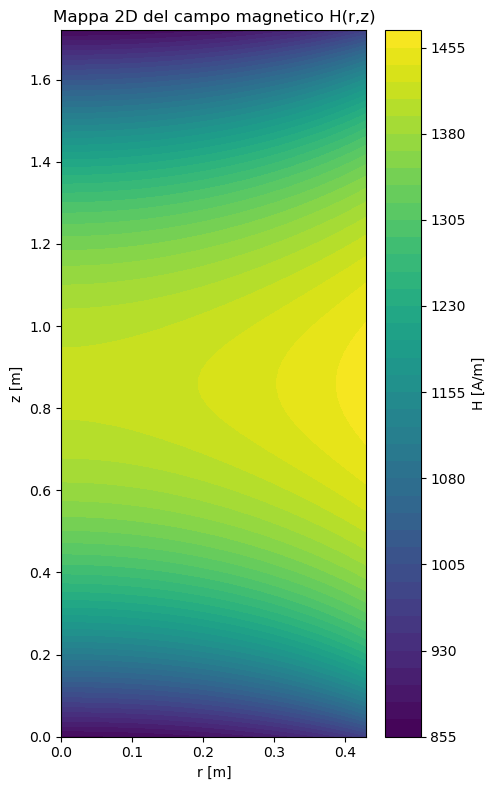

In [7]:
IHTES_2d.plot_H_map(I=135)

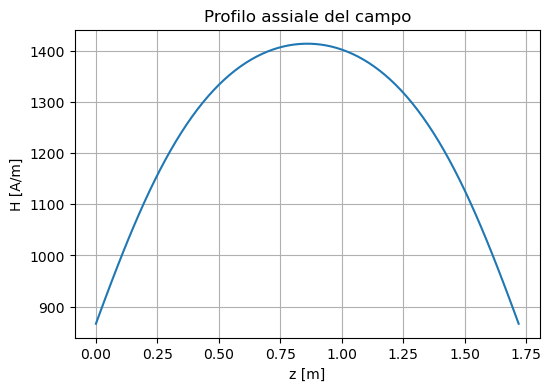

In [8]:
z_ax, H_ax = IHTES_2d.axial_profile(I=135, r_index=0)

plt.figure(figsize=(6,4))
plt.plot(z_ax, H_ax)
plt.xlabel("z [m]")
plt.ylabel("H [A/m]")
plt.title("Profilo assiale del campo")
plt.grid(True)
plt.show()

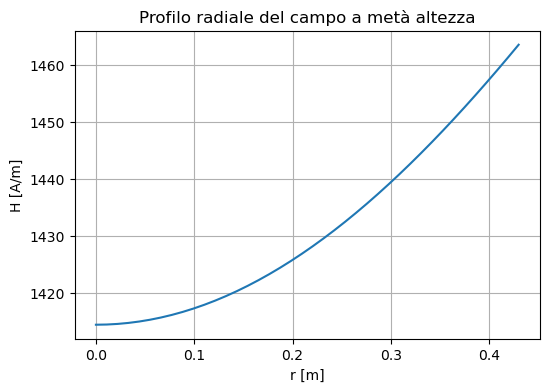

In [9]:
r_mid, H_mid = IHTES_2d.radial_profile(I=135)

plt.figure(figsize=(6,4))
plt.plot(r_mid, H_mid)
plt.xlabel("r [m]")
plt.ylabel("H [A/m]")
plt.title("Profilo radiale del campo a metà altezza")
plt.grid(True)
plt.show()

In [10]:
#valore campo magnetico vecchio modello 
H_old_rms = 135 * IHTES_2d.N / IHTES_2d.H_coil
H_old_peak = np.sqrt(2) * H_old_rms

print("H_old_rms =", H_old_rms, "A/m")
print("H_old_peak =", H_old_peak, "A/m")

H_old_rms = 1799.9999999999998 A/m
H_old_peak = 2545.5844122715707 A/m


In [11]:
#valori max/min/medio campo magentico modello 2D
H_mean = np.mean(H)
H_min = np.min(H)
H_max = np.max(H)

print("H_mean =", H_mean, "A/m")
print("H_min  =", H_min, "A/m")
print("H_max  =", H_max, "A/m")

H_mean = 1267.56200696914 A/m
H_min  = 866.4084038053655 A/m
H_max  = 1463.5041360819996 A/m


In [12]:
#confronto numerico diretto tra nuovo e vecchio modello
print("Rapporto H_mean / H_old_rms =", H_mean / H_old_rms)
print("Rapporto H_max  / H_old_rms =", H_max / H_old_rms)
print("Rapporto H_min  / H_old_rms =", H_min / H_old_rms)

Rapporto H_mean / H_old_rms = 0.7042011149828556
Rapporto H_max  / H_old_rms = 0.8130578533788888
Rapporto H_min  / H_old_rms = 0.481338002114092


In [13]:
#The 2D magnetic field map is consistent with physical expectations. Compared with the previous uniform-field model, the new model predicts a lower field intensity because it accounts for the finite length and finite radius of the coil. The maximum field is reached near the mid-height region and close to the packed-bed wall, while lower values appear near the top and bottom boundaries and near the cylinder axis. The maximum field is about 81% of the ideal uniform-solenoid estimate, which is in very good agreement with the expected finite-solenoid correction.

In [14]:
freq = 10e3
Icoil = 135
T_ref = 20 + 273.15

In [15]:
delta_p = IHTES_2d.depth_p(freq)
F_val = IHTES_2d.F(freq)

print("delta_p =", delta_p, "m")
print("F(freq) =", F_val)

delta_p = 0.15915494309189532 m
F(freq) = 6.201244261672085e-05


In [16]:
q_hys = IHTES_2d.qhys_map(freq, Icoil, T_ref)
q_eddy = IHTES_2d.qeddy_map(freq, Icoil)
q_ind = IHTES_2d.qind_map(freq, Icoil, T_ref)

In [17]:
P_hys_cells = IHTES_2d.Phys_cells(freq, Icoil, T_ref)
P_eddy_cells = IHTES_2d.Peddy_cells(freq, Icoil)
P_ind_cells = IHTES_2d.Pind_cells(freq, Icoil, T_ref)

In [18]:
P_hys_sum = np.sum(P_hys_cells)
P_eddy_sum = np.sum(P_eddy_cells)
P_ind_sum = np.sum(P_ind_cells)

P_hys_old = IHTES_2d.Phys(freq, Icoil, T_ref)
P_eddy_old = IHTES_2d.Peddy(freq, Icoil)
P_ind_old = IHTES_2d.Pind(freq, Icoil, T_ref)

print("P_hys_sum =", P_hys_sum, "W")
print("P_hys_old =", P_hys_old, "W")
print()

print("P_eddy_sum =", P_eddy_sum, "W")
print("P_eddy_old =", P_eddy_old, "W")
print()

print("P_ind_sum =", P_ind_sum, "W")
print("P_ind_old =", P_ind_old, "W")

P_hys_sum = 6206.923292699848 W
P_hys_old = 15774.435731800466 W

P_eddy_sum = 2552.013184375037 W
P_eddy_old = 2457.0046676048096 W

P_ind_sum = 8758.936477074885 W
P_ind_old = 18231.440399405277 W


In [19]:
print("q_hys shape =", q_hys.shape)
print("q_eddy shape =", q_eddy.shape)
print("q_ind shape =", q_ind.shape)
print("P_hys_cells shape =", P_hys_cells.shape)
print("P_eddy_cells shape =", P_eddy_cells.shape)
print("P_ind_cells shape =", P_ind_cells.shape)

q_hys shape = (40, 80)
q_eddy shape = (40, 80)
q_ind shape = (40, 80)
P_hys_cells shape = (40, 80)
P_eddy_cells shape = (40, 80)
P_ind_cells shape = (40, 80)


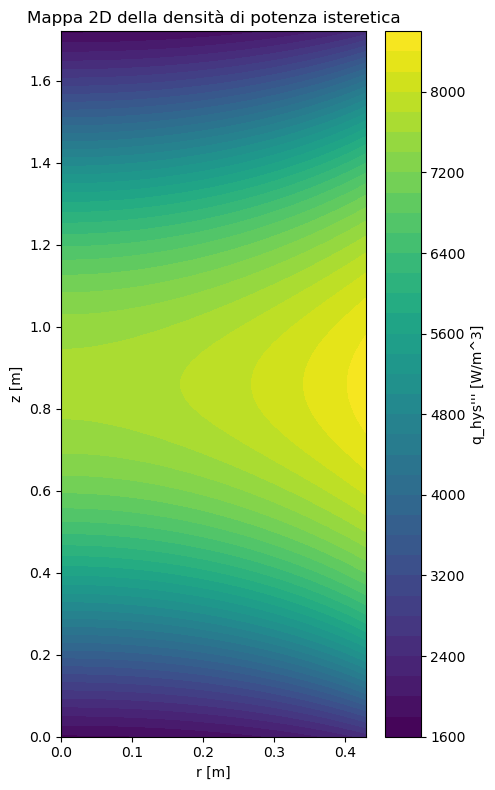

In [20]:
IHTES_2d.plot_scalar_map(
    q_hys,
    title="Mappa 2D della densità di potenza isteretica",
    cbar_label="q_hys''' [W/m^3]"
)

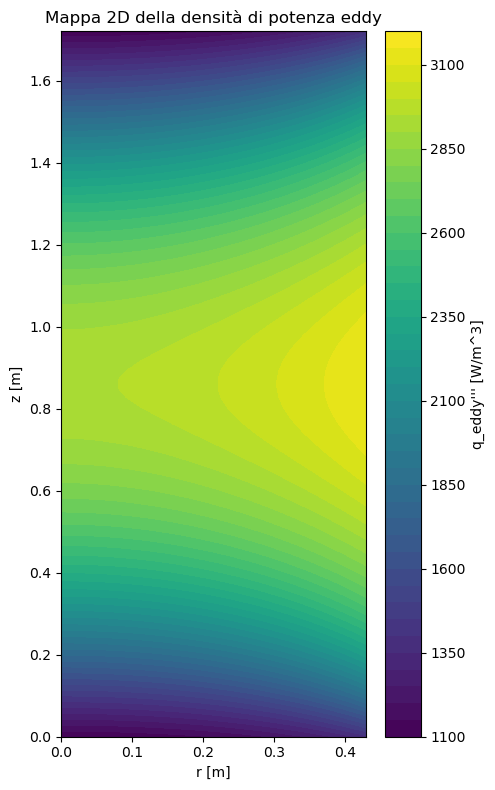

In [21]:
IHTES_2d.plot_scalar_map(
    q_eddy,
    title="Mappa 2D della densità di potenza eddy",
    cbar_label="q_eddy''' [W/m^3]"
)

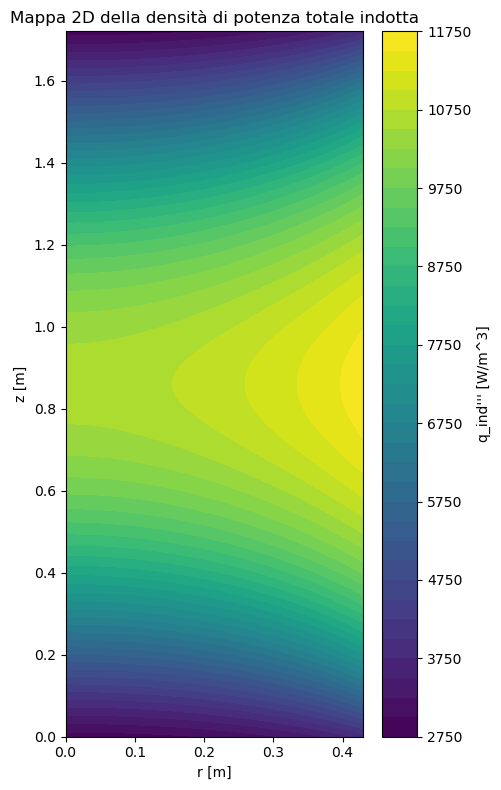

In [22]:
IHTES_2d.plot_scalar_map(
    q_ind,
    title="Mappa 2D della densità di potenza totale indotta",
    cbar_label="q_ind''' [W/m^3]"
)

In [23]:
ratio_hys_eddy = q_hys / q_eddy

print("ratio min =", np.min(ratio_hys_eddy))
print("ratio max =", np.max(ratio_hys_eddy))
print("ratio mean =", np.mean(ratio_hys_eddy))

ratio min = 1.5980915984395718
ratio max = 2.6962925692253066
ratio mean = 2.3361961071942647


In [24]:
#The hysteretic heating contribution is dominant throughout the entire packed bed, since the local ratio qhys/qeddy is always larger than 1. However, the ratio is not spatially uniform: it increases in the mid-height region and close to the outer wall, where the magnetic field is stronger. This means that both contributions follow the same general field distribution, but hysteresis becomes relatively more important in the high-field regions.

In [25]:
freq = 10e3
Icoil = 200

T_init = 20 + 273.15
T_amb = 20 + 273.15

ch_time = 4*3600   # 4 ore
dt = 10.0        # 10 secondi

In [26]:
dt_lim = IHTES_2d.explicit_dt_limit()
print("dt_lim =", dt_lim, "s")

dt_lim = 16.692218334041925 s


In [27]:
time, T_mean, T_max, T_final, snapshot_times, snapshots, q_src, h_eq = IHTES_2d.charging_2D(
    freq=freq,
    I=Icoil,
    T_init=T_init,
    T_amb=T_amb,
    ch_time=ch_time,
    dt=dt,
    T_ref_source=T_init,
    k_eff=IHTES_2d.k_s,
    save_every=100
)

In [28]:
print("h_eq =", h_eq, "W/m^2/K")
print("T_mean final =", T_mean[-1], "K")
print("T_max final  =", T_max[-1], "K")
print("T_final shape =", T_final.shape)

h_eq = 0.2060045168552347 W/m^2/K
T_mean final = nan K
T_max final  = nan K
T_final shape = (40, 80)


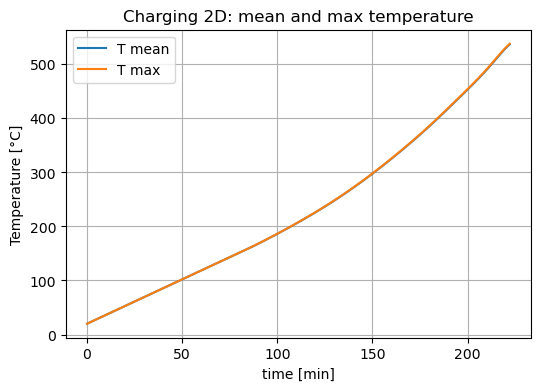

In [29]:
plt.figure(figsize=(6,4))
plt.plot(time/60, T_mean - 273.15, label="T mean")
plt.plot(time/60, T_max - 273.15, label="T max")
plt.xlabel("time [min]")
plt.ylabel("Temperature [°C]")
plt.title("Charging 2D: mean and max temperature")
plt.grid(True)
plt.legend()
plt.show()

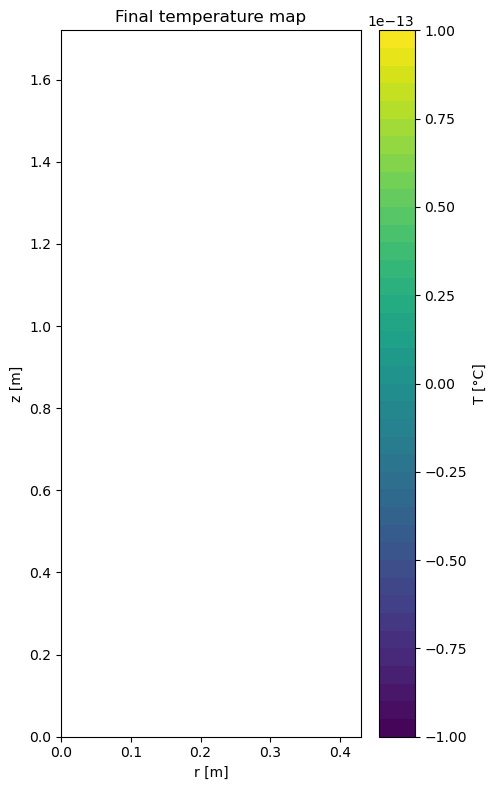

In [30]:
IHTES_2d.plot_scalar_map(
    T_final - 273.15,
    title="Final temperature map",
    cbar_label="T [°C]"
)

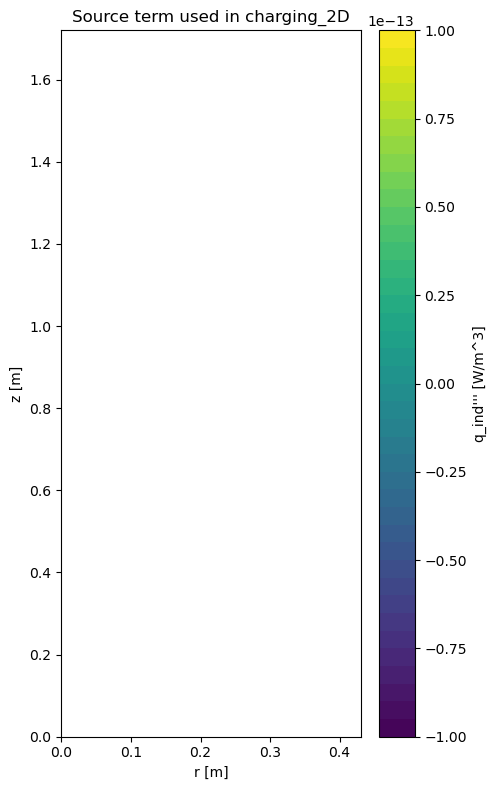

In [31]:
IHTES_2d.plot_scalar_map(
    q_src,
    title="Source term used in charging_2D",
    cbar_label="q_ind''' [W/m^3]"
)

In [32]:
from class_IHTES import IHTES

In [33]:
IHTES_old = IHTES(TH_mag, EM_mag, HYS_mag, geom_1)

In [34]:
freq = 10e3
Icoil = 135
T_ref = 20 + 273.15

qv_old = IHTES_old.qv(freq, Icoil, T_ref)
qv_hys_old = IHTES_old.qv_hys(freq, Icoil, T_ref)
qv_eddy_old = IHTES_old.qv_eddy(freq, Icoil)

print("qv_old =", qv_old, "W/m^3")
print("qv_hys_old =", qv_hys_old, "W/m^3")
print("qv_eddy_old =", qv_eddy_old, "W/m^3")

qv_old = 18247.59995503936 W/m^3
qv_hys_old = 15788.41750538609 W/m^3
qv_eddy_old = 2459.1824496532677 W/m^3


In [35]:
time, T_TES, history, E_ch, E_amb, E_coil, E_in = IHTES_old.charging(
    freq,
    Icoil,
    60 + 273.15,
    20 + 273.15,
    20 + 273.15,
    4 * 3600,
    10.0
)

print("T_final old model =", T_TES[-1] - 273.15, "°C")

T_final old model = 146.3981870973584 °C


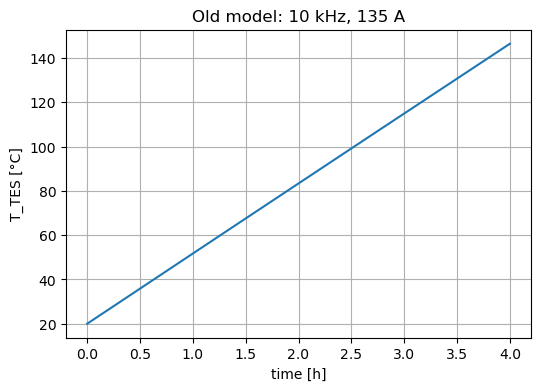

In [36]:
plt.figure(figsize=(6,4))
plt.plot(time/3600, T_TES - 273.15)
plt.xlabel("time [h]")
plt.ylabel("T_TES [°C]")
plt.title("Old model: 10 kHz, 135 A")
plt.grid(True)
plt.show()

In [37]:
freq=10e3
Icoil=135
T_ref=20+273.15
qv_old=IHTES_old.qv(freq, Icoil, T_ref)
print(qv_old)

18247.59995503936


In [38]:
I_target_est = 135 * np.sqrt(56e3 / qv_old)
print(I_target_est)

236.49660266412695


In [39]:
 for I in [180, 190, 200]:

    print(I, IHTES_old.qv(10e3, I, T_ref)/1000)

180 41.716444111728975
190 48.76735902940049
200 56.565442795347714


In [40]:
#VALIDAZIONE MODELLO 2D: INSERIRE STESSE IPOTESI DI PARTENZA DI FAMIGLIETTI NEL MIO MODELLO E VRIFICARE CHE CO DA GLI STESSI RISULTATI

In [41]:
#STEP 1 : validazione sorgente uniforme

In [42]:
freq = 10e3
Icoil = 135
T_ref = 20 + 273.15

In [43]:
H_old_rms = IHTES_old.Hf(Icoil)
H_old_peak = IHTES_old.Hmf(Icoil)

print("H_old_rms =", H_old_rms, "A/m")
print("H_old_peak =", H_old_peak, "A/m")

H_old_rms = 1799.9999999999998 A/m
H_old_peak = 2545.5844122715707 A/m


In [44]:
H_uniform = np.full_like(IHTES_2d.R, H_old_rms, dtype=float)
H_uniform_peak = np.full_like(IHTES_2d.R, H_old_peak, dtype=float)

In [45]:
q_hys_uniform = IHTES_2d.Phys_sp(H_uniform_peak, T_ref, freq) * IHTES_2d.rho_s * (1.0 - IHTES_2d.e)
q_eddy_uniform = np.full_like(IHTES_2d.R, IHTES_old.qv_eddy(freq, Icoil), dtype=float)
q_ind_uniform = q_hys_uniform + q_eddy_uniform

In [46]:
qhys_avg_uniform = IHTES_2d.volume_average(q_hys_uniform)
qeddy_avg_uniform = IHTES_2d.volume_average(q_eddy_uniform)
qind_avg_uniform = IHTES_2d.volume_average(q_ind_uniform)

qhys_old = IHTES_old.qv_hys(freq, Icoil, T_ref)
qeddy_old = IHTES_old.qv_eddy(freq, Icoil)
qind_old = IHTES_old.qv(freq, Icoil, T_ref)

print("qhys_avg_uniform =", qhys_avg_uniform, "W/m^3")
print("qhys_old         =", qhys_old, "W/m^3")
print()

print("qeddy_avg_uniform =", qeddy_avg_uniform, "W/m^3")
print("qeddy_old         =", qeddy_old, "W/m^3")
print()

print("qind_avg_uniform =", qind_avg_uniform, "W/m^3")
print("qind_old         =", qind_old, "W/m^3")

qhys_avg_uniform = 15788.417505386093 W/m^3
qhys_old         = 15788.41750538609 W/m^3

qeddy_avg_uniform = 2459.1824496532677 W/m^3
qeddy_old         = 2459.1824496532677 W/m^3

qind_avg_uniform = 18247.59995503936 W/m^3
qind_old         = 18247.59995503936 W/m^3


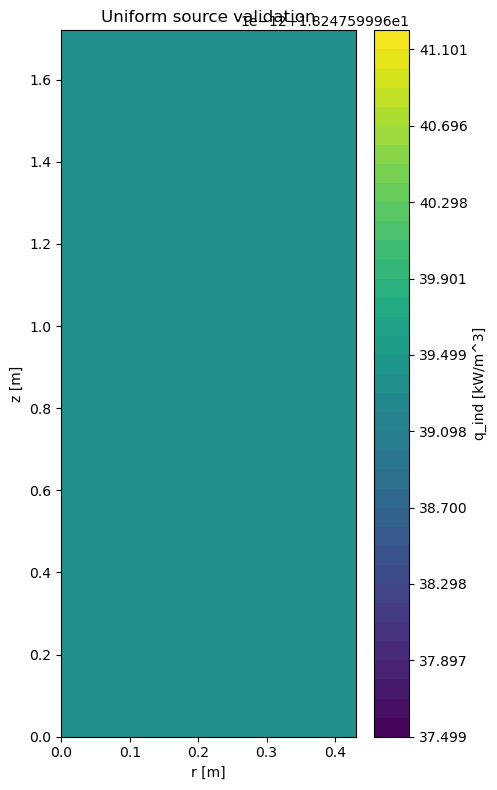

In [47]:
IHTES_2d.plot_scalar_map(
    q_ind_uniform / 1000,
    title="Uniform source validation",
    cbar_label="q_ind [kW/m^3]"
)
#CONTROLLO VISIVO

In [48]:
#COMMENTI:Sotto l’ipotesi di campo uniforme, il nuovo framework 2D riproduce correttamente la densità di potenza media del modello di Famiglietti

In [49]:
#STEP 2: validazione parte termica

In [50]:
import importlib
import class_IHTES
import class_IHTES_2D

importlib.reload(class_IHTES)
importlib.reload(class_IHTES_2D)

from class_IHTES import IHTES
from class_IHTES_2D import IHTES2D

In [51]:
IHTES_old = IHTES(TH_mag, EM_mag, HYS_mag, geom_1)
IHTES_2d  = IHTES2D(TH_mag, EM_mag, HYS_mag, geom_1, mesh=(40, 80))

In [52]:
Icoil = 1060.6601717798214
freq_work = 80.0

Tcoil = 60 + 273.15
T_init = 20 + 273.15
T_amb  = 20 + 273.15

ch_time = 4 * 3600
dt = 10.0

In [53]:
time_old, T_old, history_old, E_ch_old, E_amb_old, E_coil_old, E_in_old = IHTES_old.charging(
    freq_work,
    Icoil,
    Tcoil,
    T_init,
    T_amb,
    ch_time,
    dt
)

print("T_final old model =", T_old[-1] - 273.15, "°C")

T_final old model = 374.90027581105403 °C


In [54]:
time_new, T_mean_new, T_max_new, T_map_final, snapshot_times, snapshots, q_src, h_eq = IHTES_2d.charging_2D(
    freq=freq_work,
    I=Icoil,
    T_init=T_init,
    T_amb=T_amb,
    ch_time=ch_time,
    dt=dt,
    T_ref_source=T_init,
    k_eff=IHTES_2d.k_s,
    save_every=100
)

print("T_final new model (mean) =", T_mean_new[-1] - 273.15, "°C")
print("T_final new model (max)  =", T_max_new[-1] - 273.15, "°C")
print("q_src mean =", np.mean(q_src))

T_final new model (mean) = 375.5628501159456 °C
T_final new model (max)  = 376.4398491542994 °C
q_src mean = 43041.06038261448


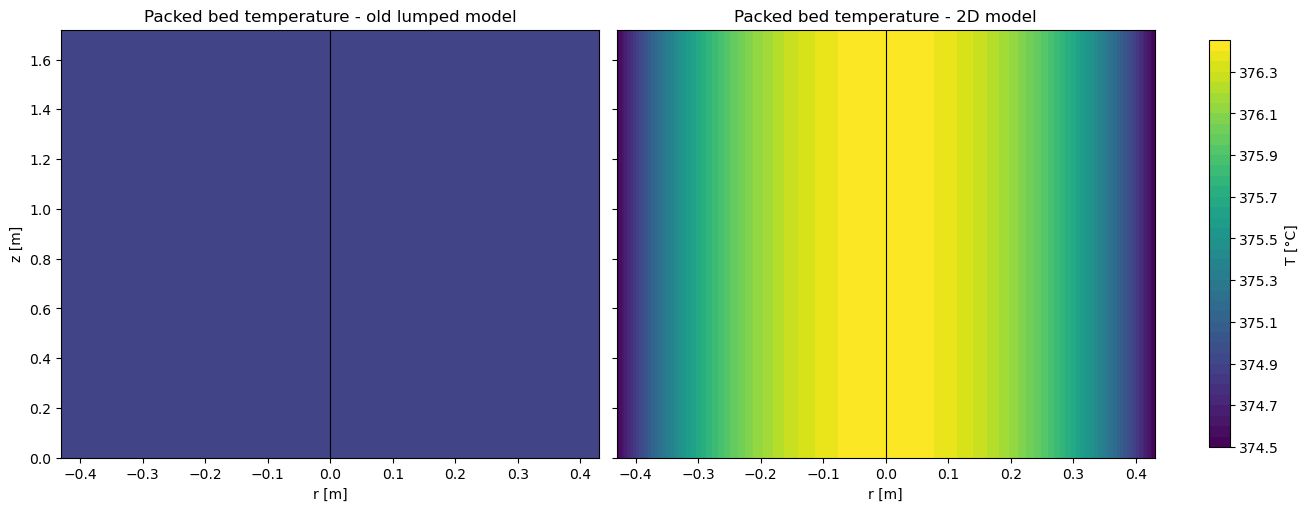

In [55]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Confronto mappe finali di temperatura nel PB
# ==========================================

# Temperature finali in °C
T_old_final_C = T_old[-1] - 273.15
T_2d_final_C  = T_map_final - 273.15

# Dimensioni dominio
Nr, Nz = T_map_final.shape
R_pb = IHTES_2d.R_TES
Z_pb = IHTES_2d.Z_TES

# Coordinate semidominio r >= 0
r_pos = np.linspace(0.0, R_pb, Nr)
z = np.linspace(0.0, Z_pb, Nz)

# Asse radiale completo simmetrico
r_full = np.concatenate((-r_pos[:0:-1], r_pos))

# Mappa uniforme del modello lumped
T_old_half = np.full((Nr, Nz), T_old_final_C)

# Simmetrizzazione sinistra-destra
T_old_full = np.concatenate((np.flipud(T_old_half[1:, :]), T_old_half), axis=0)
T_2d_full  = np.concatenate((np.flipud(T_2d_final_C[1:, :]), T_2d_final_C), axis=0)

# Stessa scala colori
vmin = min(T_old_full.min(), T_2d_full.min())
vmax = max(T_old_full.max(), T_2d_full.max())

fig, ax = plt.subplots(1, 2, figsize=(13, 5), sharey=True, constrained_layout=True)

# --- Old model ---
cf1 = ax[0].contourf(r_full, z, T_old_full.T, levels=40, cmap="viridis", vmin=vmin, vmax=vmax)
ax[0].axvline(0, color='k', linewidth=0.8)
ax[0].set_title("Packed bed temperature - old lumped model")
ax[0].set_xlabel("r [m]")
ax[0].set_ylabel("z [m]")

# --- 2D model ---
cf2 = ax[1].contourf(r_full, z, T_2d_full.T, levels=40, cmap="viridis", vmin=vmin, vmax=vmax)
ax[1].axvline(0, color='k', linewidth=0.8)
ax[1].set_title("Packed bed temperature - 2D model")
ax[1].set_xlabel("r [m]")

# Colorbar comune
cbar = fig.colorbar(cf2, ax=ax, shrink=0.95)
cbar.set_label("T [°C]")

plt.show()

In [56]:
#VALIDAZIONE TERMICA COMPLETATA

In [57]:
#facciamo un breve check per vedere se quando usiamo il campo 2D ci sono dei punti che sono sotto i 12kA/m nel mio modello considerando campo magnetico non uniforme ( con 1066A e 80 Hz)

In [58]:
_, _, _, H_rms_map = IHTES_2d.field_map(Icoil)
H_peak_map = np.sqrt(2.0) * H_rms_map

W = IHTES_2d.volume_weights()

H_mean_kAm = np.sum(H_peak_map * W) / np.sum(W) / 1000
H_min_kAm  = np.min(H_peak_map) / 1000
H_max_kAm  = np.max(H_peak_map) / 1000

frac_below_12 = 100 * np.sum(W[H_peak_map < 12e3]) / np.sum(W)
frac_below_20 = 100 * np.sum(W[H_peak_map < 20e3]) / np.sum(W)

print("H_peak mean [kA/m] =", H_mean_kAm)
print("H_peak min  [kA/m] =", H_min_kAm)
print("H_peak max  [kA/m] =", H_max_kAm)
print("Volume fraction with H < 12 kA/m [%] =", frac_below_12)
print("Volume fraction with H < 20 kA/m [%] =", frac_below_20)

H_peak mean [kA/m] = 14.259149092871748
H_peak min  [kA/m] = 9.626760042281838
H_peak max  [kA/m] = 16.261157067577773
Volume fraction with H < 12 kA/m [%] = 14.988789237668161
Volume fraction with H < 20 kA/m [%] = 100.0


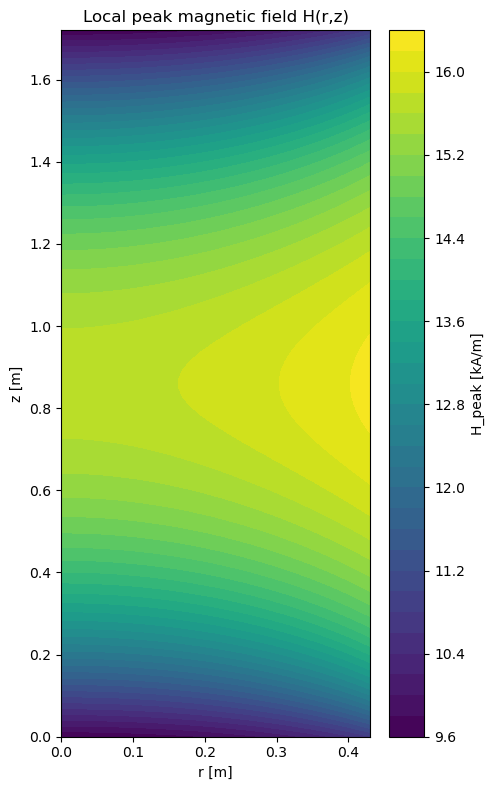

In [59]:
IHTES_2d.plot_scalar_map(
    H_peak_map / 1000,
    title="Local peak magnetic field H(r,z)",
    cbar_label="H_peak [kA/m]"
)

In [60]:
#non va bene, abbiamo un sacco di parti che sono sotto i 12kA/m e probabilmente ancora piu punti dove LangArc funzionerà al contrario, quidni ora cerchiamo un modo per avere il 100% del PB dove LangArc funziona bene

In [61]:
#serve una corrente tale per cui ogni punto di Hm del PB sia maggiore di 19,2 kA/m che è il valore critico per far funzionare bene LangArc 

In [62]:
H_test_kAm = np.linspace(12, 25, 131)   # passo 0.1 kA/m
T_list_C = [200, 300, 400, 500]
T_list_K = [T + 273.15 for T in T_list_C]

rows = []

for Hk in H_test_kAm:
    H = Hk * 1000.0
    
    A200 = IHTES_old.A_LARC(H, T_list_K[0])
    A300 = IHTES_old.A_LARC(H, T_list_K[1])
    A400 = IHTES_old.A_LARC(H, T_list_K[2])
    A500 = IHTES_old.A_LARC(H, T_list_K[3])
    
    ok = (A200 > A300 > A400 > A500)
    
    rows.append({
        "H [kA/m]": Hk,
        "A200": A200,
        "A300": A300,
        "A400": A400,
        "A500": A500,
        "LangArc_ok": ok
    })

crit_df = pd.DataFrame(rows)
crit_df.head()

,H [kA/m],A200,A300,A400,A500,LangArc_ok
0,12.0,2.450657e+08,3.019569e+08,2.904334e+08,1.680105e+08,False
1,12.1,2.507878e+08,3.082128e+08,2.952809e+08,1.695755e+08,False
2,12.2,2.565857e+08,3.145219e+08,3.001376e+08,1.711270e+08,False
3,12.3,2.624596e+08,3.208835e+08,3.050026e+08,1.726653e+08,False
4,12.4,2.684092e+08,3.272966e+08,3.098751e+08,1.741903e+08,False


In [63]:
ok_df = crit_df[crit_df["LangArc_ok"] == True]

Hcrit_kAm = ok_df.iloc[0]["H [kA/m]"]
print("Critical field Hcrit [kA/m] =", Hcrit_kAm)

Critical field Hcrit [kA/m] = 19.2


In [64]:
#troviamo ora il valore giusto di corrente e verifichiamo la nuova mappa

In [65]:
Hsafe_kAm = 20.0

In [66]:
_, _, _, H_rms_map = IHTES_2d.field_map(Icoil)
H_peak_map = np.sqrt(2.0) * H_rms_map
H_peak_kAm = H_peak_map / 1000.0

print("Current Icoil [A] =", Icoil)
print("Current H_min [kA/m]  =", H_peak_kAm.min())
print("Current H_mean [kA/m] =", H_peak_kAm.mean())
print("Current H_max [kA/m]  =", H_peak_kAm.max())

Current Icoil [A] = 1060.6601717798214
Current H_min [kA/m]  = 9.626760042281838
Current H_mean [kA/m] = 14.084022299657112
Current H_max [kA/m]  = 16.261157067577773


In [67]:
Hmin_current_kAm = H_peak_kAm.min()

Icoil_safe = Icoil * (Hsafe_kAm / Hmin_current_kAm)

print("Current needed for H_min >= 20 kA/m [A] =", Icoil_safe)

Current needed for H_min >= 20 kA/m [A] = 2203.5662406069746


In [68]:
_, _, _, H_rms_map_safe = IHTES_2d.field_map(Icoil_safe)
H_peak_map_safe = np.sqrt(2.0) * H_rms_map_safe
H_peak_kAm_safe = H_peak_map_safe / 1000.0

W = IHTES_2d.volume_weights()

print("New H_min [kA/m]  =", H_peak_kAm_safe.min())
print("New H_mean [kA/m] =", np.sum(H_peak_kAm_safe * W) / np.sum(W))
print("New H_max [kA/m]  =", H_peak_kAm_safe.max())

frac_above_20 = 100 * np.sum(W[H_peak_kAm_safe >= 20.0]) / np.sum(W)
print("Volume fraction above 20 kA/m [%] =", frac_above_20)

New H_min [kA/m]  = 19.999999999999996
New H_mean [kA/m] = 29.623983625319262
New H_max [kA/m]  = 33.783239628196625
Volume fraction above 20 kA/m [%] = 99.99919923126201


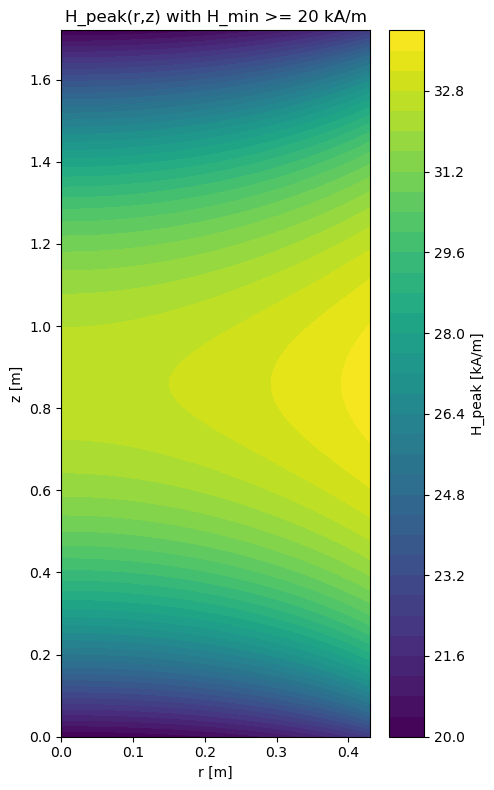

In [69]:
IHTES_2d.plot_scalar_map(
    H_peak_kAm_safe,
    title="H_peak(r,z) with H_min >= 20 kA/m",
    cbar_label="H_peak [kA/m]"
)

In [70]:
#abbiamo verificato che con quel valore di corrente trovato tutto il packed bed è sopra ai 20 kA/m che abbiamo imposto come limite inferiore

In [71]:
#veirfichiamo ora LangArc per tutte le celle

In [72]:
T_list_C = [200, 300, 400, 500]
T_list_K = [T + 273.15 for T in T_list_C]

A_maps_safe = {}

for Tc, Tk in zip(T_list_C, T_list_K):
    A_maps_safe[Tc] = IHTES_old.A_LARC(H_peak_map_safe, Tk)

In [73]:
good_LARC_mask_safe = (
    (A_maps_safe[200] > A_maps_safe[300]) &
    (A_maps_safe[300] > A_maps_safe[400]) &
    (A_maps_safe[400] > A_maps_safe[500])
)

frac_good_all = 100 * np.sum(W[good_LARC_mask_safe]) / np.sum(W)
frac_bad_all  = 100 - frac_good_all

print("Fraction of PB where LangArc behaves correctly [%] =", frac_good_all)
print("Fraction of PB where LangArc is problematic [%]    =", frac_bad_all)

Fraction of PB where LangArc behaves correctly [%] = 100.0
Fraction of PB where LangArc is problematic [%]    = 0.0


In [74]:
#verificato che LangArc funziona bene ovunque

In [75]:
#ora vediamo a questi valori di corrente e di campo magnetico, con 80 Hz, a che temperatura arirviamo dopo 3 ore considerando la non uniformità del modello

In [76]:
import importlib
import class_IHTES_2D
importlib.reload(class_IHTES_2D)

from class_IHTES_2D import IHTES2D

In [77]:
IHTES_2d = IHTES2D(TH_mag, EM_mag, HYS_mag, geom_1, mesh=(40, 80))

In [78]:
freq_work = 80.0
Icoil_safe = 2203.5662406069746   # quello che avevi trovato per H_min >= 20 kA/m

T_init = 20 + 273.15
T_amb  = 20 + 273.15
dt = 10.0

In [79]:
freq_nonuni = freq_work
I_nonuni = Icoil_safe
ch_time_nonuni = 3 * 3600
dt_nonuni = dt

time_nonuni, T_mean_nonuni, T_max_nonuni, T_map_nonuni, snapshot_times_nonuni, snapshots_nonuni, q_src_nonuni, h_eq_nonuni = IHTES_2d.charging_2D_nonuniform(
    freq=freq_nonuni,
    I=I_nonuni,
    T_init=T_init,
    T_amb=T_amb,
    ch_time=ch_time_nonuni,
    dt=dt_nonuni,
    T_ref_source=T_init,
    k_eff=IHTES_2d.k_s,
    save_every=100
)

print("T_mean after 3 h [°C] =", T_mean_nonuni[-1] - 273.15)
print("T_max  after 3 h [°C] =", T_max_nonuni[-1] - 273.15)
print("q_src mean [W/m^3]    =", np.mean(q_src_nonuni))

T_mean after 3 h [°C] = 462.36385237187767
T_max  after 3 h [°C] = 525.9932262307182
q_src mean [W/m^3]    = 33422.47587662016


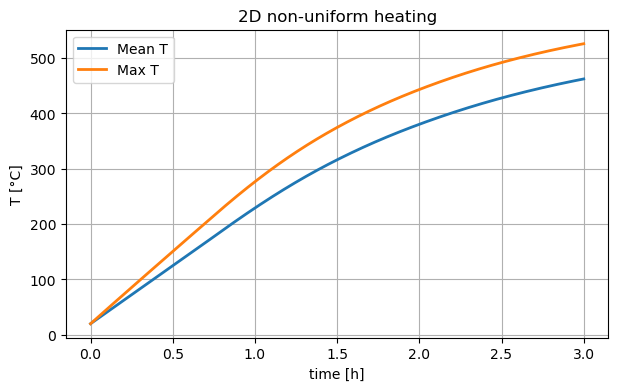

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.plot(time_nonuni/3600, T_mean_nonuni - 273.15, linewidth=2, label="Mean T")
plt.plot(time_nonuni/3600, T_max_nonuni - 273.15, linewidth=2, label="Max T")
plt.xlabel("time [h]")
plt.ylabel("T [°C]")
plt.title("2D non-uniform heating")
plt.grid(True)
plt.legend()
plt.show()

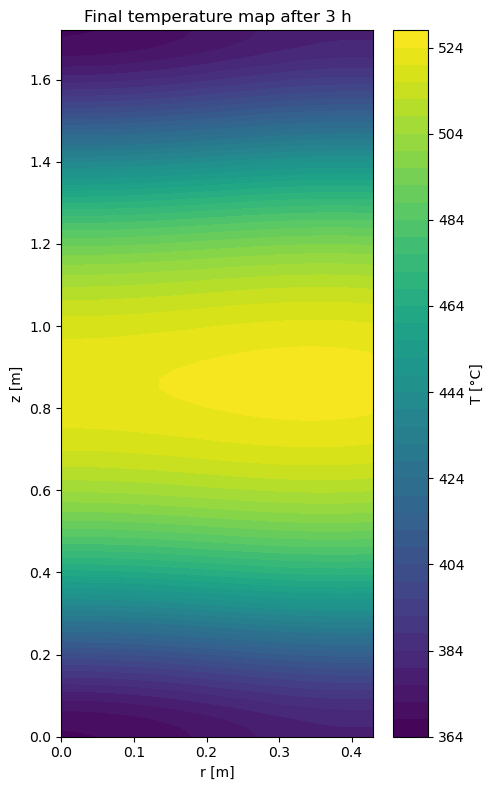

In [81]:
IHTES_2d.plot_scalar_map(
    T_map_nonuni - 273.15,
    title="Final temperature map after 3 h",
    cbar_label="T [°C]"
)

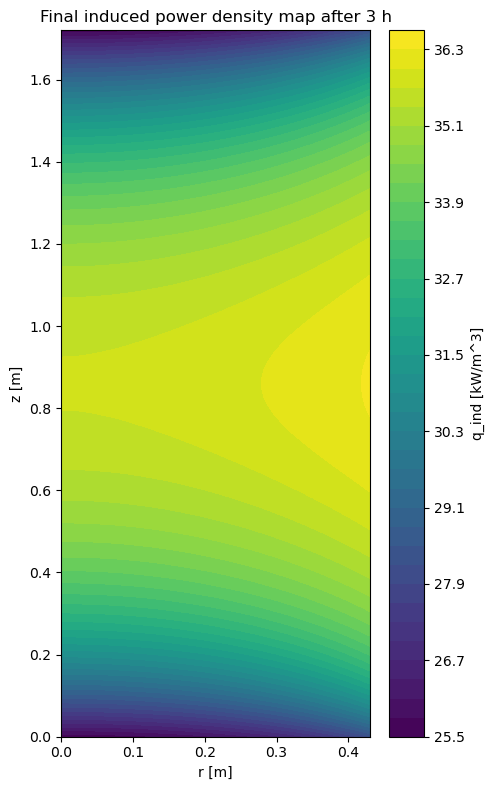

In [82]:
IHTES_2d.plot_scalar_map(
    q_src_nonuni / 1000,
    title="Final induced power density map after 3 h",
    cbar_label="q_ind [kW/m^3]"
)

In [83]:
#tutto ok

In [84]:
#ora migliornamo il modello aggiungendo la dipendenza dalla T di alcuni parametri (termici) della magnetite, cioè il cp e la conducibilità teermica k

In [85]:
#abbiamo creato su spyder u altro file .py IHTES2D copiandolo dal precedente e modifcandolo aggiungendo questi cambiamenti (cosi che quello di prima rimane comuqnue ancora valido)

In [86]:
import importlib
import class_IHTES_2D_Tdep

importlib.reload(class_IHTES_2D_Tdep)

from class_IHTES_2D_Tdep import IHTES2D_Tdep

In [87]:
tes2d = IHTES2D_Tdep(TH_mag, EM_mag, HYS_mag, geom_1, mesh=(20, 40))

In [91]:
tes2d = IHTES2D_Tdep(TH_mag, EM_mag, HYS_mag, geom_1, mesh=(20, 40))

freq = 80
I = 2203
T_init = 293.15
T_amb = 293.15
ch_time = 3 * 3600
dt = 10.0

time, T_mean, T_max, T_final, snapshot_times, snapshots, q_src, h_eq, q_mean, q_max = tes2d.charging_2D_nonuniform_Tdep(
    freq=freq,
    I=I,
    T_init=T_init,
    T_amb=T_amb,
    ch_time=ch_time,
    dt=dt,
    save_every=30
)

print("T media finale [°C] =", T_mean[-1] - 273.15)
print("T max finale [°C] =", T_max[-1] - 273.15)
print("q media finale [kW/m3] =", q_mean[-1] / 1000)
print("q max finale [kW/m3] =", q_max[-1] / 1000)

T media finale [°C] = 418.1429593553694
T max finale [°C] = 446.54416800653064
q media finale [kW/m3] = 48.190265456408966
q max finale [kW/m3] = 57.3277035097269


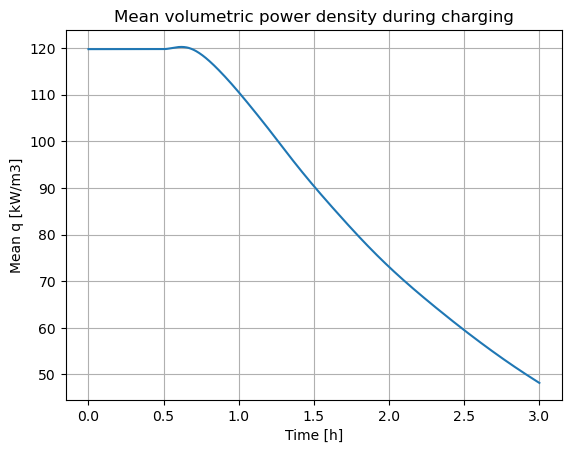

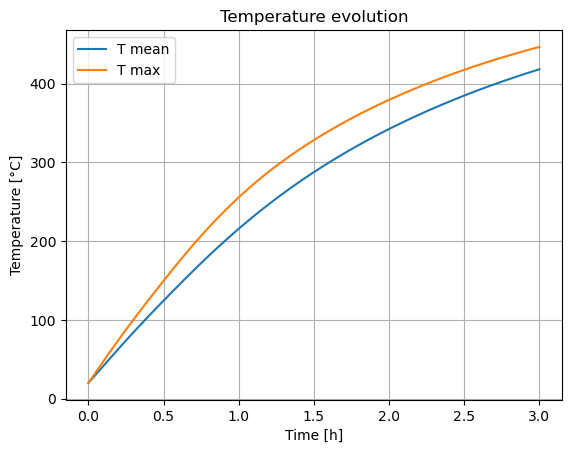

In [92]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(time/3600, q_mean/1000)
plt.xlabel("Time [h]")
plt.ylabel("Mean q [kW/m3]")
plt.title("Mean volumetric power density during charging")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(time/3600, T_mean - 273.15, label="T mean")
plt.plot(time/3600, T_max - 273.15, label="T max")
plt.xlabel("Time [h]")
plt.ylabel("Temperature [°C]")
plt.title("Temperature evolution")
plt.legend()
plt.grid(True)
plt.show()

In [93]:
# come era prevedibile, inserendo la dipendenza dalla T di cp e k, la temperatura finale dopo 3 ore diminuisce

In [ ]:
#useremo la mash 20x40 poichè praticamente a parità di risultato con 30x60 ci mette 10mminuti, l'altra ci mette 35 minuti ( con stesso dt=10)

In [94]:
import importlib
import class_IHTES_2D_Tdep

importlib.reload(class_IHTES_2D_Tdep)

from class_IHTES_2D_Tdep import IHTES2D_Tdep

tes2d = IHTES2D_Tdep(TH_mag, EM_mag, HYS_mag, geom_1, mesh=(20, 40))

In [95]:
print(T_final.shape)
print(tes2d.R.shape)

(20, 40)
(20, 40)


In [96]:
q_eddy_const = tes2d.qeddy_map(freq, I)
q_hys_local = tes2d.qhys_map_Tlocal(freq, I, T_final)

q_eddy_mean = tes2d.volume_average(q_eddy_const)
q_hys_mean = tes2d.volume_average(q_hys_local)
q_tot_mean = q_eddy_mean + q_hys_mean

print("q_eddy mean [kW/m3] =", q_eddy_mean / 1000)
print("q_hys mean [kW/m3]  =", q_hys_mean / 1000)
print("q_tot mean [kW/m3]  =", q_tot_mean / 1000)
print("Eddy fraction [%]   =", 100 * q_eddy_mean / q_tot_mean)

q_eddy mean [kW/m3] = 0.04191147618229199
q_hys mean [kW/m3]  = 48.092236016850066
q_tot mean [kW/m3]  = 48.13414749303236
Eddy fraction [%]   = 0.08707223118132272


In [ ]:
#NOTIAMO CHE LA PARTE DI EDDY CURRENT è IRRISORIA, TRASCURABILE A QUESTI VALORI DI FREQUENZA 

In [ ]:
#ora aggiungiamo la dipendenza da T di rho e mu, che però agiscono solo su qeddy, quidni ci aspettiamo una temperatura piu o meno uguale

In [6]:
import importlib
import class_IHTES_2D_Tdep

importlib.reload(class_IHTES_2D_Tdep)

from class_IHTES_2D_Tdep import IHTES2D_Tdep

In [7]:
tes2d = IHTES2D_Tdep(TH_mag, EM_mag, HYS_mag, geom_1, mesh=(20, 40))

In [10]:
freq = 80
I = 2203
T_init = 293.15
T_amb = 293.15
ch_time = 3 * 3600
dt = 10.0

time, T_mean, T_max, T_final, snapshot_times, snapshots, q_src, h_eq, q_mean, q_max = tes2d.charging_2D_nonuniform_Tdep(
    freq=freq,
    I=I,
    T_init=T_init,
    T_amb=T_amb,
    ch_time=ch_time,
    dt=dt,
    save_every=30
)

print("T media finale [°C] =", T_mean[-1] - 273.15)
print("T max finale [°C] =", T_max[-1] - 273.15)
print("q media finale [kW/m3] =", q_mean[-1] / 1000)
print("q max finale [kW/m3] =", q_max[-1] / 1000)

T media finale [°C] = 418.31938060398477
T max finale [°C] = 446.7635959231669
q media finale [kW/m3] = 48.242763268152544
q max finale [kW/m3] = 57.37914173003681


In [11]:
q_eddy_old_final = tes2d.qeddy_map(freq, I)
q_eddy_new_final = tes2d.qeddy_map_Tlocal(freq, I, T_final)

q_hys_final = tes2d.qhys_map_Tlocal(freq, I, T_final)

q_eddy_old_mean = tes2d.volume_average(q_eddy_old_final)
q_eddy_new_mean = tes2d.volume_average(q_eddy_new_final)
q_hys_mean = tes2d.volume_average(q_hys_final)

print("q_hys mean finale [kW/m3] =", q_hys_mean / 1000)
print("q_eddy old mean finale [kW/m3] =", q_eddy_old_mean / 1000)
print("q_eddy new mean finale [kW/m3] =", q_eddy_new_mean / 1000)

print("old eddy fraction [%] =", 100 * q_eddy_old_mean / (q_hys_mean + q_eddy_old_mean))
print("new eddy fraction [%] =", 100 * q_eddy_new_mean / (q_hys_mean + q_eddy_new_mean))
print("eddy ratio new/old =", q_eddy_new_mean / q_eddy_old_mean)

q_hys mean finale [kW/m3] = 48.02725064993626
q_eddy old mean finale [kW/m3] = 0.04191147618229199
q_eddy new mean finale [kW/m3] = 0.15936071227620596
old eddy fraction [%] = 0.08718994533819685
new eddy fraction [%] = 0.3307157481531795
eddy ratio new/old = 3.802316854292463


In [ ]:
#aggiungendo la dipendenza dalla T di rho e mu (che influenzano solo la parte eddy) vediamo che la T finiale è leggerissimamente maggiore poichè la parte eddy aumenta per via dell'aumento della conducibilità elettrica della magnetite ocn l'aumentare della T

In [ ]:
#modello reso robusto, aggiunte tutte le dipende dei parametri dalla T

In [ ]:
#aggiungiamo perdite top e bottom

In [7]:
import importlib
import class_IHTES_2D_Tdep

importlib.reload(class_IHTES_2D_Tdep)

from class_IHTES_2D_Tdep import IHTES2D_Tdep

In [8]:
tes2d = IHTES2D_Tdep(TH_mag, EM_mag, HYS_mag, geom_1, mesh=(20, 40))

In [12]:
freq = 80
I = 2203
T_init = 293.15
T_amb = 293.15
ch_time = 3 * 3600
dt = 10.0

time, T_mean, T_max, T_final, snapshot_times, snapshots, q_src, h_eq, q_mean, q_max = tes2d.charging_2D_nonuniform_Tdep(
    freq=freq,
    I=I,
    T_init=T_init,
    T_amb=T_amb,
    ch_time=ch_time,
    dt=dt,
    save_every=30
)

print("T media finale [°C] =", T_mean[-1] - 273.15)
print("T max finale [°C] =", T_max[-1] - 273.15)
print("q media finale [kW/m3] =", q_mean[-1] / 1000)
print("q max finale [kW/m3] =", q_max[-1] / 1000)

print("h_eq side [W/m2K] =", tes2d.last_h_eq_side)
print("h_eq top/bottom [W/m2K] =", tes2d.last_h_eq_top_bottom)

T media finale [°C] = 418.1831829871677
T max finale [°C] = 446.76359585871876
q media finale [kW/m3] = 48.271220926045316
q max finale [kW/m3] = 57.433800594750245
h_eq side [W/m2K] = 0.2060045168552347
h_eq top/bottom [W/m2K] = 0.16868085817584788


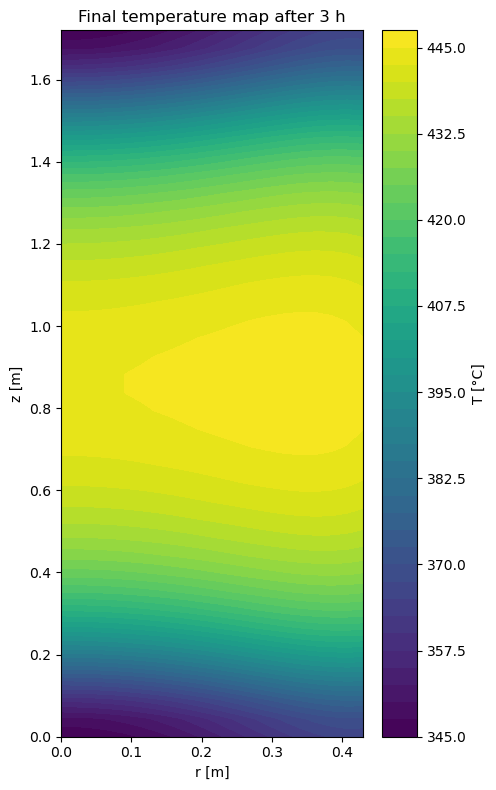

In [14]:
tes2d.plot_scalar_map(
    T_final - 273.15,
    title="Final temperature map after 3 h",
    cbar_label="T [°C]",
    levels=40
)

In [ ]:
#modello completo 

In [ ]:
#professore ha proposto di fare due casi di charging, uno in cui abbiamo solo q_hys e uno in cui abbiamo solo q_eddy

In [ ]:
#quidni lavoriamo in due punti di regime totalmente diverso, uno con correnti altissime e frequenze basse (2200A;80 Hz) e l'altro con correnti basse e frequenze altissime (100A;50kHz)

In [13]:
import importlib
import class_IHTES_2D_Tdep

importlib.reload(class_IHTES_2D_Tdep)

from class_IHTES_2D_Tdep import IHTES2D_Tdep

tes2d = IHTES2D_Tdep(TH_mag, EM_mag, HYS_mag, geom_1, mesh=(20, 40))

In [14]:
[m for m in dir(tes2d) if "qsource" in m or "qind" in m or "qeddy" in m]

['qeddy_map',
 'qeddy_map_Tlocal',
 'qind_map',
 'qind_map_Tlocal',
 'qsource_map_Tlocal']

In [15]:
freq_hys = 80
I_hys = 2203

T_init = 293.15
T_amb = 293.15
ch_time = 3 * 3600
dt = 10.0

time_hys, T_mean_hys, T_max_hys, T_final_hys, snapshot_times_hys, snapshots_hys, q_src_hys, h_eq_hys, q_mean_hys, q_max_hys = tes2d.charging_2D_nonuniform_Tdep(
    freq=freq_hys,
    I=I_hys,
    T_init=T_init,
    T_amb=T_amb,
    ch_time=ch_time,
    dt=dt,
    save_every=30,
    source_mode="hys_only"
)

print("HYSTERESIS ONLY")
print("T media finale [°C] =", T_mean_hys[-1] - 273.15)
print("T max finale [°C] =", T_max_hys[-1] - 273.15)
print("q media finale [kW/m3] =", q_mean_hys[-1] / 1000)
print("q max finale [kW/m3] =", q_max_hys[-1] / 1000)

HYSTERESIS ONLY
T media finale [°C] = 417.9179580196318
T max finale [°C] = 446.4467967719079
q media finale [kW/m3] = 48.208661006867615
q max finale [kW/m3] = 57.37071131795538


In [16]:
freq_eddy = 50000
I_eddy_100 = 100

T_init = 293.15
T_amb = 293.15
ch_time = 3 * 3600
dt = 10.0

time_eddy_100, T_mean_eddy_100, T_max_eddy_100, T_final_eddy_100, snapshot_times_eddy_100, snapshots_eddy_100, q_src_eddy_100, h_eq_eddy_100, q_mean_eddy_100, q_max_eddy_100 = tes2d.charging_2D_nonuniform_Tdep(
    freq=freq_eddy,
    I=I_eddy_100,
    T_init=T_init,
    T_amb=T_amb,
    ch_time=ch_time,
    dt=dt,
    save_every=30,
    source_mode="eddy_only"
)

print("EDDY ONLY - 50 kHz")
print("I_eddy [A] =", I_eddy_100)
print("T media finale [°C] =", T_mean_eddy_100[-1] - 273.15)
print("T max finale [°C] =", T_max_eddy_100[-1] - 273.15)
print("q media finale [kW/m3] =", q_mean_eddy_100[-1] / 1000)
print("q max finale [kW/m3] =", q_max_eddy_100[-1] / 1000)

EDDY ONLY - 50 kHz
I_eddy [A] = 100
T media finale [°C] = 331.1310857218002
T max finale [°C] = 434.9291855294463
q media finale [kW/m3] = 112.50946153444207
q max finale [kW/m3] = 167.28138202408806


In [17]:
# Salvataggio simbolico dei due casi principali

case_hys = {
    "freq": 80,
    "I": 2203,
    "time": time_hys,
    "T_mean": T_mean_hys,
    "T_max": T_max_hys,
    "T_final": T_final_hys,
    "snapshot_times": snapshot_times_hys,
    "snapshots": snapshots_hys,
    "q_mean": q_mean_hys,
    "q_max": q_max_hys,
    "source_mode": "hys_only"
}

case_eddy = {
    "freq": 50000,
    "I": 100.0,
    "time": time_eddy_100,
    "T_mean": T_mean_eddy_100,
    "T_max": T_max_eddy_100,
    "T_final": T_final_eddy_100,
    "snapshot_times": snapshot_times_eddy_100,
    "snapshots": snapshots_eddy_100,
    "q_mean": q_mean_eddy_100,
    "q_max": q_max_eddy_100,
    "source_mode": "eddy_only"
}

In [18]:
#salvataggio valori scelti

In [19]:
#vediamo mappa distribuzione T per entrambi i casi

In [20]:
print("=== HYSTERESIS ONLY ===")
print("T min finale [°C] =", np.min(T_final_hys) - 273.15)
print("T max finale [°C] =", np.max(T_final_hys) - 273.15)
print("T media finale [°C] =", tes2d.volume_average(T_final_hys) - 273.15)

print("\n=== EDDY ONLY ===")
print("T min finale [°C] =", np.min(T_final_eddy_100) - 273.15)
print("T max finale [°C] =", np.max(T_final_eddy_100) - 273.15)
print("T media finale [°C] =", tes2d.volume_average(T_final_eddy_100) - 273.15)

=== HYSTERESIS ONLY ===
T min finale [°C] = 344.86652483304226
T max finale [°C] = 446.4467967719079
T media finale [°C] = 417.9179580196318

=== EDDY ONLY ===
T min finale [°C] = 182.44126597113683
T max finale [°C] = 434.9291855294463
T media finale [°C] = 331.1310857218002


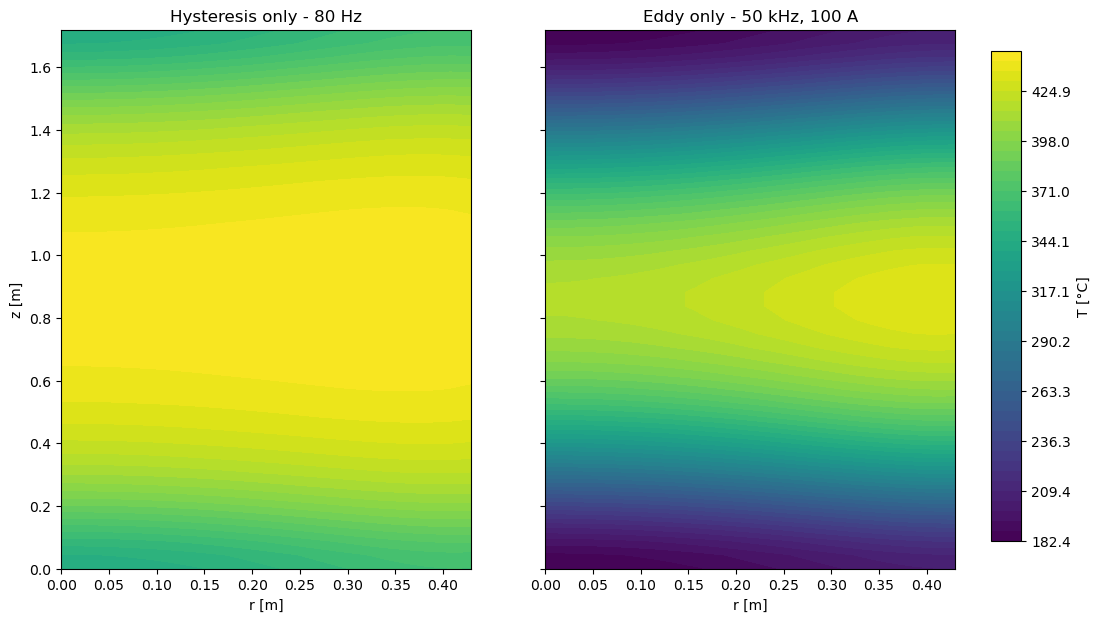

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Temperature in °C
T_hys_C = T_final_hys - 273.15
T_eddy_C = T_final_eddy_100 - 273.15

# Stessa scala colore per entrambi
Tmin = min(np.min(T_hys_C), np.min(T_eddy_C))
Tmax = max(np.max(T_hys_C), np.max(T_eddy_C))
levels = np.linspace(Tmin, Tmax, 50)

fig, axes = plt.subplots(1, 2, figsize=(12, 7), sharey=True)

# Lascia spazio a destra per la colorbar
fig.subplots_adjust(right=0.87, wspace=0.18)

# Hysteresis only
cont1 = axes[0].contourf(
    tes2d.r,
    tes2d.z,
    T_hys_C.T,
    levels=levels,
    cmap="viridis"
)

axes[0].set_title("Hysteresis only - 80 Hz")
axes[0].set_xlabel("r [m]")
axes[0].set_ylabel("z [m]")

# Eddy only
cont2 = axes[1].contourf(
    tes2d.r,
    tes2d.z,
    T_eddy_C.T,
    levels=levels,
    cmap="viridis"
)

axes[1].set_title("Eddy only - 50 kHz, 100 A")
axes[1].set_xlabel("r [m]")

# Colorbar unica esterna a destra
cbar_ax = fig.add_axes([0.90, 0.15, 0.025, 0.70])
cbar = fig.colorbar(cont2, cax=cbar_ax)
cbar.set_label("T [°C]")

plt.show()

In [22]:
#creazione delle GIF dell'andamento temporale della T e della q_ind

In [23]:
case_hys = {
    "name": "Hysteresis only - 80 Hz",
    "short": "hysteresis",
    "freq": 80,
    "I": 2203,
    "source_mode": "hys_only",
    "time": time_hys,
    "T_mean": T_mean_hys,
    "T_max": T_max_hys,
    "T_final": T_final_hys,
    "snapshot_times": snapshot_times_hys,
    "snapshots": snapshots_hys,
    "q_mean": q_mean_hys,
    "q_max": q_max_hys,
}

case_eddy = {
    "name": "Eddy only - 50 kHz, 100 A",
    "short": "eddy",
    "freq": 50000,
    "I": 100.0,
    "source_mode": "eddy_only",
    "time": time_eddy_100,
    "T_mean": T_mean_eddy_100,
    "T_max": T_max_eddy_100,
    "T_final": T_final_eddy_100,
    "snapshot_times": snapshot_times_eddy_100,
    "snapshots": snapshots_eddy_100,
    "q_mean": q_mean_eddy_100,
    "q_max": q_max_eddy_100,
}

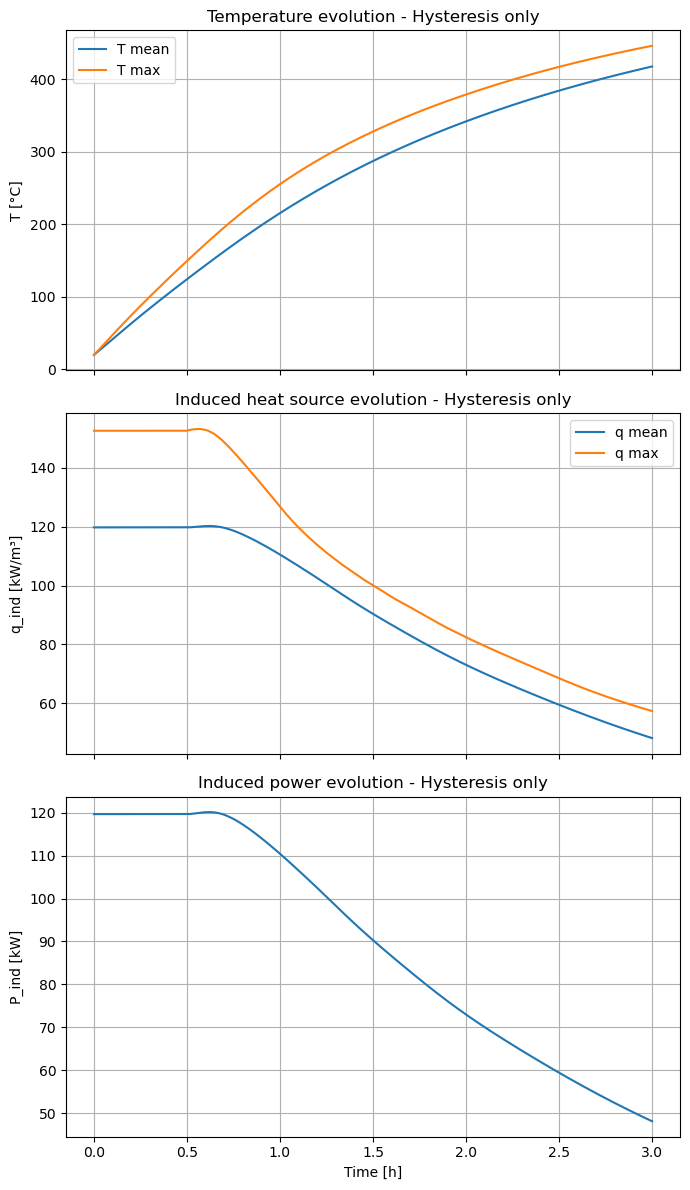

In [24]:
import numpy as np
import matplotlib.pyplot as plt

V_pb = np.pi * (tes2d.D_TES / 2)**2 * tes2d.H_TES

P_ind_hys = case_hys["q_mean"] * V_pb  # [W]

fig, axes = plt.subplots(3, 1, figsize=(7, 12), sharex=True)

axes[0].plot(case_hys["time"]/3600, case_hys["T_mean"] - 273.15, label="T mean")
axes[0].plot(case_hys["time"]/3600, case_hys["T_max"] - 273.15, label="T max")
axes[0].set_ylabel("T [°C]")
axes[0].set_title("Temperature evolution - Hysteresis only")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(case_hys["time"]/3600, case_hys["q_mean"]/1000, label="q mean")
axes[1].plot(case_hys["time"]/3600, case_hys["q_max"]/1000, label="q max")
axes[1].set_ylabel("q_ind [kW/m³]")
axes[1].set_title("Induced heat source evolution - Hysteresis only")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(case_hys["time"]/3600, P_ind_hys/1000)
axes[2].set_xlabel("Time [h]")
axes[2].set_ylabel("P_ind [kW]")
axes[2].set_title("Induced power evolution - Hysteresis only")
axes[2].grid(True)

plt.tight_layout()
plt.show()

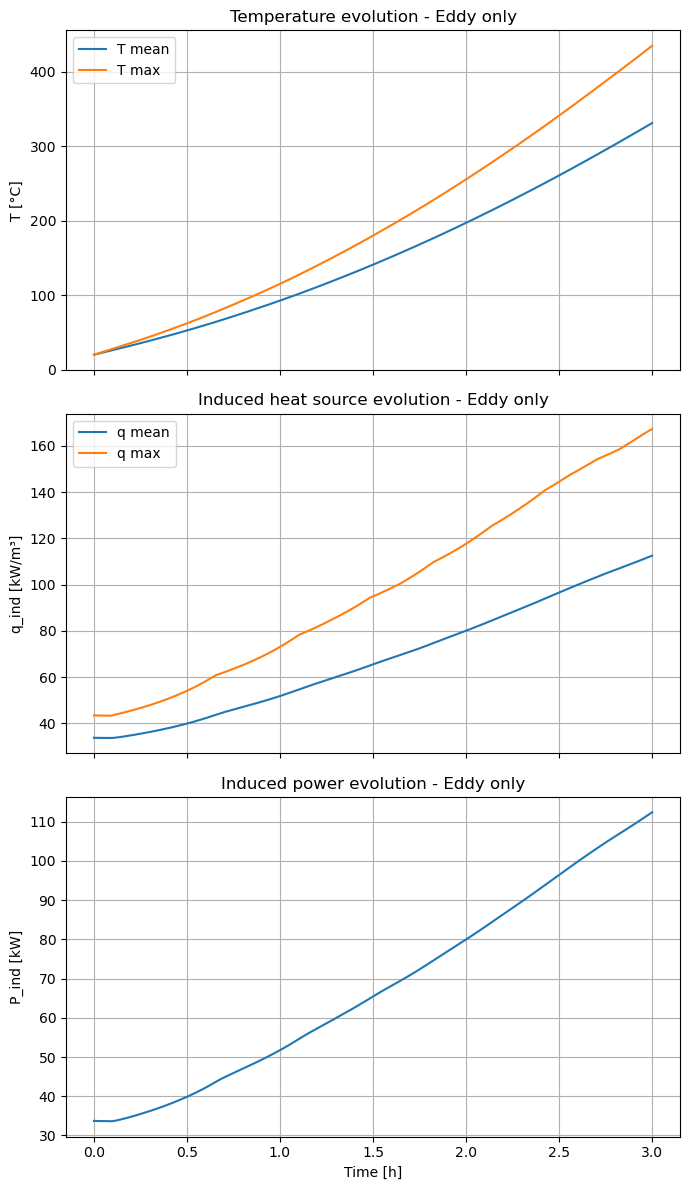

In [25]:
P_ind_eddy = case_eddy["q_mean"] * V_pb  # [W]

fig, axes = plt.subplots(3, 1, figsize=(7, 12), sharex=True)

axes[0].plot(case_eddy["time"]/3600, case_eddy["T_mean"] - 273.15, label="T mean")
axes[0].plot(case_eddy["time"]/3600, case_eddy["T_max"] - 273.15, label="T max")
axes[0].set_ylabel("T [°C]")
axes[0].set_title("Temperature evolution - Eddy only")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(case_eddy["time"]/3600, case_eddy["q_mean"]/1000, label="q mean")
axes[1].plot(case_eddy["time"]/3600, case_eddy["q_max"]/1000, label="q max")
axes[1].set_ylabel("q_ind [kW/m³]")
axes[1].set_title("Induced heat source evolution - Eddy only")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(case_eddy["time"]/3600, P_ind_eddy/1000)
axes[2].set_xlabel("Time [h]")
axes[2].set_ylabel("P_ind [kW]")
axes[2].set_title("Induced power evolution - Eddy only")
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [26]:
import os
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np

In [27]:
all_T_values = []

for T_snap in case_hys["snapshots"]:
    all_T_values.append(T_snap - 273.15)

for T_snap in case_eddy["snapshots"]:
    all_T_values.append(T_snap - 273.15)

Tmin_common = min(np.min(M) for M in all_T_values)
Tmax_common = max(np.max(M) for M in all_T_values)

T_levels_common = np.linspace(Tmin_common, Tmax_common, 50)

print("Common T scale [°C]:", Tmin_common, "to", Tmax_common)

Common T scale [°C]: 20.0 to 446.4467967719079


In [28]:
def make_temperature_gif(case, filename, levels_common, Tmin_common, Tmax_common):
    folder = f"frames_T_{case['short']}"
    os.makedirs(folder, exist_ok=True)

    frame_paths = []

    for k, t_snap in enumerate(case["snapshot_times"]):
        T_snap_C = case["snapshots"][k] - 273.15

        fig, ax = plt.subplots(figsize=(5, 8))

        cont = ax.contourf(
            tes2d.r,
            tes2d.z,
            T_snap_C.T,
            levels=levels_common,
            cmap="viridis"
        )

        ax.set_title(f"{case['name']}\nt = {t_snap/3600:.2f} h")
        ax.set_xlabel("r [m]")
        ax.set_ylabel("z [m]")

        cbar = fig.colorbar(cont, ax=ax)
        cbar.set_label("T [°C]")

        plt.tight_layout()

        frame_path = os.path.join(folder, f"T_frame_{k:03d}.png")
        plt.savefig(frame_path, dpi=150, bbox_inches="tight")
        plt.close(fig)

        frame_paths.append(frame_path)

    images = [imageio.imread(path) for path in frame_paths]
    imageio.mimsave(filename, images, duration=0.35, loop=0)

    print("GIF saved:", filename)

In [29]:
make_temperature_gif(
    case_hys,
    "T_evolution_hysteresis.gif",
    T_levels_common,
    Tmin_common,
    Tmax_common
)

make_temperature_gif(
    case_eddy,
    "T_evolution_eddy.gif",
    T_levels_common,
    Tmin_common,
    Tmax_common
)

GIF saved: T_evolution_hysteresis.gif
GIF saved: T_evolution_eddy.gif


In [30]:
q_maps_hys = []
q_maps_eddy = []

for T_snap in case_hys["snapshots"]:
    q_map = tes2d.qsource_map_Tlocal(
        case_hys["freq"],
        case_hys["I"],
        T_snap,
        source_mode=case_hys["source_mode"]
    )
    q_maps_hys.append(q_map / 1000)  # kW/m3

for T_snap in case_eddy["snapshots"]:
    q_map = tes2d.qsource_map_Tlocal(
        case_eddy["freq"],
        case_eddy["I"],
        T_snap,
        source_mode=case_eddy["source_mode"]
    )
    q_maps_eddy.append(q_map / 1000)  # kW/m3

In [31]:
all_q_values = q_maps_hys + q_maps_eddy

qmin_common = min(np.min(M) for M in all_q_values)
qmax_common = max(np.max(M) for M in all_q_values)

q_levels_common = np.linspace(qmin_common, qmax_common, 50)

print("Common q_ind scale [kW/m3]:", qmin_common, "to", qmax_common)

Common q_ind scale [kW/m3]: 15.181374540140904 to 167.4077083476282


In [32]:
def make_qind_gif(case, q_maps, filename, levels_common):
    folder = f"frames_qind_{case['short']}"
    os.makedirs(folder, exist_ok=True)

    frame_paths = []

    for k, t_snap in enumerate(case["snapshot_times"]):
        q_snap = q_maps[k]

        fig, ax = plt.subplots(figsize=(5, 8))

        cont = ax.contourf(
            tes2d.r,
            tes2d.z,
            q_snap.T,
            levels=levels_common,
            cmap="viridis"
        )

        ax.set_title(f"{case['name']}\nt = {t_snap/3600:.2f} h")
        ax.set_xlabel("r [m]")
        ax.set_ylabel("z [m]")

        cbar = fig.colorbar(cont, ax=ax)
        cbar.set_label("q_ind [kW/m³]")

        plt.tight_layout()

        frame_path = os.path.join(folder, f"qind_frame_{k:03d}.png")
        plt.savefig(frame_path, dpi=150, bbox_inches="tight")
        plt.close(fig)

        frame_paths.append(frame_path)

    images = [imageio.imread(path) for path in frame_paths]
    imageio.mimsave(filename, images, duration=0.35, loop=0)

    print("GIF saved:", filename)

In [33]:
make_qind_gif(
    case_hys,
    q_maps_hys,
    "qind_evolution_hysteresis.gif",
    q_levels_common
)

make_qind_gif(
    case_eddy,
    q_maps_eddy,
    "qind_evolution_eddy.gif",
    q_levels_common
)

GIF saved: qind_evolution_hysteresis.gif
GIF saved: qind_evolution_eddy.gif


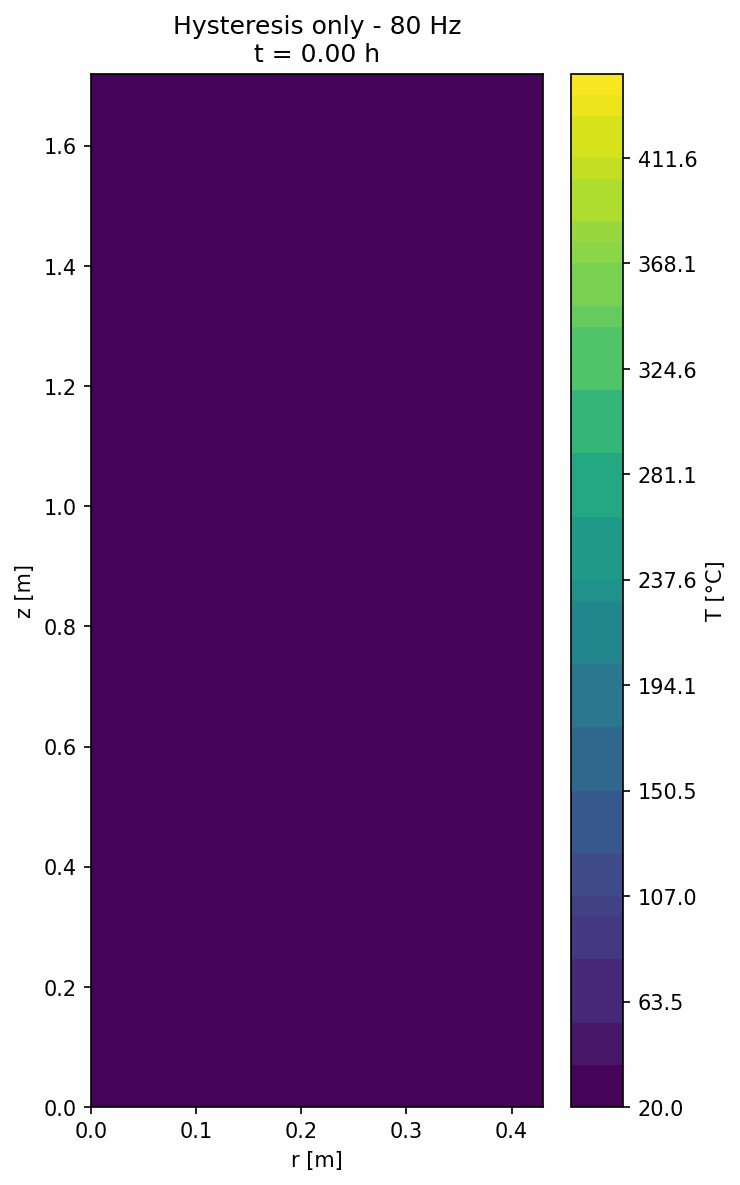

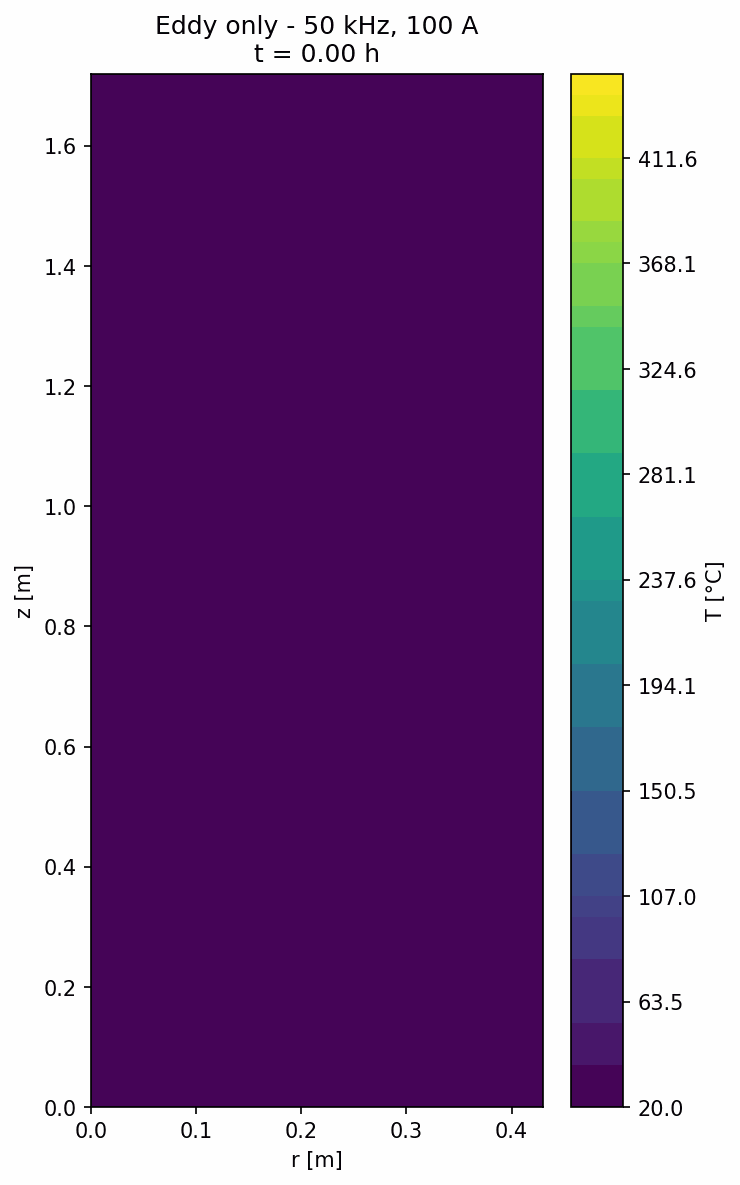

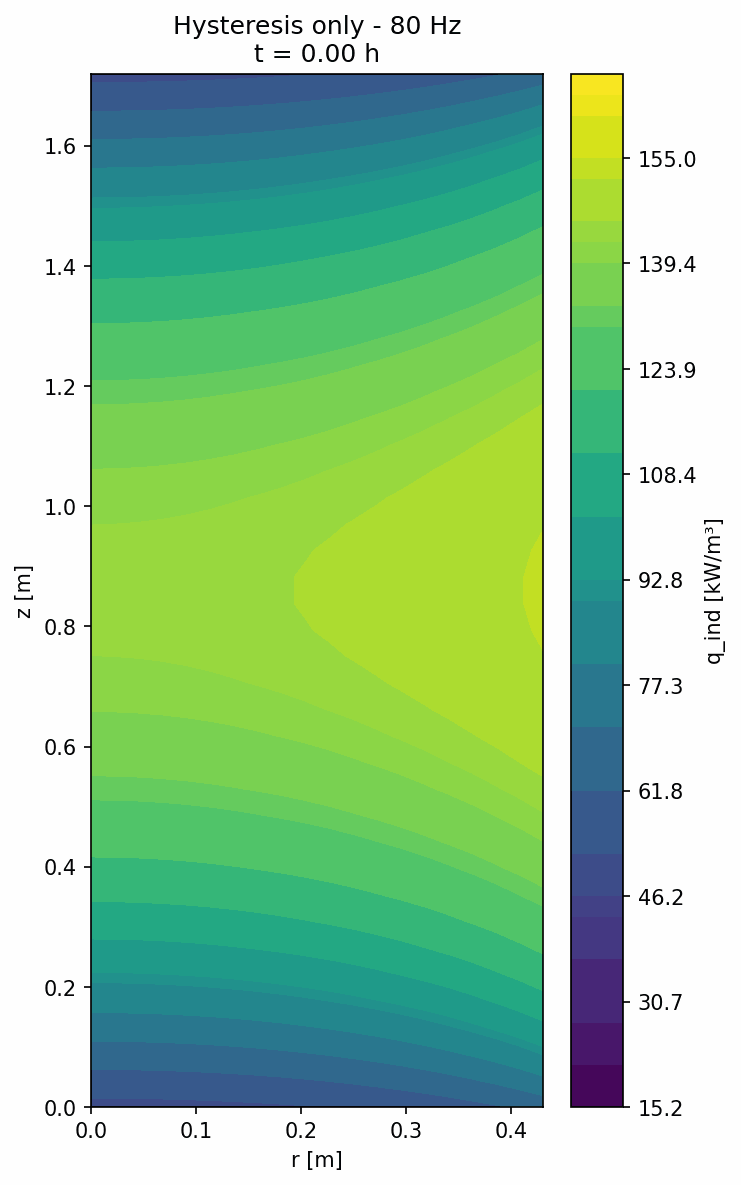

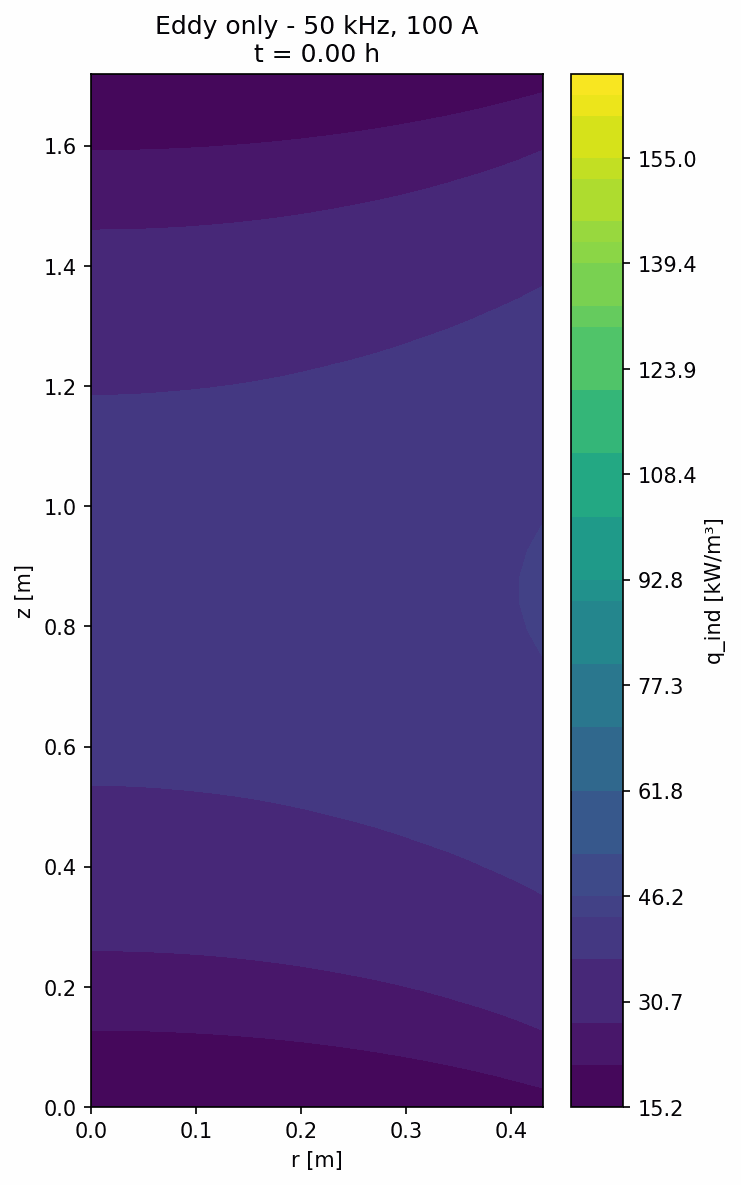

In [34]:
from IPython.display import Image, display

display(Image(filename="T_evolution_hysteresis.gif"))
display(Image(filename="T_evolution_eddy.gif"))

display(Image(filename="qind_evolution_hysteresis.gif"))
display(Image(filename="qind_evolution_eddy.gif"))

In [35]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import os

# ============================================================
# 1. Cartella di salvataggio sul Desktop
# ============================================================

desktop_onedrive = Path.home() / "OneDrive" / "Desktop"
desktop_normal = Path.home() / "Desktop"

desktop = desktop_onedrive if desktop_onedrive.exists() else desktop_normal

save_folder = desktop / "PB_GIFs"
save_folder.mkdir(exist_ok=True)

print("Le GIF verranno salvate in:")
print(save_folder)


# ============================================================
# 2. Definizione dei due casi
# ============================================================

case_hys = {
    "name": "Hysteresis only - 80 Hz",
    "short": "hysteresis",
    "freq": 80,
    "I": 2203,
    "source_mode": "hys_only",
    "snapshot_times": snapshot_times_hys,
    "snapshots": snapshots_hys,
}

case_eddy = {
    "name": "Eddy only - 50 kHz, 100 A",
    "short": "eddy",
    "freq": 50000,
    "I": 100.0,
    "source_mode": "eddy_only",
    "snapshot_times": snapshot_times_eddy_100,
    "snapshots": snapshots_eddy_100,
}


# ============================================================
# 3. Scala colore comune per T
# ============================================================

all_T = []

for T_snap in case_hys["snapshots"]:
    all_T.append(T_snap - 273.15)

for T_snap in case_eddy["snapshots"]:
    all_T.append(T_snap - 273.15)

Tmin_common = min(np.min(M) for M in all_T)
Tmax_common = max(np.max(M) for M in all_T)
T_levels_common = np.linspace(Tmin_common, Tmax_common, 50)

print("Scala T comune [°C]:", Tmin_common, "->", Tmax_common)


# ============================================================
# 4. Calcolo q_ind per tutti gli snapshot e scala comune
# ============================================================

q_maps_hys = []
q_maps_eddy = []

for T_snap in case_hys["snapshots"]:
    q_map = tes2d.qsource_map_Tlocal(
        case_hys["freq"],
        case_hys["I"],
        T_snap,
        source_mode=case_hys["source_mode"]
    )
    q_maps_hys.append(q_map / 1000)   # kW/m3

for T_snap in case_eddy["snapshots"]:
    q_map = tes2d.qsource_map_Tlocal(
        case_eddy["freq"],
        case_eddy["I"],
        T_snap,
        source_mode=case_eddy["source_mode"]
    )
    q_maps_eddy.append(q_map / 1000)  # kW/m3

all_q = q_maps_hys + q_maps_eddy

qmin_common = min(np.min(M) for M in all_q)
qmax_common = max(np.max(M) for M in all_q)
q_levels_common = np.linspace(qmin_common, qmax_common, 50)

print("Scala q_ind comune [kW/m3]:", qmin_common, "->", qmax_common)


# ============================================================
# 5. Funzione per creare GIF della temperatura
# ============================================================

def save_temperature_gif(case, filename):
    frame_paths = []
    frame_folder = save_folder / f"frames_T_{case['short']}"
    frame_folder.mkdir(exist_ok=True)

    for k, t_snap in enumerate(case["snapshot_times"]):
        T_C = case["snapshots"][k] - 273.15

        fig, ax = plt.subplots(figsize=(5, 8))

        cont = ax.contourf(
            tes2d.r,
            tes2d.z,
            T_C.T,
            levels=T_levels_common,
            cmap="viridis"
        )

        ax.set_title(f"{case['name']}\nt = {t_snap/3600:.2f} h")
        ax.set_xlabel("r [m]")
        ax.set_ylabel("z [m]")

        cbar = fig.colorbar(cont, ax=ax)
        cbar.set_label("T [°C]")

        plt.tight_layout()

        frame_path = frame_folder / f"T_frame_{k:03d}.png"
        plt.savefig(frame_path, dpi=150, bbox_inches="tight")
        plt.close(fig)

        frame_paths.append(frame_path)

    images = [imageio.imread(path) for path in frame_paths]

    gif_path = save_folder / filename
    imageio.mimsave(gif_path, images, duration=0.35, loop=0)

    print("Salvata:", gif_path)


# ============================================================
# 6. Funzione per creare GIF di q_ind
# ============================================================

def save_qind_gif(case, q_maps, filename):
    frame_paths = []
    frame_folder = save_folder / f"frames_qind_{case['short']}"
    frame_folder.mkdir(exist_ok=True)

    for k, t_snap in enumerate(case["snapshot_times"]):
        q_map = q_maps[k]

        fig, ax = plt.subplots(figsize=(5, 8))

        cont = ax.contourf(
            tes2d.r,
            tes2d.z,
            q_map.T,
            levels=q_levels_common,
            cmap="viridis"
        )

        ax.set_title(f"{case['name']}\nt = {t_snap/3600:.2f} h")
        ax.set_xlabel("r [m]")
        ax.set_ylabel("z [m]")

        cbar = fig.colorbar(cont, ax=ax)
        cbar.set_label("q_ind [kW/m³]")

        plt.tight_layout()

        frame_path = frame_folder / f"qind_frame_{k:03d}.png"
        plt.savefig(frame_path, dpi=150, bbox_inches="tight")
        plt.close(fig)

        frame_paths.append(frame_path)

    images = [imageio.imread(path) for path in frame_paths]

    gif_path = save_folder / filename
    imageio.mimsave(gif_path, images, duration=0.35, loop=0)

    print("Salvata:", gif_path)


# ============================================================
# 7. Creazione e salvataggio delle 4 GIF
# ============================================================

save_temperature_gif(case_hys, "T_evolution_hysteresis.gif")
save_temperature_gif(case_eddy, "T_evolution_eddy.gif")

save_qind_gif(case_hys, q_maps_hys, "qind_evolution_hysteresis.gif")
save_qind_gif(case_eddy, q_maps_eddy, "qind_evolution_eddy.gif")

print("\nFINITO.")
print("Apri questa cartella sul Desktop:")
print(save_folder)

Le GIF verranno salvate in:
C:\Users\lolle\OneDrive\Desktop\PB_GIFs
Scala T comune [°C]: 20.0 -> 446.4467967719079
Scala q_ind comune [kW/m3]: 15.181374540140904 -> 167.4077083476282
Salvata: C:\Users\lolle\OneDrive\Desktop\PB_GIFs\T_evolution_hysteresis.gif
Salvata: C:\Users\lolle\OneDrive\Desktop\PB_GIFs\T_evolution_eddy.gif
Salvata: C:\Users\lolle\OneDrive\Desktop\PB_GIFs\qind_evolution_hysteresis.gif
Salvata: C:\Users\lolle\OneDrive\Desktop\PB_GIFs\qind_evolution_eddy.gif

FINITO.
Apri questa cartella sul Desktop:
C:\Users\lolle\OneDrive\Desktop\PB_GIFs


In [ ]:
#vedere ora cosa fanno i rendimenti per entrambi i casi

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Definizione dei due casi, se non li hai già creati
# ============================================================

case_hys = {
    "name": "Hysteresis only - 80 Hz",
    "short": "hysteresis",
    "freq": 80,
    "I": 2203,
    "source_mode": "hys_only",
    "time": time_hys,
    "T_mean": T_mean_hys,
    "T_max": T_max_hys,
    "q_mean": q_mean_hys,
    "q_max": q_max_hys,
}

case_eddy = {
    "name": "Eddy only - 50 kHz, 100 A",
    "short": "eddy",
    "freq": 50000,
    "I": 100.0,
    "source_mode": "eddy_only",
    "time": time_eddy_100,
    "T_mean": T_mean_eddy_100,
    "T_max": T_max_eddy_100,
    "q_mean": q_mean_eddy_100,
    "q_max": q_max_eddy_100,
}

# ============================================================
# Funzione per calcolare i rendimenti secondo Famiglietti
# ============================================================

def compute_famiglietti_efficiencies(case, tes2d, T_amb=293.15, Tcoil_ref=333.15):
    """
    Calcola i rendimenti secondo Famiglietti:

    P_ind = potenza indotta nel packed bed
    P_ch  = P_ind - P_amb

    eta_ind = P_ind / (P_ind + P_coil)
    eta_th  = P_ch / P_ind
    eta_ch  = eta_conv * eta_ind * eta_th
    """

    time = case["time"]
    T_mean = case["T_mean"]
    q_mean = case["q_mean"]
    freq = case["freq"]
    I = case["I"]

    # Volume packed bed
    V_pb = np.pi * (tes2d.D_TES / 2)**2 * tes2d.H_TES

    # Potenza indotta nel PB
    P_ind = q_mean * V_pb   # [W]

    # Potenza persa nella coil
    # Metodo del modello Famiglietti/class_IHTES
    P_coil_scalar = tes2d.Pcoil(freq, I, Tcoil_ref)   # [W]
    P_coil = np.full_like(P_ind, P_coil_scalar, dtype=float)

    # Efficienza converter
    # Se la classe ha eta_conv, uso quella.
    # Altrimenti assumo eta_conv = 1 per non bloccare il calcolo.
    if hasattr(tes2d, "eta_conv"):
        eta_conv_scalar = tes2d.eta_conv(freq)
    else:
        eta_conv_scalar = 1.0

    eta_conv = np.full_like(P_ind, eta_conv_scalar, dtype=float)

    # Perdite termiche ambiente.
    # Usiamo le perdite coerenti con il modello robusto:
    # laterali + top/bottom.
    R_pb = tes2d.D_TES / 2
    A_side = np.pi * tes2d.D_TES * tes2d.H_TES
    A_tb = 2 * np.pi * R_pb**2

    # Coefficienti equivalenti usati nel modello
    if hasattr(tes2d, "last_h_eq_side"):
        h_side = tes2d.last_h_eq_side
    else:
        h_side = tes2d.heq_from_Pamb(T_amb)

    if hasattr(tes2d, "last_h_eq_top_bottom"):
        h_tb = tes2d.last_h_eq_top_bottom
    elif hasattr(tes2d, "heq_top_bottom_from_Pamb"):
        h_tb = tes2d.heq_top_bottom_from_Pamb(T_amb)
    else:
        h_tb = 0.0

    P_amb_side = h_side * A_side * (T_mean - T_amb)
    P_amb_tb = h_tb * A_tb * (T_mean - T_amb)
    P_amb = P_amb_side + P_amb_tb

    # Potenza effettivamente accumulata secondo Famiglietti
    P_ch = P_ind - P_amb

    # Rendimenti
    eta_ind = P_ind / (P_ind + P_coil)
    eta_th = P_ch / P_ind
    eta_ch = eta_conv * eta_ind * eta_th

    return {
        "time": time,
        "T_mean_C": T_mean - 273.15,
        "P_ind": P_ind,
        "P_coil": P_coil,
        "P_amb": P_amb,
        "P_ch": P_ch,
        "eta_ind": eta_ind,
        "eta_th": eta_th,
        "eta_conv": eta_conv,
        "eta_ch": eta_ch,
    }

# ============================================================
# Calcolo per i due casi
# ============================================================

eff_hys = compute_famiglietti_efficiencies(case_hys, tes2d)
eff_eddy = compute_famiglietti_efficiencies(case_eddy, tes2d)

# ============================================================
# Stampa valori finali
# ============================================================

def print_final_eff(case, eff):
    print("\n===", case["name"], "===")
    print("P_ind finale [kW]  =", eff["P_ind"][-1] / 1000)
    print("P_coil [kW]        =", eff["P_coil"][-1] / 1000)
    print("P_amb finale [kW]  =", eff["P_amb"][-1] / 1000)
    print("P_ch finale [kW]   =", eff["P_ch"][-1] / 1000)
    print("eta_ind finale [-] =", eff["eta_ind"][-1])
    print("eta_th finale [-]  =", eff["eta_th"][-1])
    print("eta_conv [-]       =", eff["eta_conv"][-1])
    print("eta_ch finale [-]  =", eff["eta_ch"][-1])

print_final_eff(case_hys, eff_hys)
print_final_eff(case_eddy, eff_eddy)


=== Hysteresis only - 80 Hz ===
P_ind finale [kW]  = 48.16596878753441
P_coil [kW]        = 26.931933064142623
P_amb finale [kW]  = 0.45891036902456056
P_ch finale [kW]   = 47.707058418509845
eta_ind finale [-] = 0.6413756922618845
eta_th finale [-]  = 0.9904723110408332
eta_conv [-]       = 0.99999
eta_ch finale [-]  = 0.6352585115114014

=== Eddy only - 50 kHz, 100 A ===
P_ind finale [kW]  = 112.40982635460986
P_coil [kW]        = 1.5110606733120078
P_amb finale [kW]  = 0.3588209038722481
P_ch finale [kW]   = 112.05100545073762
eta_ind finale [-] = 0.9867358768639007
eta_th finale [-]  = 0.9968079222652626
eta_conv [-]       = 0.99375
eta_ch finale [-]  = 0.9774387258710387


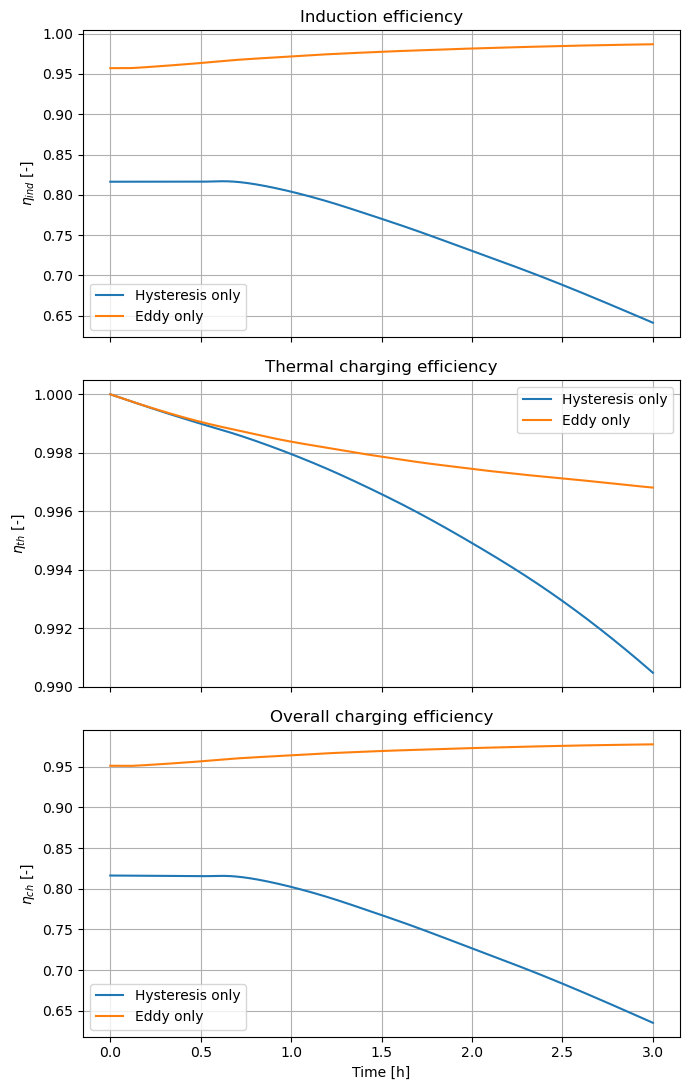

In [37]:
fig, axes = plt.subplots(3, 1, figsize=(7, 11), sharex=True)

# eta_ind
axes[0].plot(eff_hys["time"]/3600, eff_hys["eta_ind"], label="Hysteresis only")
axes[0].plot(eff_eddy["time"]/3600, eff_eddy["eta_ind"], label="Eddy only")
axes[0].set_ylabel(r"$\eta_{ind}$ [-]")
axes[0].set_title("Induction efficiency")
axes[0].legend()
axes[0].grid(True)

# eta_th
axes[1].plot(eff_hys["time"]/3600, eff_hys["eta_th"], label="Hysteresis only")
axes[1].plot(eff_eddy["time"]/3600, eff_eddy["eta_th"], label="Eddy only")
axes[1].set_ylabel(r"$\eta_{th}$ [-]")
axes[1].set_title("Thermal charging efficiency")
axes[1].legend()
axes[1].grid(True)

# eta_ch
axes[2].plot(eff_hys["time"]/3600, eff_hys["eta_ch"], label="Hysteresis only")
axes[2].plot(eff_eddy["time"]/3600, eff_eddy["eta_ch"], label="Eddy only")
axes[2].set_xlabel("Time [h]")
axes[2].set_ylabel(r"$\eta_{ch}$ [-]")
axes[2].set_title("Overall charging efficiency")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

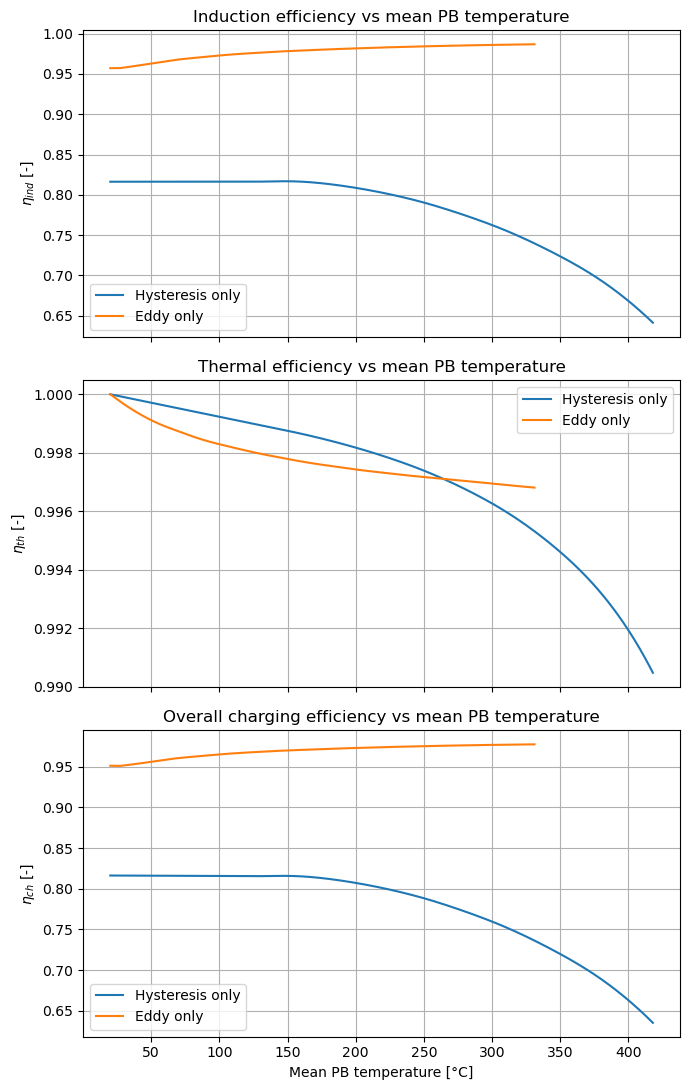

In [38]:
fig, axes = plt.subplots(3, 1, figsize=(7, 11), sharex=True)

# eta_ind vs T
axes[0].plot(eff_hys["T_mean_C"], eff_hys["eta_ind"], label="Hysteresis only")
axes[0].plot(eff_eddy["T_mean_C"], eff_eddy["eta_ind"], label="Eddy only")
axes[0].set_ylabel(r"$\eta_{ind}$ [-]")
axes[0].set_title("Induction efficiency vs mean PB temperature")
axes[0].legend()
axes[0].grid(True)

# eta_th vs T
axes[1].plot(eff_hys["T_mean_C"], eff_hys["eta_th"], label="Hysteresis only")
axes[1].plot(eff_eddy["T_mean_C"], eff_eddy["eta_th"], label="Eddy only")
axes[1].set_ylabel(r"$\eta_{th}$ [-]")
axes[1].set_title("Thermal efficiency vs mean PB temperature")
axes[1].legend()
axes[1].grid(True)

# eta_ch vs T
axes[2].plot(eff_hys["T_mean_C"], eff_hys["eta_ch"], label="Hysteresis only")
axes[2].plot(eff_eddy["T_mean_C"], eff_eddy["eta_ch"], label="Eddy only")
axes[2].set_xlabel("Mean PB temperature [°C]")
axes[2].set_ylabel(r"$\eta_{ch}$ [-]")
axes[2].set_title("Overall charging efficiency vs mean PB temperature")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
#vediamo ora P_ind e q_ind nel tempo

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Volume packed bed
# ============================================================

V_pb = np.pi * (tes2d.D_TES / 2)**2 * tes2d.H_TES

# ============================================================
# P_ind dei due casi
# ============================================================

P_ind_hys = q_mean_hys * V_pb          # [W]
P_ind_eddy = q_mean_eddy_100 * V_pb    # [W]

Tmean_hys_C = T_mean_hys - 273.15
Tmean_eddy_C = T_mean_eddy_100 - 273.15

# ============================================================
# Stampa valori principali
# ============================================================

print("=== HYSTERESIS ONLY - 80 Hz ===")
print("P_ind iniziale [kW] =", P_ind_hys[0] / 1000)
print("P_ind finale [kW]   =", P_ind_hys[-1] / 1000)
print("Variazione P_ind [%] =", 100 * (P_ind_hys[-1] - P_ind_hys[0]) / P_ind_hys[0])
print("q_mean iniziale [kW/m3] =", q_mean_hys[0] / 1000)
print("q_mean finale [kW/m3]   =", q_mean_hys[-1] / 1000)

print("\n=== EDDY ONLY - 50 kHz, 100 A ===")
print("P_ind iniziale [kW] =", P_ind_eddy[0] / 1000)
print("P_ind finale [kW]   =", P_ind_eddy[-1] / 1000)
print("Variazione P_ind [%] =", 100 * (P_ind_eddy[-1] - P_ind_eddy[0]) / P_ind_eddy[0])
print("q_mean iniziale [kW/m3] =", q_mean_eddy_100[0] / 1000)
print("q_mean finale [kW/m3]   =", q_mean_eddy_100[-1] / 1000)

=== HYSTERESIS ONLY - 80 Hz ===
P_ind iniziale [kW] = 119.63214037933007
P_ind finale [kW]   = 48.16596878753441
Variazione P_ind [%] = -59.73827047245869
q_mean iniziale [kW/m3] = 119.73817710411608
q_mean finale [kW/m3]   = 48.208661006867615

=== EDDY ONLY - 50 kHz, 100 A ===
P_ind iniziale [kW] = 33.70232325505292
P_ind finale [kW]   = 112.40982635460986
Variazione P_ind [%] = 233.5373217564653
q_mean iniziale [kW/m3] = 33.73219552820889
q_mean finale [kW/m3]   = 112.50946153444207


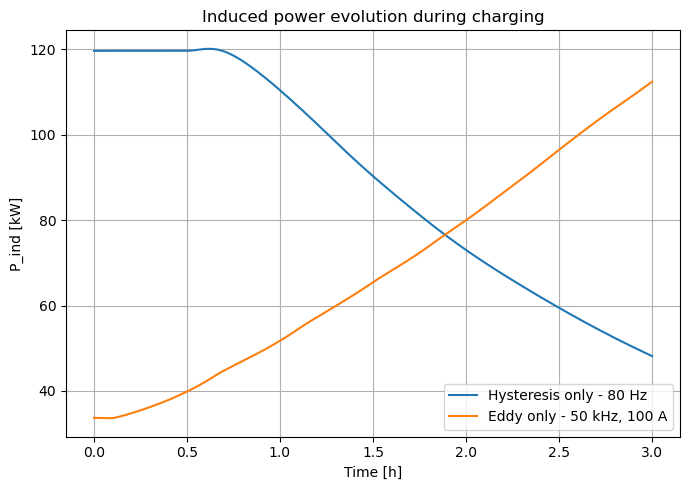

In [40]:
plt.figure(figsize=(7,5))

plt.plot(time_hys/3600, P_ind_hys/1000, label="Hysteresis only - 80 Hz")
plt.plot(time_eddy_100/3600, P_ind_eddy/1000, label="Eddy only - 50 kHz, 100 A")

plt.xlabel("Time [h]")
plt.ylabel("P_ind [kW]")
plt.title("Induced power evolution during charging")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

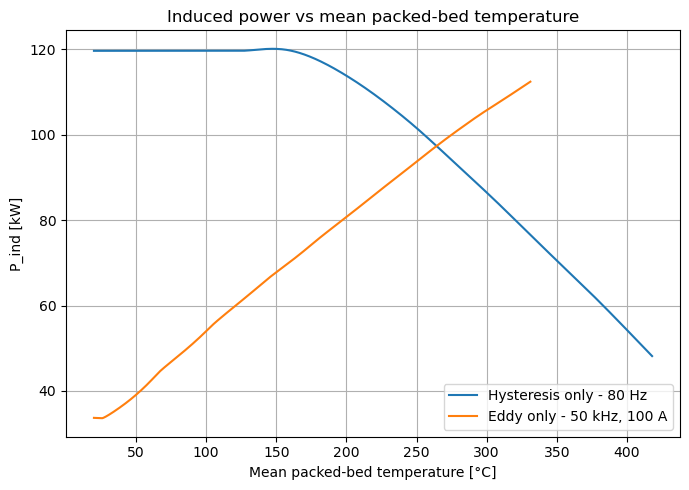

In [41]:
plt.figure(figsize=(7,5))

plt.plot(Tmean_hys_C, P_ind_hys/1000, label="Hysteresis only - 80 Hz")
plt.plot(Tmean_eddy_C, P_ind_eddy/1000, label="Eddy only - 50 kHz, 100 A")

plt.xlabel("Mean packed-bed temperature [°C]")
plt.ylabel("P_ind [kW]")
plt.title("Induced power vs mean packed-bed temperature")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

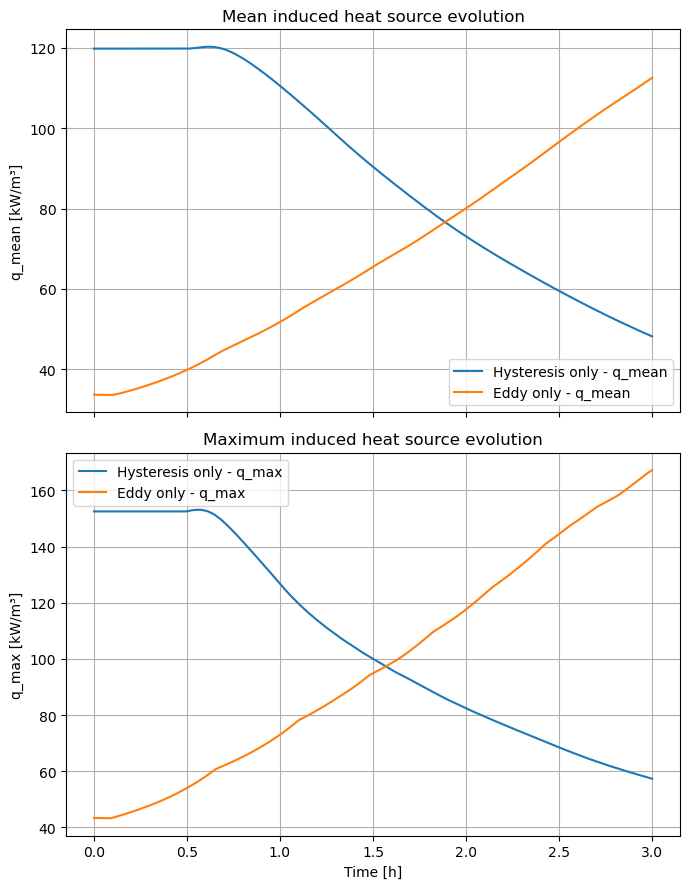

In [42]:
fig, axes = plt.subplots(2, 1, figsize=(7, 9), sharex=True)

# q_mean
axes[0].plot(time_hys/3600, q_mean_hys/1000, label="Hysteresis only - q_mean")
axes[0].plot(time_eddy_100/3600, q_mean_eddy_100/1000, label="Eddy only - q_mean")
axes[0].set_ylabel("q_mean [kW/m³]")
axes[0].set_title("Mean induced heat source evolution")
axes[0].legend()
axes[0].grid(True)

# q_max
axes[1].plot(time_hys/3600, q_max_hys/1000, label="Hysteresis only - q_max")
axes[1].plot(time_eddy_100/3600, q_max_eddy_100/1000, label="Eddy only - q_max")
axes[1].set_xlabel("Time [h]")
axes[1].set_ylabel("q_max [kW/m³]")
axes[1].set_title("Maximum induced heat source evolution")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
#test a temperatura uniforme per vedere come cambia P_ind al variare della T, cioè siamo noi ad imporre i vari valori di T che è lo STESSO per tutto il PB e vedere come varia la Pind e la q_ind

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Test a temperatura uniforme
# ============================================================

T_list_C = np.array([20, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500])

V_pb = np.pi * (tes2d.D_TES / 2)**2 * tes2d.H_TES

Pind_hys_T = []
Pind_eddy_T = []

qmean_hys_T = []
qmean_eddy_T = []

for T_C in T_list_C:
    T_map = np.full((tes2d.Nr, tes2d.Nz), T_C + 273.15)

    # Caso hysteresis-only
    q_hys_map = tes2d.qsource_map_Tlocal(
        freq=80,
        I=2203,
        T_map=T_map,
        source_mode="hys_only"
    )

    qmean_hys = tes2d.volume_average(q_hys_map)
    Pind_hys = qmean_hys * V_pb

    qmean_hys_T.append(qmean_hys)
    Pind_hys_T.append(Pind_hys)

    # Caso eddy-only
    q_eddy_map = tes2d.qsource_map_Tlocal(
        freq=50000,
        I=100.0,
        T_map=T_map,
        source_mode="eddy_only"
    )

    qmean_eddy = tes2d.volume_average(q_eddy_map)
    Pind_eddy = qmean_eddy * V_pb

    qmean_eddy_T.append(qmean_eddy)
    Pind_eddy_T.append(Pind_eddy)

Pind_hys_T = np.array(Pind_hys_T)
Pind_eddy_T = np.array(Pind_eddy_T)

qmean_hys_T = np.array(qmean_hys_T)
qmean_eddy_T = np.array(qmean_eddy_T)

# ============================================================
# Stampa risultati
# ============================================================

print("T [°C] | P_ind hys [kW] | P_ind eddy [kW] | q_hys [kW/m3] | q_eddy [kW/m3]")
print("-" * 85)

for i, T_C in enumerate(T_list_C):
    print(
        f"{T_C:6.1f} | "
        f"{Pind_hys_T[i]/1000:15.3f} | "
        f"{Pind_eddy_T[i]/1000:16.3f} | "
        f"{qmean_hys_T[i]/1000:13.3f} | "
        f"{qmean_eddy_T[i]/1000:14.3f}"
    )

T [°C] | P_ind hys [kW] | P_ind eddy [kW] | q_hys [kW/m3] | q_eddy [kW/m3]
-------------------------------------------------------------------------------------
  20.0 |         119.632 |           33.702 |       119.738 |         33.732
  50.0 |         119.632 |           38.624 |       119.738 |         38.659
 100.0 |         119.632 |           52.476 |       119.738 |         52.522
 150.0 |         119.845 |           66.004 |       119.951 |         66.063
 200.0 |         119.229 |           77.829 |       119.335 |         77.898
 250.0 |         107.792 |           90.102 |       107.888 |         90.182
 300.0 |          91.301 |          102.427 |        91.382 |        102.518
 350.0 |          73.503 |          114.262 |        73.569 |        114.364
 400.0 |          56.580 |          123.007 |        56.630 |        123.116
 450.0 |          38.252 |          132.815 |        38.286 |        132.933
 500.0 |          18.476 |          140.807 |        18.492 |        

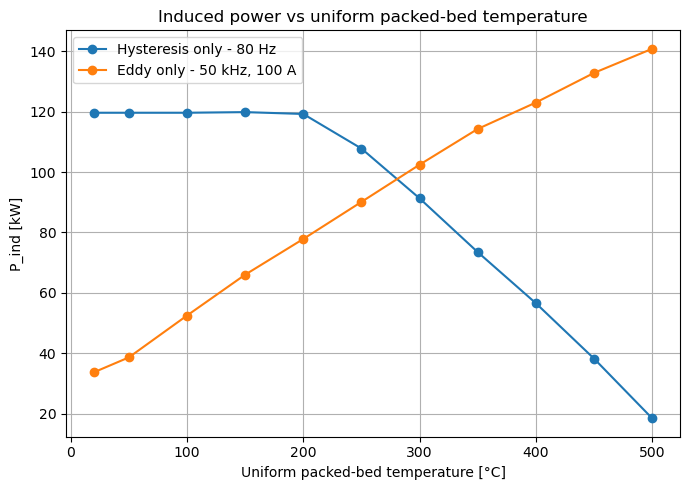

In [44]:
# ============================================================
# P_ind vs temperatura uniforme
# ============================================================

plt.figure(figsize=(7,5))

plt.plot(T_list_C, Pind_hys_T/1000, marker="o", label="Hysteresis only - 80 Hz")
plt.plot(T_list_C, Pind_eddy_T/1000, marker="o", label="Eddy only - 50 kHz, 100 A")

plt.xlabel("Uniform packed-bed temperature [°C]")
plt.ylabel("P_ind [kW]")
plt.title("Induced power vs uniform packed-bed temperature")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

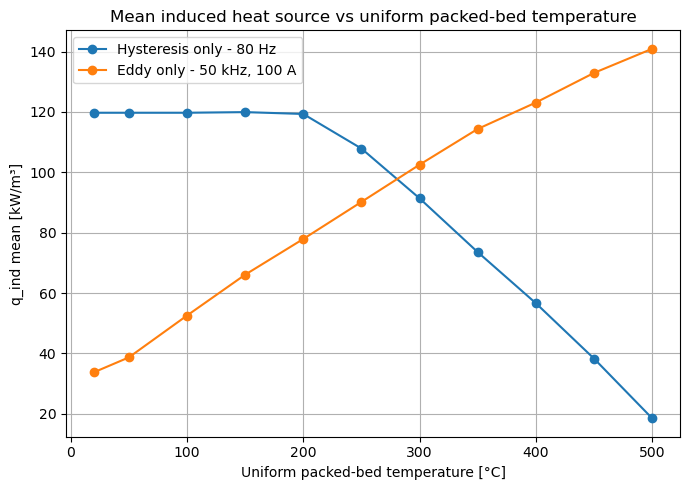

In [45]:
# ============================================================
# q_ind vs temperatura uniforme
# ============================================================

plt.figure(figsize=(7,5))

plt.plot(T_list_C, qmean_hys_T/1000, marker="o", label="Hysteresis only - 80 Hz")
plt.plot(T_list_C, qmean_eddy_T/1000, marker="o", label="Eddy only - 50 kHz, 100 A")

plt.xlabel("Uniform packed-bed temperature [°C]")
plt.ylabel("q_ind mean [kW/m³]")
plt.title("Mean induced heat source vs uniform packed-bed temperature")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
#tabella riassuntiva dei due casi

In [46]:
import numpy as np
import pandas as pd

# ============================================================
# Tabella riassuntiva finale dei due casi
# ============================================================

summary_data = []

cases = [
    {
        "Case": "Hysteresis only",
        "Frequency [Hz]": 80,
        "Current [A]": 2203,
        "Source": "q_hys",
        "T_mean": T_mean_hys,
        "T_max": T_max_hys,
        "T_final": T_final_hys,
        "q_mean": q_mean_hys,
        "q_max": q_max_hys,
        "eff": eff_hys
    },
    {
        "Case": "Eddy only",
        "Frequency [Hz]": 50000,
        "Current [A]": 100.0,
        "Source": "q_eddy",
        "T_mean": T_mean_eddy_100,
        "T_max": T_max_eddy_100,
        "T_final": T_final_eddy_100,
        "q_mean": q_mean_eddy_100,
        "q_max": q_max_eddy_100,
        "eff": eff_eddy
    }
]

for c in cases:
    T_final_C = c["T_final"] - 273.15
    
    row = {
        "Case": c["Case"],
        "f [Hz]": c["Frequency [Hz]"],
        "I [A]": c["Current [A]"],
        "Source": c["Source"],
        
        "T_min_final [°C]": np.min(T_final_C),
        "T_mean_final [°C]": c["T_mean"][-1] - 273.15,
        "T_max_final [°C]": c["T_max"][-1] - 273.15,
        "Delta_T_final [°C]": np.max(T_final_C) - np.min(T_final_C),
        "T_std_final [°C]": np.std(T_final_C),
        
        "q_mean_initial [kW/m3]": c["q_mean"][0] / 1000,
        "q_mean_final [kW/m3]": c["q_mean"][-1] / 1000,
        "q_max_final [kW/m3]": c["q_max"][-1] / 1000,
        
        "P_ind_initial [kW]": c["eff"]["P_ind"][0] / 1000,
        "P_ind_final [kW]": c["eff"]["P_ind"][-1] / 1000,
        "P_ind_variation [%]": 100 * (c["eff"]["P_ind"][-1] - c["eff"]["P_ind"][0]) / c["eff"]["P_ind"][0],
        
        "P_coil [kW]": c["eff"]["P_coil"][-1] / 1000,
        "P_amb_final [kW]": c["eff"]["P_amb"][-1] / 1000,
        "P_ch_final [kW]": c["eff"]["P_ch"][-1] / 1000,
        
        "eta_ind_final [-]": c["eff"]["eta_ind"][-1],
        "eta_th_final [-]": c["eff"]["eta_th"][-1],
        "eta_conv [-]": c["eff"]["eta_conv"][-1],
        "eta_ch_final [-]": c["eff"]["eta_ch"][-1],
    }
    
    summary_data.append(row)

df_summary = pd.DataFrame(summary_data)

# Arrotondo per visualizzare meglio
df_summary_rounded = df_summary.round(3)

display(df_summary_rounded)

,Case,f [Hz],I [A],Source,T_min_final [°C],T_mean_final [°C],T_max_final [°C],Delta_T_final [°C],T_std_final [°C],q_mean_initial [kW/m3],...,P_ind_initial [kW],P_ind_final [kW],P_ind_variation [%],P_coil [kW],P_amb_final [kW],P_ch_final [kW],eta_ind_final [-],eta_th_final [-],eta_conv [-],eta_ch_final [-]
0,Hysteresis only,80,2203.0,q_hys,344.867,417.918,446.447,101.580,30.769,119.738,...,119.632,48.166,-59.738,26.932,0.459,47.707,0.641,0.990,1.000,0.635
1,Eddy only,50000,100.0,q_eddy,182.441,331.131,434.929,252.488,81.960,33.732,...,33.702,112.410,233.537,1.511,0.359,112.051,0.987,0.997,0.994,0.977


In [ ]:
#ora vediamo con i differenti aspet ratio (different AR)

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
import time

# ============================================================
# Geometria base
# ============================================================

geom_base = geom_1

D_base = geom_base[0]
H_base = geom_base[1]
V_base = np.pi * (D_base / 2)**2 * H_base
AR_base = H_base / D_base

print("D base [m] =", D_base)
print("H base [m] =", H_base)
print("AR base [-] =", AR_base)
print("V base [m3] =", V_base)


def make_geom_same_volume(AR, geom_base):
    """
    Crea una nuova geometria mantenendo costante il volume del PB.
    
    AR = H / D
    V = pi/4 * D^2 * H = pi/4 * AR * D^3
    """
    D0 = geom_base[0]
    H0 = geom_base[1]
    V0 = np.pi * (D0 / 2)**2 * H0

    D_new = (4 * V0 / (np.pi * AR))**(1/3)
    H_new = AR * D_new

    geom_new = list(geom_base)
    geom_new[0] = D_new
    geom_new[1] = H_new

    return tuple(geom_new)


def eta_conv_famiglietti(freq):
    """
    Efficienza converter secondo formula tipo Famiglietti:
    eta_conv = 1 - 0.5 * (ton + toff) * f
    
    Uso ton+toff = 250 ns, coerente con il valore che avevamo:
    eta_conv(50 kHz) = 0.99375
    """
    ton_plus_toff = 250e-9
    return 1.0 - 0.5 * ton_plus_toff * freq


def volume_weighted_std_T(tes, T_map):
    """
    Deviazione standard volumetrica della temperatura.
    Più corretta della std semplice perché pesa le celle con r.
    """
    T = np.asarray(T_map, dtype=float)

    r_eff = tes.r.copy()
    if r_eff[0] == 0:
        r_eff[0] = tes.dr / 2

    weights = 2 * np.pi * r_eff[:, None] * tes.dr * tes.dz
    weights = np.repeat(weights, tes.Nz, axis=1)

    T_avg = np.sum(T * weights) / np.sum(weights)
    T_std = np.sqrt(np.sum(weights * (T - T_avg)**2) / np.sum(weights))

    return T_std


def compute_final_efficiencies(tes, freq, I, q_mean, T_mean, T_amb=293.15, Tcoil_ref=333.15):
    """
    Rendimenti secondo Famiglietti:
    
    P_ind = P_hys + P_eddy
    P_ch  = P_ind - P_amb
    eta_ind = P_ind / (P_ind + P_coil)
    eta_th  = P_ch / P_ind
    eta_ch  = eta_conv * eta_ind * eta_th
    """
    V_pb = np.pi * (tes.D_TES / 2)**2 * tes.H_TES

    P_ind = q_mean * V_pb   # [W]

    # Perdite coil
    P_coil = tes.Pcoil(freq, I, Tcoil_ref)

    # Efficienza conversione
    if hasattr(tes, "eta_conv"):
        eta_conv = tes.eta_conv(freq)
    else:
        eta_conv = eta_conv_famiglietti(freq)

    # Perdite ambiente: laterali + top/bottom
    R_pb = tes.D_TES / 2
    A_side = np.pi * tes.D_TES * tes.H_TES
    A_tb = 2 * np.pi * R_pb**2

    if hasattr(tes, "last_h_eq_side"):
        h_side = tes.last_h_eq_side
    else:
        h_side = tes.heq_from_Pamb(T_amb)

    if hasattr(tes, "last_h_eq_top_bottom"):
        h_tb = tes.last_h_eq_top_bottom
    elif hasattr(tes, "heq_top_bottom_from_Pamb"):
        h_tb = tes.heq_top_bottom_from_Pamb(T_amb)
    else:
        h_tb = 0.0

    P_amb = h_side * A_side * (T_mean - T_amb) + h_tb * A_tb * (T_mean - T_amb)

    P_ch = P_ind - P_amb

    eta_ind = P_ind / (P_ind + P_coil)
    eta_th = P_ch / P_ind
    eta_ch = eta_conv * eta_ind * eta_th

    return P_ind, P_coil, P_amb, P_ch, eta_ind, eta_th, eta_conv, eta_ch

D base [m] = 0.86
H base [m] = 2
AR base [-] = 2.3255813953488373
V base [m3] = 1.1617609632975054


In [51]:
# ============================================================
# Aspect ratio da testare
# ============================================================

AR_list = [1.0, 1.5, AR_base, 3.0, 4.0]

# ============================================================
# Parametri simulazione
# ============================================================

T_init = 293.15
T_amb = 293.15
ch_time = 3 * 3600
dt = 10.0
mesh = (20, 40)

# ============================================================
# Cartella di salvataggio backup
# ============================================================

desktop_onedrive = Path.home() / "OneDrive" / "Desktop"
desktop_normal = Path.home() / "Desktop"
desktop = desktop_onedrive if desktop_onedrive.exists() else desktop_normal

save_folder = desktop / "AR_sensitivity_results"
save_folder.mkdir(exist_ok=True)

print("Backup salvati in:")
print(save_folder)

# ============================================================
# Liste risultati
# ============================================================

results_AR = []
maps_AR = []

# ============================================================
# Loop sugli AR
# ============================================================

for AR in AR_list:

    t0 = time.time()

    print("\n====================================", flush=True)
    print("Running AR =", AR, flush=True)
    print("====================================", flush=True)

    geom_AR = make_geom_same_volume(AR, geom_base)

    D_AR = geom_AR[0]
    H_AR = geom_AR[1]
    V_AR = np.pi * (D_AR / 2)**2 * H_AR

    print("D [m] =", D_AR, flush=True)
    print("H [m] =", H_AR, flush=True)
    print("V [m3] =", V_AR, flush=True)

    # Creo modello per questo AR
    tes_AR = IHTES2D_Tdep(TH_mag, EM_mag, HYS_mag, geom_AR, mesh=mesh)

    # ========================================================
    # CASO 1: HYSTERESIS ONLY
    # ========================================================

    print("Running hysteresis-only...", flush=True)

    time_h, T_mean_h, T_max_h, T_final_h, snapshot_times_h, snapshots_h, q_src_h, h_eq_h, q_mean_h, q_max_h = tes_AR.charging_2D_nonuniform_Tdep(
        freq=80,
        I=2203,
        T_init=T_init,
        T_amb=T_amb,
        ch_time=ch_time,
        dt=dt,
        save_every=500,
        source_mode="hys_only"
    )

    P_ind_h, P_coil_h, P_amb_h, P_ch_h, eta_ind_h, eta_th_h, eta_conv_h, eta_ch_h = compute_final_efficiencies(
        tes=tes_AR,
        freq=80,
        I=2203,
        q_mean=q_mean_h[-1],
        T_mean=T_mean_h[-1],
        T_amb=T_amb
    )

    # ========================================================
    # CASO 2: EDDY ONLY
    # ========================================================

    print("Running eddy-only...", flush=True)

    time_e, T_mean_e, T_max_e, T_final_e, snapshot_times_e, snapshots_e, q_src_e, h_eq_e, q_mean_e, q_max_e = tes_AR.charging_2D_nonuniform_Tdep(
        freq=50000,
        I=100.0,
        T_init=T_init,
        T_amb=T_amb,
        ch_time=ch_time,
        dt=dt,
        save_every=500,
        source_mode="eddy_only"
    )

    P_ind_e, P_coil_e, P_amb_e, P_ch_e, eta_ind_e, eta_th_e, eta_conv_e, eta_ch_e = compute_final_efficiencies(
        tes=tes_AR,
        freq=50000,
        I=100.0,
        q_mean=q_mean_e[-1],
        T_mean=T_mean_e[-1],
        T_amb=T_amb
    )

    # ========================================================
    # Salvo tabella numerica
    # ========================================================

    results_AR.append({
        "AR": AR,
        "D_PB [m]": D_AR,
        "H_PB [m]": H_AR,
        "V_PB [m3]": V_AR,

        # Hysteresis only
        "T_min_final_hys [°C]": np.min(T_final_h) - 273.15,
        "T_mean_final_hys [°C]": T_mean_h[-1] - 273.15,
        "T_max_final_hys [°C]": T_max_h[-1] - 273.15,
        "DeltaT_final_hys [°C]": np.max(T_final_h) - np.min(T_final_h),
        "T_std_final_hys [°C]": volume_weighted_std_T(tes_AR, T_final_h),
        "q_mean_final_hys [kW/m3]": q_mean_h[-1] / 1000,
        "q_max_final_hys [kW/m3]": q_max_h[-1] / 1000,
        "P_ind_final_hys [kW]": P_ind_h / 1000,
        "P_coil_hys [kW]": P_coil_h / 1000,
        "P_amb_final_hys [kW]": P_amb_h / 1000,
        "P_ch_final_hys [kW]": P_ch_h / 1000,
        "eta_ind_hys [-]": eta_ind_h,
        "eta_th_hys [-]": eta_th_h,
        "eta_conv_hys [-]": eta_conv_h,
        "eta_ch_hys [-]": eta_ch_h,

        # Eddy only
        "T_min_final_eddy [°C]": np.min(T_final_e) - 273.15,
        "T_mean_final_eddy [°C]": T_mean_e[-1] - 273.15,
        "T_max_final_eddy [°C]": T_max_e[-1] - 273.15,
        "DeltaT_final_eddy [°C]": np.max(T_final_e) - np.min(T_final_e),
        "T_std_final_eddy [°C]": volume_weighted_std_T(tes_AR, T_final_e),
        "q_mean_final_eddy [kW/m3]": q_mean_e[-1] / 1000,
        "q_max_final_eddy [kW/m3]": q_max_e[-1] / 1000,
        "P_ind_final_eddy [kW]": P_ind_e / 1000,
        "P_coil_eddy [kW]": P_coil_e / 1000,
        "P_amb_final_eddy [kW]": P_amb_e / 1000,
        "P_ch_final_eddy [kW]": P_ch_e / 1000,
        "eta_ind_eddy [-]": eta_ind_e,
        "eta_th_eddy [-]": eta_th_e,
        "eta_conv_eddy [-]": eta_conv_e,
        "eta_ch_eddy [-]": eta_ch_e,
    })

    # ========================================================
    # Salvo mappe finali vere e proprie
    # ========================================================

    maps_AR.append({
        "AR": AR,
        "D_PB [m]": D_AR,
        "H_PB [m]": H_AR,
        "V_PB [m3]": V_AR,
        "r": tes_AR.r.copy(),
        "z": tes_AR.z.copy(),
        "T_final_hys": T_final_h.copy(),
        "T_final_eddy": T_final_e.copy(),
        "q_src_hys": q_src_h.copy(),
        "q_src_eddy": q_src_e.copy()
    })

    # ========================================================
    # Backup dopo ogni AR, così se si blocca non perdi tutto
    # ========================================================

    df_partial = pd.DataFrame(results_AR)

    with open(save_folder / "AR_sensitivity_backup.pkl", "wb") as f:
        pickle.dump({
            "results_AR": results_AR,
            "maps_AR": maps_AR,
            "df_AR": df_partial
        }, f)

    df_partial.to_csv(save_folder / "AR_sensitivity_partial.csv", index=False)

    print("Finished AR =", AR, "in", round((time.time() - t0)/60, 2), "min", flush=True)
    print("Backup aggiornato.", flush=True)

# ============================================================
# Tabella finale
# ============================================================

df_AR = pd.DataFrame(results_AR)
df_AR_rounded = df_AR.round(3)

display(df_AR_rounded)

# Salvo CSV finale
df_AR_rounded.to_csv(save_folder / "AR_sensitivity_final.csv", index=False)

print("\nFINITO.")
print("Tabella finale salvata in:")
print(save_folder / "AR_sensitivity_final.csv")

Backup salvati in:
C:\Users\lolle\OneDrive\Desktop\AR_sensitivity_results

Running AR = 1.0
D [m] = 1.1393984720270003
H [m] = 1.1393984720270003
V [m3] = 1.1617609632975057
Running hysteresis-only...
Running eddy-only...
Finished AR = 1.0 in 8.71 min
Backup aggiornato.

Running AR = 1.5
D [m] = 0.9953562467131757
H [m] = 1.4930343700697635
V [m3] = 1.1617609632975054
Running hysteresis-only...
Running eddy-only...
Finished AR = 1.5 in 8.77 min
Backup aggiornato.

Running AR = 2.3255813953488373
D [m] = 0.86
H [m] = 2.0
V [m3] = 1.1617609632975054
Running hysteresis-only...
Running eddy-only...
Finished AR = 2.3255813953488373 in 8.95 min
Backup aggiornato.

Running AR = 3.0
D [m] = 0.7900147765578069
H [m] = 2.370044329673421
V [m3] = 1.1617609632975059
Running hysteresis-only...
Running eddy-only...
Finished AR = 3.0 in 8.84 min
Backup aggiornato.

Running AR = 4.0
D [m] = 0.7177760595624362
H [m] = 2.8711042382497447
V [m3] = 1.1617609632975052
Running hysteresis-only...
Running edd

,AR,D_PB [m],H_PB [m],V_PB [m3],T_min_final_hys [°C],T_mean_final_hys [°C],T_max_final_hys [°C],DeltaT_final_hys [°C],T_std_final_hys [°C],q_mean_final_hys [kW/m3],...,q_mean_final_eddy [kW/m3],q_max_final_eddy [kW/m3],P_ind_final_eddy [kW],P_coil_eddy [kW],P_amb_final_eddy [kW],P_ch_final_eddy [kW],eta_ind_eddy [-],eta_th_eddy [-],eta_conv_eddy [-],eta_ch_eddy [-]
0,1.000,1.139,1.139,1.162,272.813,363.844,407.109,134.296,34.832,55.414,...,63.479,100.144,84.028,1.393,0.256,83.773,0.984,0.997,0.994,0.975
1,1.500,0.995,1.493,1.162,322.130,400.528,433.760,111.630,30.718,51.280,...,84.194,129.601,97.359,1.446,0.299,97.060,0.985,0.997,0.994,0.976
2,2.326,0.860,2.000,1.162,344.867,417.918,446.447,101.580,29.247,48.209,...,112.509,167.281,112.410,1.511,0.359,112.051,0.987,0.997,0.994,0.977
3,3.000,0.790,2.370,1.162,355.066,425.706,452.002,96.935,28.304,46.639,...,132.582,193.352,121.685,1.554,0.401,121.284,0.987,0.997,0.994,0.978
4,4.000,0.718,2.871,1.162,357.686,429.240,454.472,96.786,28.509,45.819,...,158.056,221.563,131.801,1.606,0.457,131.343,0.988,0.997,0.994,0.978



FINITO.
Tabella finale salvata in:
C:\Users\lolle\OneDrive\Desktop\AR_sensitivity_results\AR_sensitivity_final.csv


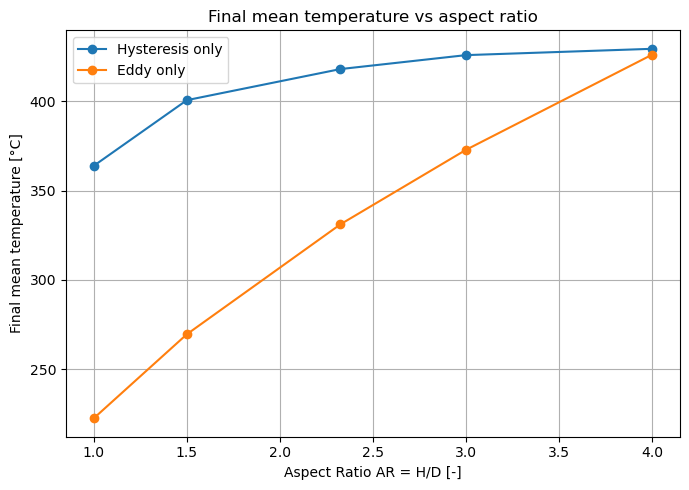

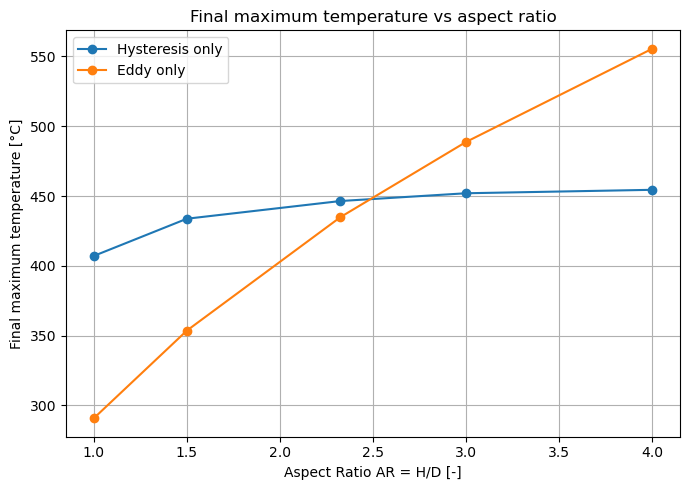

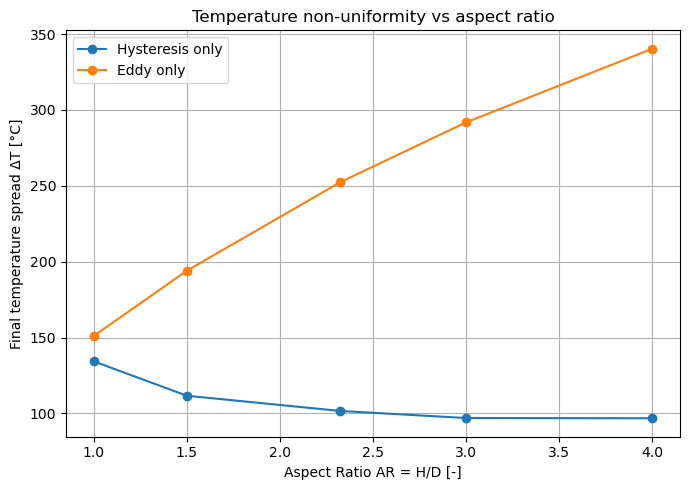

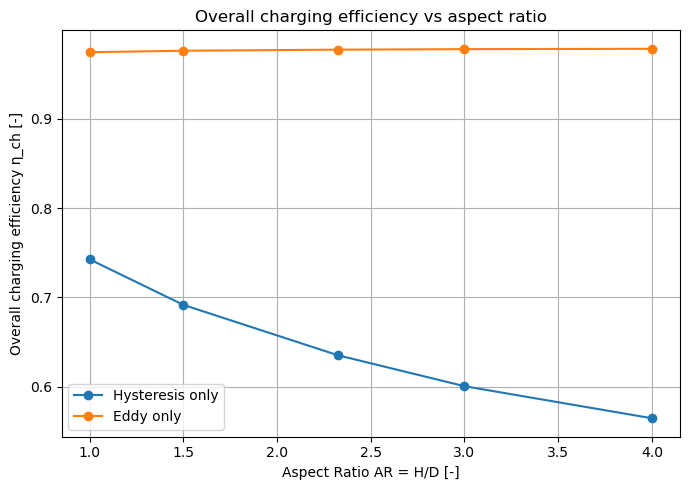

In [52]:
import matplotlib.pyplot as plt

# ============================================================
# T media finale vs AR
# ============================================================

plt.figure(figsize=(7,5))
plt.plot(df_AR["AR"], df_AR["T_mean_final_hys [°C]"], marker="o", label="Hysteresis only")
plt.plot(df_AR["AR"], df_AR["T_mean_final_eddy [°C]"], marker="o", label="Eddy only")
plt.xlabel("Aspect Ratio AR = H/D [-]")
plt.ylabel("Final mean temperature [°C]")
plt.title("Final mean temperature vs aspect ratio")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================================
# T max finale vs AR
# ============================================================

plt.figure(figsize=(7,5))
plt.plot(df_AR["AR"], df_AR["T_max_final_hys [°C]"], marker="o", label="Hysteresis only")
plt.plot(df_AR["AR"], df_AR["T_max_final_eddy [°C]"], marker="o", label="Eddy only")
plt.xlabel("Aspect Ratio AR = H/D [-]")
plt.ylabel("Final maximum temperature [°C]")
plt.title("Final maximum temperature vs aspect ratio")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================================
# DeltaT finale vs AR
# ============================================================

plt.figure(figsize=(7,5))
plt.plot(df_AR["AR"], df_AR["DeltaT_final_hys [°C]"], marker="o", label="Hysteresis only")
plt.plot(df_AR["AR"], df_AR["DeltaT_final_eddy [°C]"], marker="o", label="Eddy only")
plt.xlabel("Aspect Ratio AR = H/D [-]")
plt.ylabel("Final temperature spread ΔT [°C]")
plt.title("Temperature non-uniformity vs aspect ratio")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================================
# Eta_ch finale vs AR
# ============================================================

plt.figure(figsize=(7,5))
plt.plot(df_AR["AR"], df_AR["eta_ch_hys [-]"], marker="o", label="Hysteresis only")
plt.plot(df_AR["AR"], df_AR["eta_ch_eddy [-]"], marker="o", label="Eddy only")
plt.xlabel("Aspect Ratio AR = H/D [-]")
plt.ylabel("Overall charging efficiency η_ch [-]")
plt.title("Overall charging efficiency vs aspect ratio")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

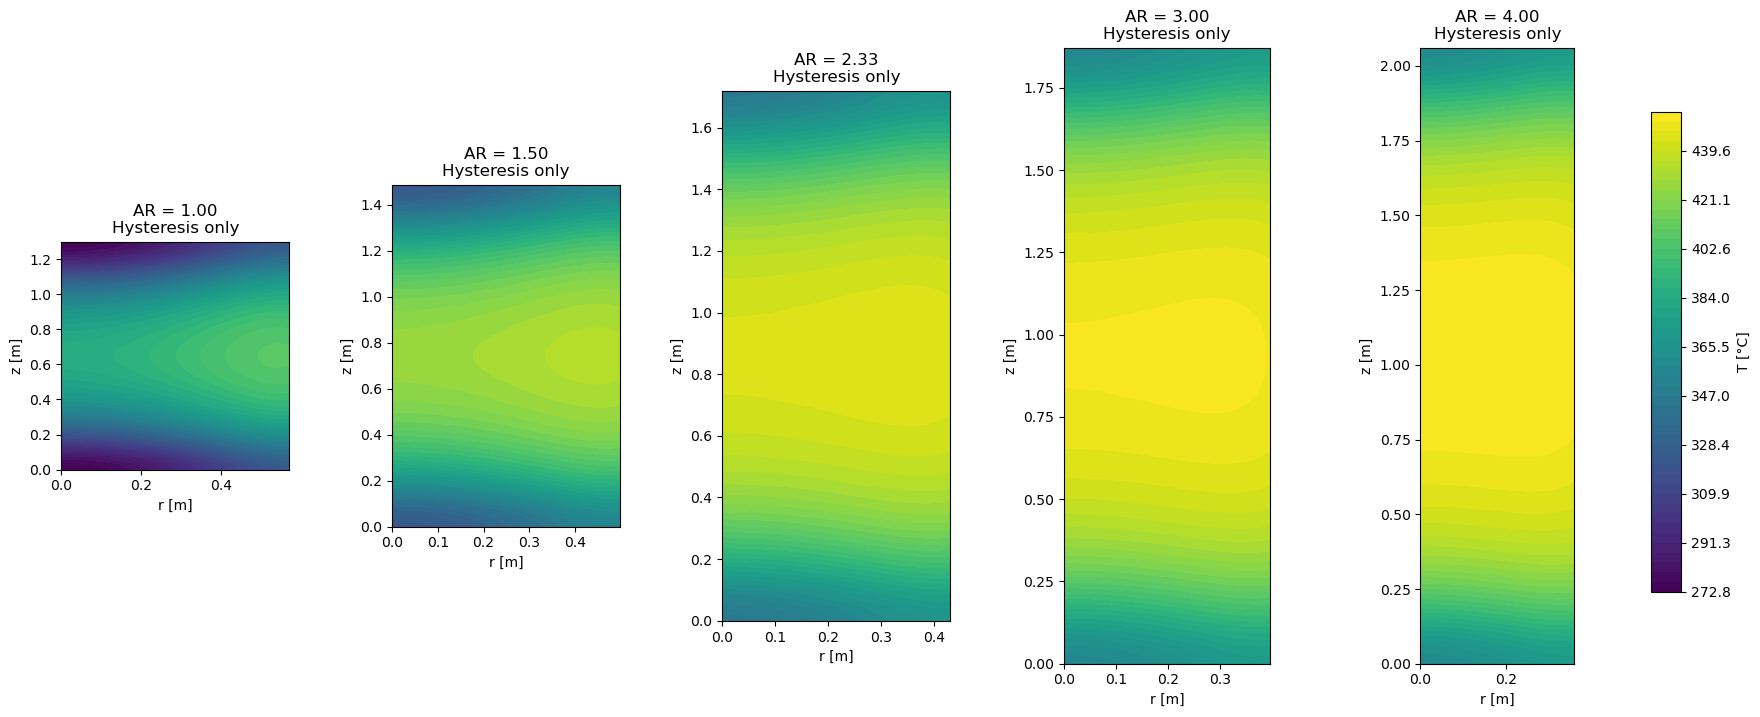

In [57]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Temperature maps - HYSTERESIS ONLY
# Aspect ratio grafico mantenuto: H/D = AR
# ============================================================

Tmin_hys = min(np.min(m["T_final_hys"] - 273.15) for m in maps_AR)
Tmax_hys = max(np.max(m["T_final_hys"] - 273.15) for m in maps_AR)

levels_hys = np.linspace(Tmin_hys, Tmax_hys, 50)

n = len(maps_AR)

fig, axes = plt.subplots(1, n, figsize=(4*n, 8), sharey=False)

if n == 1:
    axes = [axes]

for ax, m in zip(axes, maps_AR):
    T_C = m["T_final_hys"] - 273.15

    cont = ax.contourf(
        m["r"],
        m["z"],
        T_C.T,
        levels=levels_hys,
        cmap="viridis"
    )

    ax.set_title(f"AR = {m['AR']:.2f}\nHysteresis only")
    ax.set_xlabel("r [m]")
    ax.set_ylabel("z [m]")

    # Mantiene l'aspect ratio visivo richiesto: AR = H/D
    ax.set_box_aspect(m["AR"])

fig.subplots_adjust(right=0.90, wspace=0.45)

cbar_ax = fig.add_axes([0.92, 0.20, 0.015, 0.60])
cbar = fig.colorbar(cont, cax=cbar_ax)
cbar.set_label("T [°C]")

plt.show()

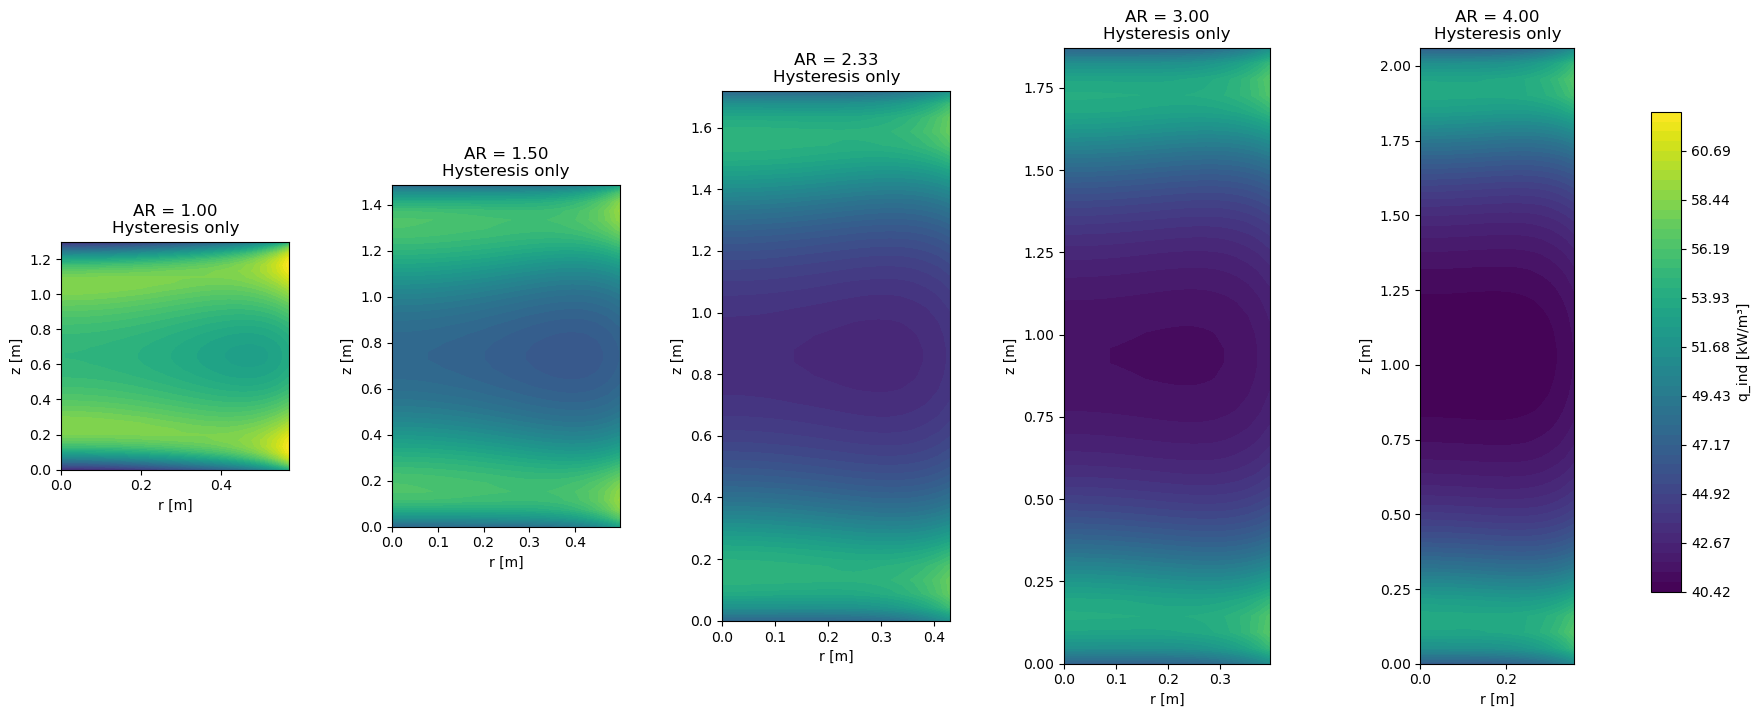

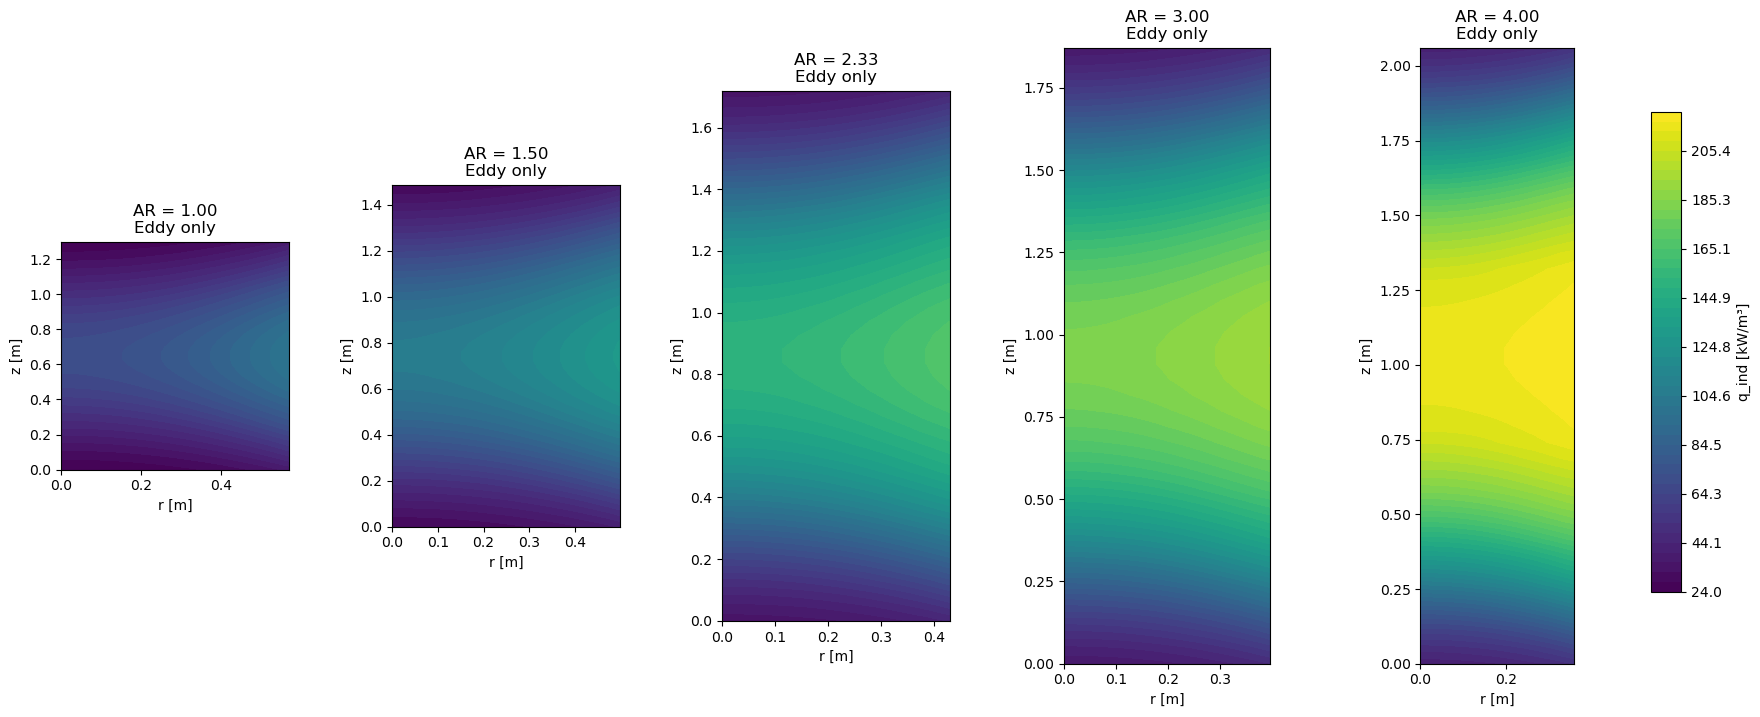

In [60]:
# ============================================================
# Power density maps - EDDY ONLY
# q_ind finale [kW/m3]
# Aspect ratio grafico mantenuto: H/D = AR
# ============================================================

qmin_eddy = min(np.min(m["q_src_eddy"] / 1000) for m in maps_AR)
qmax_eddy = max(np.max(m["q_src_eddy"] / 1000) for m in maps_AR)

levels_q_eddy = np.linspace(qmin_eddy, qmax_eddy, 50)

n = len(maps_AR)

fig, axes = plt.subplots(1, n, figsize=(4*n, 8), sharey=False)

if n == 1:
    axes = [axes]

for ax, m in zip(axes, maps_AR):
    q_map = m["q_src_eddy"] / 1000   # kW/m3

    cont = ax.contourf(
        m["r"],
        m["z"],
        q_map.T,
        levels=levels_q_eddy,
        cmap="viridis"
    )

    ax.set_title(f"AR = {m['AR']:.2f}\nEddy only")
    ax.set_xlabel("r [m]")
    ax.set_ylabel("z [m]")

    # Mantiene l'aspect ratio visivo richiesto: AR = H/D
    ax.set_box_aspect(m["AR"])

fig.subplots_adjust(right=0.90, wspace=0.45)

cbar_ax = fig.add_axes([0.92, 0.20, 0.015, 0.60])
cbar = fig.colorbar(cont, cax=cbar_ax)
cbar.set_label("q_ind [kW/m³]")

plt.show()

In [ ]:
#confronto non va bene perche non manteniamo l'average magnetic field che si crea dentro uguale per i differenti AR

In [ ]:
#cominciamo confronto giusto

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
import time
import importlib

import class_IHTES_2D_Tdep
importlib.reload(class_IHTES_2D_Tdep)

from class_IHTES_2D_Tdep import IHTES2D_Tdep

# ============================================================
# Materiali e geometria base
# ============================================================

if "TH_mag" not in globals():
    TH_mag = (5150, 670, 6)

if "EM_mag" not in globals():
    EM_mag = (100, 10, 1.0, 5200)

if "HYS_mag" not in globals():
    HYS_mag = pd.read_table("langarc_magn97.tsv", header=0, sep=",", decimal=".")

if "geom_1" not in globals():
    geom_1 = (0.86, 2, 0.2, 0.025, 0.002, 2)

# ============================================================
# Parametri
# ============================================================

H_PEAK_MIN_REQUIRED = 20e3   # limite LangArc sul campo di picco
H_RMS_MIN_REQUIRED = H_PEAK_MIN_REQUIRED / np.sqrt(2)

freq_hys = 80
I_hys_base = 2203

freq_eddy = 50000
I_eddy_base = 100.0

mesh = (20, 40)

# ============================================================
# Geometria base
# geom = (D_TES, AR_TES, e_ins, Dt_ou, et, d_coil_r)
# ============================================================

geom_base = geom_1

D_base = geom_base[0]
AR_base = geom_base[1]
H_base = D_base * AR_base
V_base = np.pi * (D_base / 2)**2 * H_base

print("D base [m] =", D_base)
print("AR base [-] =", AR_base)
print("H base [m] =", H_base)
print("V base [m3] =", V_base)

AR_list = [1.0, 1.5, AR_base, 3.0, 4.0]

# ============================================================
# Funzioni
# ============================================================

def make_geom_same_volume_correct(AR, geom_base):
    D0 = geom_base[0]
    AR0 = geom_base[1]
    H0 = D0 * AR0
    V0 = np.pi * (D0 / 2)**2 * H0

    D_new = (4 * V0 / (np.pi * AR))**(1/3)
    H_new = AR * D_new

    geom_new = list(geom_base)
    geom_new[0] = D_new
    geom_new[1] = AR

    return tuple(geom_new), D_new, H_new


def H_stats_for_geom(geom, I=1.0, mesh=(20, 40)):
    tes_tmp = IHTES2D_Tdep(TH_mag, EM_mag, HYS_mag, geom, mesh=mesh)
    _, _, _, H_rms_map = tes_tmp.field_map(I)

    Havg_rms = tes_tmp.volume_average(H_rms_map)
    Hmin_rms = np.min(H_rms_map)
    Hmax_rms = np.max(H_rms_map)

    Havg_peak = np.sqrt(2) * Havg_rms
    Hmin_peak = np.sqrt(2) * Hmin_rms
    Hmax_peak = np.sqrt(2) * Hmax_rms

    return Havg_rms, Hmin_rms, Hmax_rms, Havg_peak, Hmin_peak, Hmax_peak

# ============================================================
# Target base
# ============================================================

Havg_base_hys_rms, Hmin_base_hys_rms, Hmax_base_hys_rms, Havg_base_hys_peak, Hmin_base_hys_peak, Hmax_base_hys_peak = H_stats_for_geom(
    geom_base,
    I=I_hys_base,
    mesh=mesh
)

Havg_base_eddy_rms, Hmin_base_eddy_rms, Hmax_base_eddy_rms, Havg_base_eddy_peak, Hmin_base_eddy_peak, Hmax_base_eddy_peak = H_stats_for_geom(
    geom_base,
    I=I_eddy_base,
    mesh=mesh
)

print("\n=== HYSTERESIS BASE ===")
print("freq_hys [Hz] =", freq_hys)
print("I_hys_base [A] =", I_hys_base)
print("Havg_base_hys_rms [kA/m]  =", Havg_base_hys_rms / 1000)
print("Hmin_base_hys_rms [kA/m]  =", Hmin_base_hys_rms / 1000)
print("Hmax_base_hys_rms [kA/m]  =", Hmax_base_hys_rms / 1000)
print("Havg_base_hys_peak [kA/m] =", Havg_base_hys_peak / 1000)
print("Hmin_base_hys_peak [kA/m] =", Hmin_base_hys_peak / 1000)
print("Hmax_base_hys_peak [kA/m] =", Hmax_base_hys_peak / 1000)

print("\n=== EDDY BASE ===")
print("freq_eddy [Hz] =", freq_eddy)
print("I_eddy_base [A] =", I_eddy_base)
print("Havg_base_eddy_rms [kA/m]  =", Havg_base_eddy_rms / 1000)
print("Hmin_base_eddy_rms [kA/m]  =", Hmin_base_eddy_rms / 1000)
print("Hmax_base_eddy_rms [kA/m]  =", Hmax_base_eddy_rms / 1000)

# ============================================================
# Correnti per ogni AR
# ============================================================

rows = []

for AR in AR_list:
    geom_AR, D_AR, H_AR = make_geom_same_volume_correct(AR, geom_base)

    Havg_1A_rms, Hmin_1A_rms, Hmax_1A_rms, Havg_1A_peak, Hmin_1A_peak, Hmax_1A_peak = H_stats_for_geom(
        geom_AR,
        I=1.0,
        mesh=mesh
    )

    # HYSTERESIS:
    # target = stesso Havg_rms del caso base 2203 A
    I_hys_const_Havg = Havg_base_hys_rms / Havg_1A_rms

    Havg_hys_rms = Havg_1A_rms * I_hys_const_Havg
    Hmin_hys_rms = Hmin_1A_rms * I_hys_const_Havg
    Hmax_hys_rms = Hmax_1A_rms * I_hys_const_Havg

    Havg_hys_peak = np.sqrt(2) * Havg_hys_rms
    Hmin_hys_peak = np.sqrt(2) * Hmin_hys_rms
    Hmax_hys_peak = np.sqrt(2) * Hmax_hys_rms

    # Se qualche AR scendesse sotto H_peak_min, allora servirebbe aumentare il target.
    # In questo caso ci aspettiamo che il base sia circa al limite.
    Havg_required_rms_for_Hpeak20 = H_RMS_MIN_REQUIRED * Havg_1A_rms / Hmin_1A_rms

    # EDDY:
    # target = stesso Havg_rms del caso base eddy 50 kHz, 100 A
    I_eddy_const_Havg = Havg_base_eddy_rms / Havg_1A_rms

    Havg_eddy_rms = Havg_1A_rms * I_eddy_const_Havg
    Hmin_eddy_rms = Hmin_1A_rms * I_eddy_const_Havg
    Hmax_eddy_rms = Hmax_1A_rms * I_eddy_const_Havg

    rows.append({
        "AR": AR,
        "D_PB [m]": D_AR,
        "H_PB [m]": H_AR,

        "Havg_1A_rms [A/m]": Havg_1A_rms,
        "Hmin_1A_rms [A/m]": Hmin_1A_rms,
        "Hmax_1A_rms [A/m]": Hmax_1A_rms,

        "I_hys_const_Havg [A]": I_hys_const_Havg,
        "Havg_hys_rms [kA/m]": Havg_hys_rms / 1000,
        "Hmin_hys_rms [kA/m]": Hmin_hys_rms / 1000,
        "Hmax_hys_rms [kA/m]": Hmax_hys_rms / 1000,
        "Havg_hys_peak [kA/m]": Havg_hys_peak / 1000,
        "Hmin_hys_peak [kA/m]": Hmin_hys_peak / 1000,
        "Hmax_hys_peak [kA/m]": Hmax_hys_peak / 1000,
        "Havg_required_rms_for_Hpeak20 [A/m]": Havg_required_rms_for_Hpeak20,

        "I_eddy_const_Havg [A]": I_eddy_const_Havg,
        "Havg_eddy_rms [kA/m]": Havg_eddy_rms / 1000,
        "Hmin_eddy_rms [kA/m]": Hmin_eddy_rms / 1000,
        "Hmax_eddy_rms [kA/m]": Hmax_eddy_rms / 1000,
    })

df_Hcheck = pd.DataFrame(rows)

display(df_Hcheck.round(3))

print("\nCheck hysteresis:")
print("Hmin_hys_peak minimo tra tutti gli AR [kA/m] =", df_Hcheck["Hmin_hys_peak [kA/m]"].min())
print("Target richiesto LangArc [kA/m] =", H_PEAK_MIN_REQUIRED / 1000)

D base [m] = 0.86
AR base [-] = 2
H base [m] = 1.72
V base [m3] = 0.9991144284358546

=== HYSTERESIS BASE ===
freq_hys [Hz] = 80
I_hys_base [A] = 2203
Havg_base_hys_rms [kA/m]  = 20.881424907002614
Hmin_base_hys_rms [kA/m]  = 14.138501582097929
Hmax_base_hys_rms [kA/m]  = 23.879947744238393
Havg_base_hys_peak [kA/m] = 29.53079430515844
Hmin_base_hys_peak [kA/m] = 19.99486068903635
Hmax_base_hys_peak [kA/m] = 33.771345968662736

=== EDDY BASE ===
freq_eddy [Hz] = 50000
I_eddy_base [A] = 100.0
Havg_base_eddy_rms [kA/m]  = 0.9478631369497328
Hmin_base_eddy_rms [kA/m]  = 0.6417840028187893
Hmax_base_eddy_rms [kA/m]  = 1.0839740237965683


,AR,D_PB [m],H_PB [m],Havg_1A_rms [A/m],Hmin_1A_rms [A/m],Hmax_1A_rms [A/m],I_hys_const_Havg [A],Havg_hys_rms [kA/m],Hmin_hys_rms [kA/m],Hmax_hys_rms [kA/m],Havg_hys_peak [kA/m],Hmin_hys_peak [kA/m],Hmax_hys_peak [kA/m],Havg_required_rms_for_Hpeak20 [A/m],I_eddy_const_Havg [A],Havg_eddy_rms [kA/m],Hmin_eddy_rms [kA/m],Hmax_eddy_rms [kA/m]
0,1.0,1.084,1.084,7.264,5.346,8.550,2874.662,20.881,15.369,24.578,29.531,21.735,34.758,19214.849,130.489,0.948,0.698,1.116
1,1.5,0.947,1.420,8.727,6.127,10.079,2392.869,20.881,14.662,24.117,29.531,20.735,34.107,20141.155,108.619,0.948,0.666,1.095
2,2.0,0.860,1.720,9.479,6.418,10.840,2203.000,20.881,14.139,23.880,29.531,19.995,33.771,20886.792,100.000,0.948,0.642,1.084
3,3.0,0.751,2.254,10.342,6.674,11.669,2019.187,20.881,13.476,23.562,29.531,19.058,33.321,21913.037,91.656,0.948,0.612,1.070
4,4.0,0.683,2.730,10.767,6.752,12.017,1939.382,20.881,13.095,23.306,29.531,18.520,32.960,22550.609,88.034,0.948,0.594,1.058



Check hysteresis:
Hmin_hys_peak minimo tra tutti gli AR [kA/m] = 18.5196102763943
Target richiesto LangArc [kA/m] = 20.0


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
import time
import importlib

# ============================================================
# Import classe 2D T-dependent
# ============================================================

import class_IHTES_2D_Tdep
importlib.reload(class_IHTES_2D_Tdep)

from class_IHTES_2D_Tdep import IHTES2D_Tdep


# ============================================================
# Materiali e geometria base
# ============================================================

if "TH_mag" not in globals():
    TH_mag = (5150, 670, 6)

if "EM_mag" not in globals():
    EM_mag = (100, 10, 1.0, 5200)

if "HYS_mag" not in globals():
    HYS_mag = pd.read_table("langarc_magn97.tsv", header=0, sep=",", decimal=".")

if "geom_1" not in globals():
    geom_1 = (0.86, 2, 0.2, 0.025, 0.002, 2)


# ============================================================
# Parametri dei due casi
# ============================================================

# Hysteresis-only
freq_hys = 80
I_hys_base = 2203

# Eddy-only
freq_eddy = 50000
I_eddy_base = 100.0

# Limite LangArc sul campo DI PICCO
H_PEAK_MIN_REQUIRED = 20e3  # [A/m]
H_RMS_MIN_REQUIRED = H_PEAK_MIN_REQUIRED / np.sqrt(2)

mesh = (20, 40)


# ============================================================
# Geometria base
# geom = (D_TES, AR_TES, e_ins, Dt_ou, et, d_coil_r)
# H_TES = D_TES * AR_TES
# ============================================================

geom_base = geom_1

D_base = geom_base[0]
AR_base = geom_base[1]
H_base = D_base * AR_base
V_base = np.pi * (D_base / 2)**2 * H_base

print("D base [m] =", D_base)
print("AR base [-] =", AR_base)
print("H base [m] =", H_base)
print("V base [m3] =", V_base)

AR_list = [1.0, 1.5, AR_base, 3.0, 4.0]


# ============================================================
# Funzione geometria a volume costante
# ============================================================

def make_geom_same_volume_correct(AR, geom_base):
    """
    Crea una nuova geometria mantenendo costante il volume del PB.

    geom = (D_TES, AR_TES, e_ins, Dt_ou, et, d_coil_r)
    quindi il secondo valore è AR, non H.
    """

    D0 = geom_base[0]
    AR0 = geom_base[1]
    H0 = D0 * AR0
    V0 = np.pi * (D0 / 2)**2 * H0

    D_new = (4 * V0 / (np.pi * AR))**(1/3)
    H_new = AR * D_new

    geom_new = list(geom_base)
    geom_new[0] = D_new
    geom_new[1] = AR

    return tuple(geom_new), D_new, H_new


# ============================================================
# Funzione statistiche campo magnetico
# ============================================================

def H_stats_for_geom(geom, I=1.0, mesh=(20, 40)):
    """
    Restituisce H medio/min/max RMS e peak nel PB.
    """
    tes_tmp = IHTES2D_Tdep(TH_mag, EM_mag, HYS_mag, geom, mesh=mesh)
    _, _, _, H_rms_map = tes_tmp.field_map(I)

    Havg_rms = tes_tmp.volume_average(H_rms_map)
    Hmin_rms = np.min(H_rms_map)
    Hmax_rms = np.max(H_rms_map)

    Havg_peak = np.sqrt(2) * Havg_rms
    Hmin_peak = np.sqrt(2) * Hmin_rms
    Hmax_peak = np.sqrt(2) * Hmax_rms

    return Havg_rms, Hmin_rms, Hmax_rms, Havg_peak, Hmin_peak, Hmax_peak


# ============================================================
# Target base hysteresis
# ============================================================

Havg_base_hys_rms, Hmin_base_hys_rms, Hmax_base_hys_rms, Havg_base_hys_peak, Hmin_base_hys_peak, Hmax_base_hys_peak = H_stats_for_geom(
    geom_base,
    I=I_hys_base,
    mesh=mesh
)


# ============================================================
# Target base eddy
# ============================================================

Havg_base_eddy_rms, Hmin_base_eddy_rms, Hmax_base_eddy_rms, Havg_base_eddy_peak, Hmin_base_eddy_peak, Hmax_base_eddy_peak = H_stats_for_geom(
    geom_base,
    I=I_eddy_base,
    mesh=mesh
)


print("\n=== HYSTERESIS BASE ===")
print("freq_hys [Hz] =", freq_hys)
print("I_hys_base [A] =", I_hys_base)
print("Havg_base_hys_rms [kA/m]  =", Havg_base_hys_rms / 1000)
print("Hmin_base_hys_rms [kA/m]  =", Hmin_base_hys_rms / 1000)
print("Hmax_base_hys_rms [kA/m]  =", Hmax_base_hys_rms / 1000)
print("Havg_base_hys_peak [kA/m] =", Havg_base_hys_peak / 1000)
print("Hmin_base_hys_peak [kA/m] =", Hmin_base_hys_peak / 1000)
print("Hmax_base_hys_peak [kA/m] =", Hmax_base_hys_peak / 1000)

print("\n=== EDDY BASE ===")
print("freq_eddy [Hz] =", freq_eddy)
print("I_eddy_base [A] =", I_eddy_base)
print("Havg_base_eddy_rms [kA/m]  =", Havg_base_eddy_rms / 1000)
print("Hmin_base_eddy_rms [kA/m]  =", Hmin_base_eddy_rms / 1000)
print("Hmax_base_eddy_rms [kA/m]  =", Hmax_base_eddy_rms / 1000)


# ============================================================
# Tabella correnti per ogni AR
# ============================================================

rows = []

for AR in AR_list:

    geom_AR, D_AR, H_AR = make_geom_same_volume_correct(AR, geom_base)

    Havg_1A_rms, Hmin_1A_rms, Hmax_1A_rms, Havg_1A_peak, Hmin_1A_peak, Hmax_1A_peak = H_stats_for_geom(
        geom_AR,
        I=1.0,
        mesh=mesh
    )

    # --------------------------------------------------------
    # HYSTERESIS:
    # 1) target iniziale = stesso Havg_rms del caso base 2203 A
    # 2) controllo Hmin_peak
    # --------------------------------------------------------

    I_hys_const_Havg = Havg_base_hys_rms / Havg_1A_rms

    Havg_hys_rms = Havg_1A_rms * I_hys_const_Havg
    Hmin_hys_rms = Hmin_1A_rms * I_hys_const_Havg
    Hmax_hys_rms = Hmax_1A_rms * I_hys_const_Havg

    Havg_hys_peak = np.sqrt(2) * Havg_hys_rms
    Hmin_hys_peak = np.sqrt(2) * Hmin_hys_rms
    Hmax_hys_peak = np.sqrt(2) * Hmax_hys_rms

    # Havg_rms richiesto per avere Hmin_peak >= 20 kA/m
    Havg_required_rms_for_Hpeak20 = H_RMS_MIN_REQUIRED * Havg_1A_rms / Hmin_1A_rms

    # --------------------------------------------------------
    # EDDY:
    # target = stesso Havg_rms del caso base 50 kHz, 100 A
    # nessun vincolo Hmin_peak
    # --------------------------------------------------------

    I_eddy_const_Havg = Havg_base_eddy_rms / Havg_1A_rms

    Havg_eddy_rms = Havg_1A_rms * I_eddy_const_Havg
    Hmin_eddy_rms = Hmin_1A_rms * I_eddy_const_Havg
    Hmax_eddy_rms = Hmax_1A_rms * I_eddy_const_Havg

    rows.append({
        "AR": AR,
        "D_PB [m]": D_AR,
        "H_PB [m]": H_AR,

        "Havg_1A_rms [A/m]": Havg_1A_rms,
        "Hmin_1A_rms [A/m]": Hmin_1A_rms,
        "Hmax_1A_rms [A/m]": Hmax_1A_rms,

        "I_hys_const_Havg [A]": I_hys_const_Havg,
        "Havg_hys_rms [kA/m]": Havg_hys_rms / 1000,
        "Hmin_hys_rms [kA/m]": Hmin_hys_rms / 1000,
        "Hmax_hys_rms [kA/m]": Hmax_hys_rms / 1000,
        "Havg_hys_peak [kA/m]": Havg_hys_peak / 1000,
        "Hmin_hys_peak [kA/m]": Hmin_hys_peak / 1000,
        "Hmax_hys_peak [kA/m]": Hmax_hys_peak / 1000,
        "Havg_required_rms_for_Hpeak20 [A/m]": Havg_required_rms_for_Hpeak20,

        "I_eddy_const_Havg [A]": I_eddy_const_Havg,
        "Havg_eddy_rms [kA/m]": Havg_eddy_rms / 1000,
        "Hmin_eddy_rms [kA/m]": Hmin_eddy_rms / 1000,
        "Hmax_eddy_rms [kA/m]": Hmax_eddy_rms / 1000,
    })


df_Hcheck = pd.DataFrame(rows)


# ============================================================
# Target finale HYSTERESIS corretto:
# stesso Havg_rms per tutti gli AR,
# ma abbastanza alto da garantire Hmin_peak >= 20 kA/m
# ============================================================

Havg_target_hys_safe_rms = max(
    Havg_base_hys_rms,
    df_Hcheck["Havg_required_rms_for_Hpeak20 [A/m]"].max()
)


df_Hcheck["I_hys_safe [A]"] = (
    Havg_target_hys_safe_rms / df_Hcheck["Havg_1A_rms [A/m]"]
)

df_Hcheck["Havg_hys_safe_rms [kA/m]"] = (
    df_Hcheck["Havg_1A_rms [A/m]"] * df_Hcheck["I_hys_safe [A]"] / 1000
)

df_Hcheck["Hmin_hys_safe_rms [kA/m]"] = (
    df_Hcheck["Hmin_1A_rms [A/m]"] * df_Hcheck["I_hys_safe [A]"] / 1000
)

df_Hcheck["Hmax_hys_safe_rms [kA/m]"] = (
    df_Hcheck["Hmax_1A_rms [A/m]"] * df_Hcheck["I_hys_safe [A]"] / 1000
)

df_Hcheck["Havg_hys_safe_peak [kA/m]"] = (
    np.sqrt(2) * df_Hcheck["Havg_hys_safe_rms [kA/m]"]
)

df_Hcheck["Hmin_hys_safe_peak [kA/m]"] = (
    np.sqrt(2) * df_Hcheck["Hmin_hys_safe_rms [kA/m]"]
)

df_Hcheck["Hmax_hys_safe_peak [kA/m]"] = (
    np.sqrt(2) * df_Hcheck["Hmax_hys_safe_rms [kA/m]"]
)


# ============================================================
# Target finale EDDY corretto:
# stesso Havg_rms del caso base eddy 50 kHz, 100 A
# ============================================================

df_Hcheck["I_eddy_const [A]"] = df_Hcheck["I_eddy_const_Havg [A]"]

df_Hcheck["Havg_eddy_const_rms [kA/m]"] = (
    df_Hcheck["Havg_1A_rms [A/m]"] * df_Hcheck["I_eddy_const [A]"] / 1000
)

df_Hcheck["Hmin_eddy_const_rms [kA/m]"] = (
    df_Hcheck["Hmin_1A_rms [A/m]"] * df_Hcheck["I_eddy_const [A]"] / 1000
)

df_Hcheck["Hmax_eddy_const_rms [kA/m]"] = (
    df_Hcheck["Hmax_1A_rms [A/m]"] * df_Hcheck["I_eddy_const [A]"] / 1000
)


print("\n=== TARGET FINALI CORRETTI ===")
print("Havg target hysteresis safe RMS [kA/m] =", Havg_target_hys_safe_rms / 1000)
print("Havg target hysteresis safe PEAK [kA/m] =", np.sqrt(2) * Havg_target_hys_safe_rms / 1000)
print("Minimum H_peak hysteresis after correction [kA/m] =", df_Hcheck["Hmin_hys_safe_peak [kA/m]"].min())

print("\nHavg target eddy RMS [kA/m] =", Havg_base_eddy_rms / 1000)

display(df_Hcheck.round(3))

D base [m] = 0.86
AR base [-] = 2
H base [m] = 1.72
V base [m3] = 0.9991144284358546

=== HYSTERESIS BASE ===
freq_hys [Hz] = 80
I_hys_base [A] = 2203
Havg_base_hys_rms [kA/m]  = 20.881424907002614
Hmin_base_hys_rms [kA/m]  = 14.138501582097929
Hmax_base_hys_rms [kA/m]  = 23.879947744238393
Havg_base_hys_peak [kA/m] = 29.53079430515844
Hmin_base_hys_peak [kA/m] = 19.99486068903635
Hmax_base_hys_peak [kA/m] = 33.771345968662736

=== EDDY BASE ===
freq_eddy [Hz] = 50000
I_eddy_base [A] = 100.0
Havg_base_eddy_rms [kA/m]  = 0.9478631369497328
Hmin_base_eddy_rms [kA/m]  = 0.6417840028187893
Hmax_base_eddy_rms [kA/m]  = 1.0839740237965683

=== TARGET FINALI CORRETTI ===
Havg target hysteresis safe RMS [kA/m] = 22.550609430068583
Havg target hysteresis safe PEAK [kA/m] = 31.891377695781603
Minimum H_peak hysteresis after correction [kA/m] = 19.999999999999996

Havg target eddy RMS [kA/m] = 0.9478631369497328


,AR,D_PB [m],H_PB [m],Havg_1A_rms [A/m],Hmin_1A_rms [A/m],Hmax_1A_rms [A/m],I_hys_const_Havg [A],Havg_hys_rms [kA/m],Hmin_hys_rms [kA/m],Hmax_hys_rms [kA/m],...,Havg_hys_safe_rms [kA/m],Hmin_hys_safe_rms [kA/m],Hmax_hys_safe_rms [kA/m],Havg_hys_safe_peak [kA/m],Hmin_hys_safe_peak [kA/m],Hmax_hys_safe_peak [kA/m],I_eddy_const [A],Havg_eddy_const_rms [kA/m],Hmin_eddy_const_rms [kA/m],Hmax_eddy_const_rms [kA/m]
0,1.0,1.084,1.084,7.264,5.346,8.550,2874.662,20.881,15.369,24.578,...,22.551,16.597,26.542,31.891,23.472,37.536,130.489,0.948,0.698,1.116
1,1.5,0.947,1.420,8.727,6.127,10.079,2392.869,20.881,14.662,24.117,...,22.551,15.834,26.045,31.891,22.393,36.833,108.619,0.948,0.666,1.095
2,2.0,0.860,1.720,9.479,6.418,10.840,2203.000,20.881,14.139,23.880,...,22.551,15.269,25.789,31.891,21.593,36.471,100.000,0.948,0.642,1.084
3,3.0,0.751,2.254,10.342,6.674,11.669,2019.187,20.881,13.476,23.562,...,22.551,14.554,25.445,31.891,20.582,35.985,91.656,0.948,0.612,1.070
4,4.0,0.683,2.730,10.767,6.752,12.017,1939.382,20.881,13.095,23.306,...,22.551,14.142,25.169,31.891,20.000,35.594,88.034,0.948,0.594,1.058


In [22]:
# ============================================================
# Parametri simulazione
# ============================================================

T_init = 293.15
T_amb = 293.15
ch_time = 3 * 3600
dt = 10.0
mesh = (20, 40)


# ============================================================
# Cartella backup
# ============================================================

desktop_onedrive = Path.home() / "OneDrive" / "Desktop"
desktop_normal = Path.home() / "Desktop"
desktop = desktop_onedrive if desktop_onedrive.exists() else desktop_normal

save_folder = desktop / "AR_sensitivity_Havg_corrected_RMS_PEAK"
save_folder.mkdir(exist_ok=True)

print("Backup salvati in:")
print(save_folder)


# ============================================================
# Funzioni utili
# ============================================================

def volume_weighted_std_T(tes, T_map):
    T = np.asarray(T_map, dtype=float)
    W = tes.volume_weights()

    T_avg = np.sum(T * W) / np.sum(W)
    T_std = np.sqrt(np.sum(W * (T - T_avg)**2) / np.sum(W))

    return T_std


def compute_final_efficiencies(tes, freq, I, q_mean, T_mean, T_amb=293.15, Tcoil_ref=333.15):
    V_pb = np.pi * (tes.D_TES / 2)**2 * tes.H_TES

    P_ind = q_mean * V_pb
    P_coil = tes.Pcoil(freq, I, Tcoil_ref)
    eta_conv = tes.eta_conv(freq)

    R_pb = tes.D_TES / 2
    A_side = np.pi * tes.D_TES * tes.H_TES
    A_tb = 2 * np.pi * R_pb**2

    if hasattr(tes, "last_h_eq_side"):
        h_side = tes.last_h_eq_side
    else:
        h_side = tes.heq_from_Pamb(T_amb)

    if hasattr(tes, "last_h_eq_top_bottom"):
        h_tb = tes.last_h_eq_top_bottom
    elif hasattr(tes, "heq_top_bottom_from_Pamb"):
        h_tb = tes.heq_top_bottom_from_Pamb(T_amb)
    else:
        h_tb = 0.0

    P_amb = h_side * A_side * (T_mean - T_amb) + h_tb * A_tb * (T_mean - T_amb)

    P_ch = P_ind - P_amb

    eta_ind = P_ind / (P_ind + P_coil)
    eta_th = P_ch / P_ind
    eta_ch = eta_conv * eta_ind * eta_th

    return P_ind, P_coil, P_amb, P_ch, eta_ind, eta_th, eta_conv, eta_ch


# ============================================================
# Liste risultati
# ============================================================

results_AR_corrected = []
maps_AR_corrected = []


# ============================================================
# Loop AR
# ============================================================

for idx, row in df_Hcheck.iterrows():

    AR = row["AR"]

    # Hysteresis:
    # Havg_rms costante e Hmin_peak >= 20 kA/m
    I_hys_AR = row["I_hys_safe [A]"]

    # Eddy:
    # Havg_rms costante rispetto al caso base 50 kHz, 100 A
    I_eddy_AR = row["I_eddy_const [A]"]

    t0 = time.time()

    print("\n====================================", flush=True)
    print("Running AR =", AR, flush=True)
    print("I_hys_safe [A] =", I_hys_AR, flush=True)
    print("I_eddy_const [A] =", I_eddy_AR, flush=True)
    print("====================================", flush=True)

    geom_AR, D_AR, H_AR = make_geom_same_volume_correct(AR, geom_base)
    V_AR = np.pi * (D_AR / 2)**2 * H_AR

    tes_AR = IHTES2D_Tdep(TH_mag, EM_mag, HYS_mag, geom_AR, mesh=mesh)

    # ========================================================
    # Check campo magnetico
    # ========================================================

    _, _, _, H_hys_rms_map = tes_AR.field_map(I_hys_AR)
    _, _, _, H_eddy_rms_map = tes_AR.field_map(I_eddy_AR)

    Havg_hys_rms = tes_AR.volume_average(H_hys_rms_map)
    Hmin_hys_rms = np.min(H_hys_rms_map)
    Hmax_hys_rms = np.max(H_hys_rms_map)

    Havg_hys_peak = np.sqrt(2) * Havg_hys_rms
    Hmin_hys_peak = np.sqrt(2) * Hmin_hys_rms
    Hmax_hys_peak = np.sqrt(2) * Hmax_hys_rms

    Havg_eddy_rms = tes_AR.volume_average(H_eddy_rms_map)
    Hmin_eddy_rms = np.min(H_eddy_rms_map)
    Hmax_eddy_rms = np.max(H_eddy_rms_map)

    # ========================================================
    # HYSTERESIS ONLY
    # ========================================================

    print("Running hysteresis-only...", flush=True)

    time_h, T_mean_h, T_max_h, T_final_h, snapshot_times_h, snapshots_h, q_src_h, h_eq_h, q_mean_h, q_max_h = tes_AR.charging_2D_nonuniform_Tdep(
        freq=freq_hys,
        I=I_hys_AR,
        T_init=T_init,
        T_amb=T_amb,
        ch_time=ch_time,
        dt=dt,
        save_every=500,
        source_mode="hys_only"
    )

    P_ind_h, P_coil_h, P_amb_h, P_ch_h, eta_ind_h, eta_th_h, eta_conv_h, eta_ch_h = compute_final_efficiencies(
        tes=tes_AR,
        freq=freq_hys,
        I=I_hys_AR,
        q_mean=q_mean_h[-1],
        T_mean=T_mean_h[-1],
        T_amb=T_amb
    )

    # ========================================================
    # EDDY ONLY
    # ========================================================

    print("Running eddy-only...", flush=True)

    time_e, T_mean_e, T_max_e, T_final_e, snapshot_times_e, snapshots_e, q_src_e, h_eq_e, q_mean_e, q_max_e = tes_AR.charging_2D_nonuniform_Tdep(
        freq=freq_eddy,
        I=I_eddy_AR,
        T_init=T_init,
        T_amb=T_amb,
        ch_time=ch_time,
        dt=dt,
        save_every=500,
        source_mode="eddy_only"
    )

    P_ind_e, P_coil_e, P_amb_e, P_ch_e, eta_ind_e, eta_th_e, eta_conv_e, eta_ch_e = compute_final_efficiencies(
        tes=tes_AR,
        freq=freq_eddy,
        I=I_eddy_AR,
        q_mean=q_mean_e[-1],
        T_mean=T_mean_e[-1],
        T_amb=T_amb
    )

    # ========================================================
    # Tabella numerica
    # ========================================================

    results_AR_corrected.append({
        "AR": AR,
        "D_PB [m]": D_AR,
        "H_PB [m]": H_AR,
        "V_PB [m3]": V_AR,

        "I_hys [A]": I_hys_AR,
        "Havg_hys_rms [kA/m]": Havg_hys_rms / 1000,
        "Hmin_hys_rms [kA/m]": Hmin_hys_rms / 1000,
        "Hmax_hys_rms [kA/m]": Hmax_hys_rms / 1000,
        "Havg_hys_peak [kA/m]": Havg_hys_peak / 1000,
        "Hmin_hys_peak [kA/m]": Hmin_hys_peak / 1000,
        "Hmax_hys_peak [kA/m]": Hmax_hys_peak / 1000,

        "I_eddy [A]": I_eddy_AR,
        "Havg_eddy_rms [kA/m]": Havg_eddy_rms / 1000,
        "Hmin_eddy_rms [kA/m]": Hmin_eddy_rms / 1000,
        "Hmax_eddy_rms [kA/m]": Hmax_eddy_rms / 1000,

        # Hysteresis
        "T_min_final_hys [°C]": np.min(T_final_h) - 273.15,
        "T_mean_final_hys [°C]": T_mean_h[-1] - 273.15,
        "T_max_final_hys [°C]": T_max_h[-1] - 273.15,
        "DeltaT_final_hys [°C]": np.max(T_final_h) - np.min(T_final_h),
        "T_std_final_hys [°C]": volume_weighted_std_T(tes_AR, T_final_h),
        "q_mean_final_hys [kW/m3]": q_mean_h[-1] / 1000,
        "q_max_final_hys [kW/m3]": q_max_h[-1] / 1000,
        "P_ind_final_hys [kW]": P_ind_h / 1000,
        "P_coil_hys [kW]": P_coil_h / 1000,
        "P_amb_final_hys [kW]": P_amb_h / 1000,
        "P_ch_final_hys [kW]": P_ch_h / 1000,
        "eta_ind_hys [-]": eta_ind_h,
        "eta_th_hys [-]": eta_th_h,
        "eta_conv_hys [-]": eta_conv_h,
        "eta_ch_hys [-]": eta_ch_h,

        # Eddy
        "T_min_final_eddy [°C]": np.min(T_final_e) - 273.15,
        "T_mean_final_eddy [°C]": T_mean_e[-1] - 273.15,
        "T_max_final_eddy [°C]": T_max_e[-1] - 273.15,
        "DeltaT_final_eddy [°C]": np.max(T_final_e) - np.min(T_final_e),
        "T_std_final_eddy [°C]": volume_weighted_std_T(tes_AR, T_final_e),
        "q_mean_final_eddy [kW/m3]": q_mean_e[-1] / 1000,
        "q_max_final_eddy [kW/m3]": q_max_e[-1] / 1000,
        "P_ind_final_eddy [kW]": P_ind_e / 1000,
        "P_coil_eddy [kW]": P_coil_e / 1000,
        "P_amb_final_eddy [kW]": P_amb_e / 1000,
        "P_ch_final_eddy [kW]": P_ch_e / 1000,
        "eta_ind_eddy [-]": eta_ind_e,
        "eta_th_eddy [-]": eta_th_e,
        "eta_conv_eddy [-]": eta_conv_e,
        "eta_ch_eddy [-]": eta_ch_e,
    })

    # ========================================================
    # Mappe finali
    # ========================================================

    maps_AR_corrected.append({
        "AR": AR,
        "D_PB [m]": D_AR,
        "H_PB [m]": H_AR,
        "V_PB [m3]": V_AR,

        "I_hys [A]": I_hys_AR,
        "Havg_hys_rms [kA/m]": Havg_hys_rms / 1000,
        "Hmin_hys_peak [kA/m]": Hmin_hys_peak / 1000,

        "I_eddy [A]": I_eddy_AR,
        "Havg_eddy_rms [kA/m]": Havg_eddy_rms / 1000,

        "r": tes_AR.r.copy(),
        "z": tes_AR.z.copy(),
        "T_final_hys": T_final_h.copy(),
        "T_final_eddy": T_final_e.copy(),
        "q_src_hys": q_src_h.copy(),
        "q_src_eddy": q_src_e.copy()
    })

    # ========================================================
    # Backup progressivo
    # ========================================================

    df_partial = pd.DataFrame(results_AR_corrected)

    with open(save_folder / "AR_Havg_corrected_backup.pkl", "wb") as f:
        pickle.dump({
            "results_AR_corrected": results_AR_corrected,
            "maps_AR_corrected": maps_AR_corrected,
            "df_AR_corrected": df_partial
        }, f)

    df_partial.to_csv(save_folder / "AR_Havg_corrected_partial.csv", index=False)

    print("Finished AR =", AR, "in", round((time.time() - t0)/60, 2), "min", flush=True)
    print("Backup aggiornato.", flush=True)


# ============================================================
# Tabella finale
# ============================================================

df_AR_corrected = pd.DataFrame(results_AR_corrected)
df_AR_corrected_rounded = df_AR_corrected.round(3)

display(df_AR_corrected_rounded)

df_AR_corrected_rounded.to_csv(save_folder / "AR_Havg_corrected_final.csv", index=False)

print("\nFINITO.")
print("Tabella finale salvata in:")
print(save_folder / "AR_Havg_corrected_final.csv")

Backup salvati in:
C:\Users\lolle\OneDrive\Desktop\AR_sensitivity_Havg_corrected_RMS_PEAK

Running AR = 1.0
I_hys_safe [A] = 3104.4519205883744
I_eddy_const [A] = 130.48851495937464
Running hysteresis-only...
Running eddy-only...
Finished AR = 1.0 in 8.41 min
Backup aggiornato.

Running AR = 1.5
I_hys_safe [A] = 2584.1463925738394
I_eddy_const [A] = 108.6186656550561
Running hysteresis-only...
Running eddy-only...
Finished AR = 1.5 in 8.62 min
Backup aggiornato.

Running AR = 2.0
I_hys_safe [A] = 2379.099740352546
I_eddy_const [A] = 100.00000000000003
Running hysteresis-only...
Running eddy-only...
Finished AR = 2.0 in 8.4 min
Backup aggiornato.

Running AR = 3.0
I_hys_safe [A] = 2180.5931435332523
I_eddy_const [A] = 91.65623057106981
Running hysteresis-only...
Running eddy-only...
Finished AR = 3.0 in 8.71 min
Backup aggiornato.

Running AR = 4.0
I_hys_safe [A] = 2094.408784872598
I_eddy_const [A] = 88.03366875918533
Running hysteresis-only...
Running eddy-only...
Finished AR = 4.0 in

,AR,D_PB [m],H_PB [m],V_PB [m3],I_hys [A],Havg_hys_rms [kA/m],Hmin_hys_rms [kA/m],Hmax_hys_rms [kA/m],Havg_hys_peak [kA/m],Hmin_hys_peak [kA/m],...,q_mean_final_eddy [kW/m3],q_max_final_eddy [kW/m3],P_ind_final_eddy [kW],P_coil_eddy [kW],P_amb_final_eddy [kW],P_ch_final_eddy [kW],eta_ind_eddy [-],eta_th_eddy [-],eta_conv_eddy [-],eta_ch_eddy [-]
0,1.0,1.084,1.084,0.999,3104.452,22.551,16.597,26.542,31.891,23.472,...,160.994,246.484,160.851,1.908,0.431,160.420,0.988,0.997,0.994,0.979
1,1.5,0.947,1.420,0.999,2584.146,22.551,15.834,26.045,31.891,22.393,...,119.888,183.089,119.781,1.573,0.358,119.424,0.987,0.997,0.994,0.978
2,2.0,0.860,1.720,0.999,2379.100,22.551,15.269,25.789,31.891,21.593,...,112.509,167.281,112.410,1.511,0.359,112.051,0.987,0.997,0.994,0.977
3,3.0,0.751,2.254,0.999,2180.593,22.551,14.554,25.445,31.891,20.582,...,111.339,158.824,111.241,1.520,0.392,110.849,0.987,0.996,0.994,0.977
4,4.0,0.683,2.730,0.999,2094.409,22.551,14.142,25.169,31.891,20.000,...,117.640,162.164,117.536,1.597,0.444,117.092,0.987,0.996,0.994,0.977



FINITO.
Tabella finale salvata in:
C:\Users\lolle\OneDrive\Desktop\AR_sensitivity_Havg_corrected_RMS_PEAK\AR_Havg_corrected_final.csv


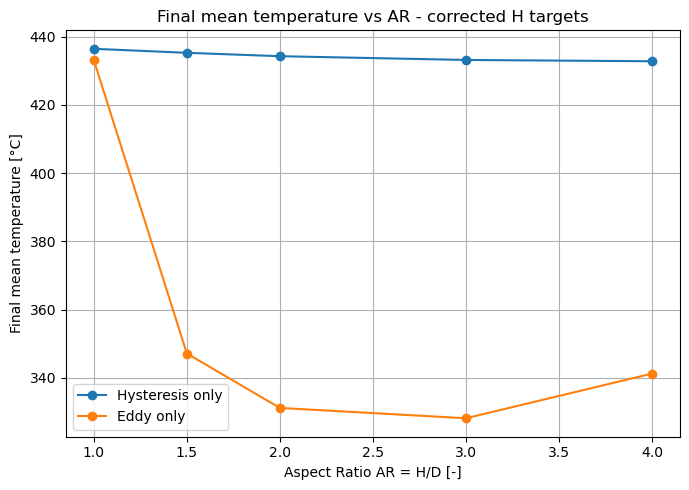

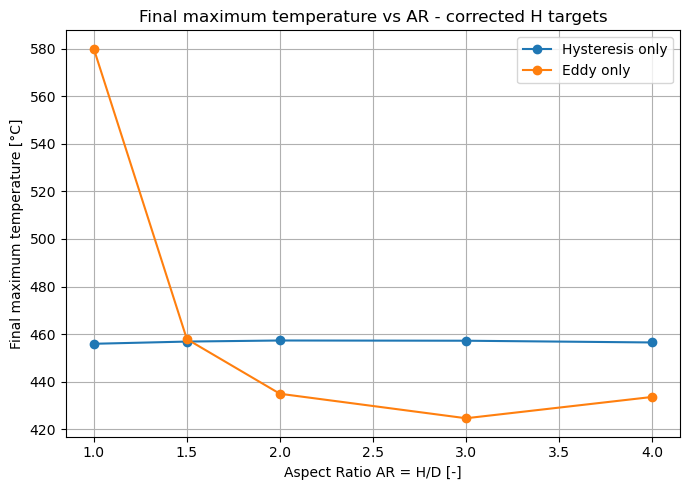

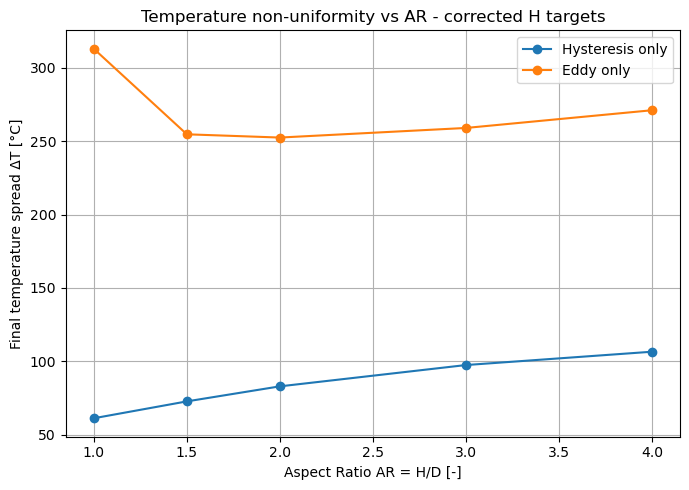

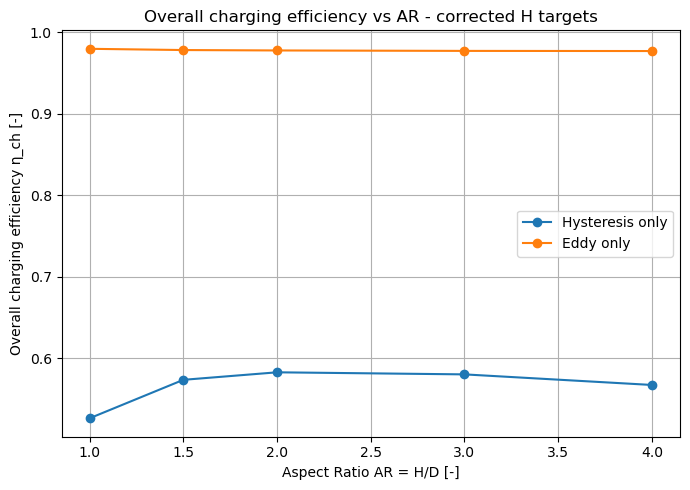

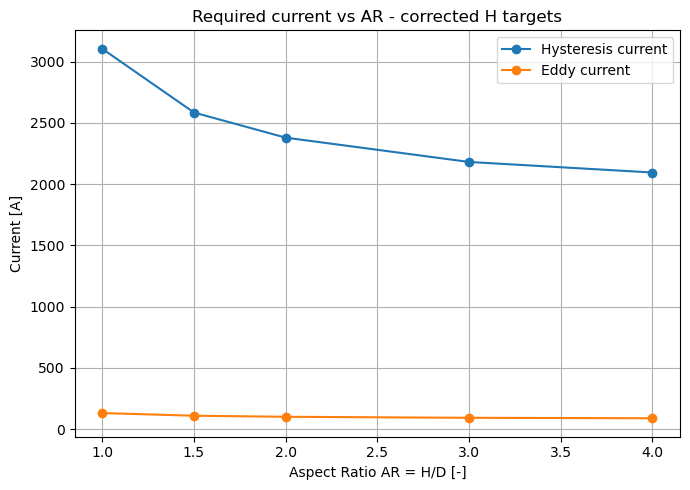

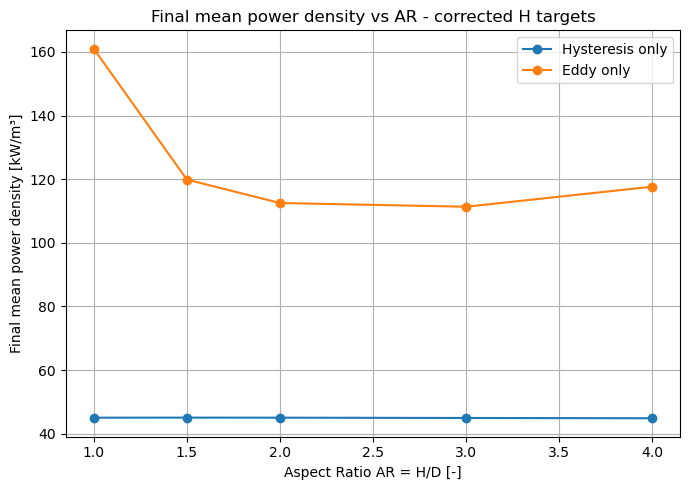

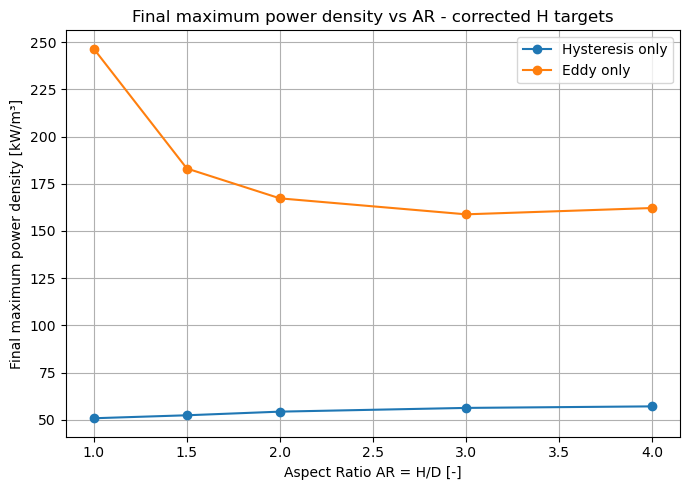

In [23]:
# ============================================================
# Final mean temperature vs AR
# ============================================================

plt.figure(figsize=(7,5))
plt.plot(df_AR_corrected["AR"], df_AR_corrected["T_mean_final_hys [°C]"], marker="o", label="Hysteresis only")
plt.plot(df_AR_corrected["AR"], df_AR_corrected["T_mean_final_eddy [°C]"], marker="o", label="Eddy only")
plt.xlabel("Aspect Ratio AR = H/D [-]")
plt.ylabel("Final mean temperature [°C]")
plt.title("Final mean temperature vs AR - corrected H targets")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# Final maximum temperature vs AR
# ============================================================

plt.figure(figsize=(7,5))
plt.plot(df_AR_corrected["AR"], df_AR_corrected["T_max_final_hys [°C]"], marker="o", label="Hysteresis only")
plt.plot(df_AR_corrected["AR"], df_AR_corrected["T_max_final_eddy [°C]"], marker="o", label="Eddy only")
plt.xlabel("Aspect Ratio AR = H/D [-]")
plt.ylabel("Final maximum temperature [°C]")
plt.title("Final maximum temperature vs AR - corrected H targets")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# Temperature spread vs AR
# ============================================================

plt.figure(figsize=(7,5))
plt.plot(df_AR_corrected["AR"], df_AR_corrected["DeltaT_final_hys [°C]"], marker="o", label="Hysteresis only")
plt.plot(df_AR_corrected["AR"], df_AR_corrected["DeltaT_final_eddy [°C]"], marker="o", label="Eddy only")
plt.xlabel("Aspect Ratio AR = H/D [-]")
plt.ylabel("Final temperature spread ΔT [°C]")
plt.title("Temperature non-uniformity vs AR - corrected H targets")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# Overall charging efficiency vs AR
# ============================================================

plt.figure(figsize=(7,5))
plt.plot(df_AR_corrected["AR"], df_AR_corrected["eta_ch_hys [-]"], marker="o", label="Hysteresis only")
plt.plot(df_AR_corrected["AR"], df_AR_corrected["eta_ch_eddy [-]"], marker="o", label="Eddy only")
plt.xlabel("Aspect Ratio AR = H/D [-]")
plt.ylabel("Overall charging efficiency η_ch [-]")
plt.title("Overall charging efficiency vs AR - corrected H targets")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# Required current vs AR
# ============================================================

plt.figure(figsize=(7,5))
plt.plot(df_AR_corrected["AR"], df_AR_corrected["I_hys [A]"], marker="o", label="Hysteresis current")
plt.plot(df_AR_corrected["AR"], df_AR_corrected["I_eddy [A]"], marker="o", label="Eddy current")
plt.xlabel("Aspect Ratio AR = H/D [-]")
plt.ylabel("Current [A]")
plt.title("Required current vs AR - corrected H targets")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# Mean power density vs AR
# ============================================================

plt.figure(figsize=(7,5))
plt.plot(df_AR_corrected["AR"], df_AR_corrected["q_mean_final_hys [kW/m3]"], marker="o", label="Hysteresis only")
plt.plot(df_AR_corrected["AR"], df_AR_corrected["q_mean_final_eddy [kW/m3]"], marker="o", label="Eddy only")
plt.xlabel("Aspect Ratio AR = H/D [-]")
plt.ylabel("Final mean power density [kW/m³]")
plt.title("Final mean power density vs AR - corrected H targets")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# Maximum power density vs AR
# ============================================================

plt.figure(figsize=(7,5))
plt.plot(df_AR_corrected["AR"], df_AR_corrected["q_max_final_hys [kW/m3]"], marker="o", label="Hysteresis only")
plt.plot(df_AR_corrected["AR"], df_AR_corrected["q_max_final_eddy [kW/m3]"], marker="o", label="Eddy only")
plt.xlabel("Aspect Ratio AR = H/D [-]")
plt.ylabel("Final maximum power density [kW/m³]")
plt.title("Final maximum power density vs AR - corrected H targets")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

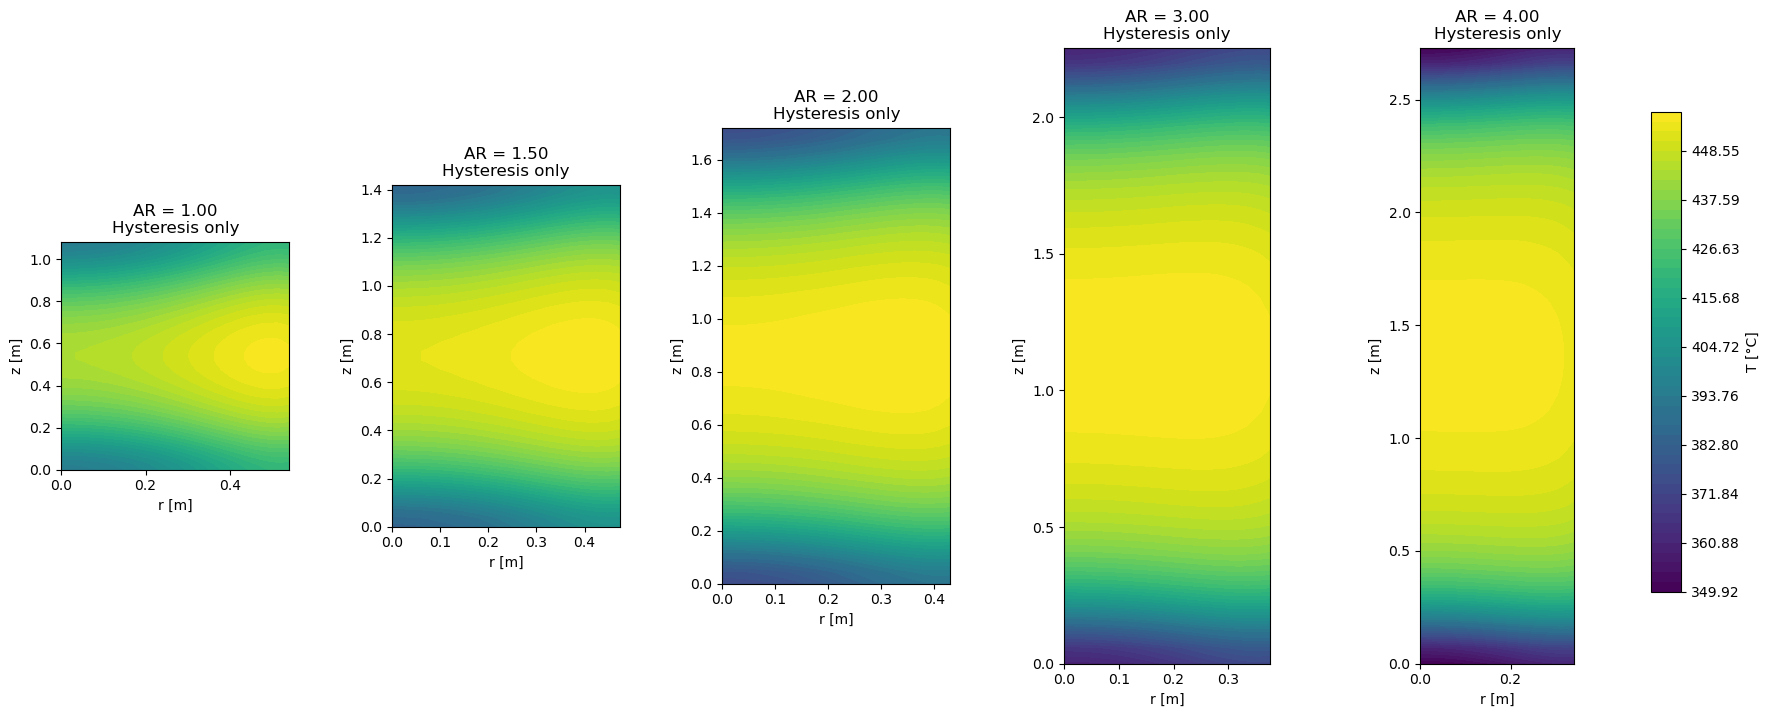

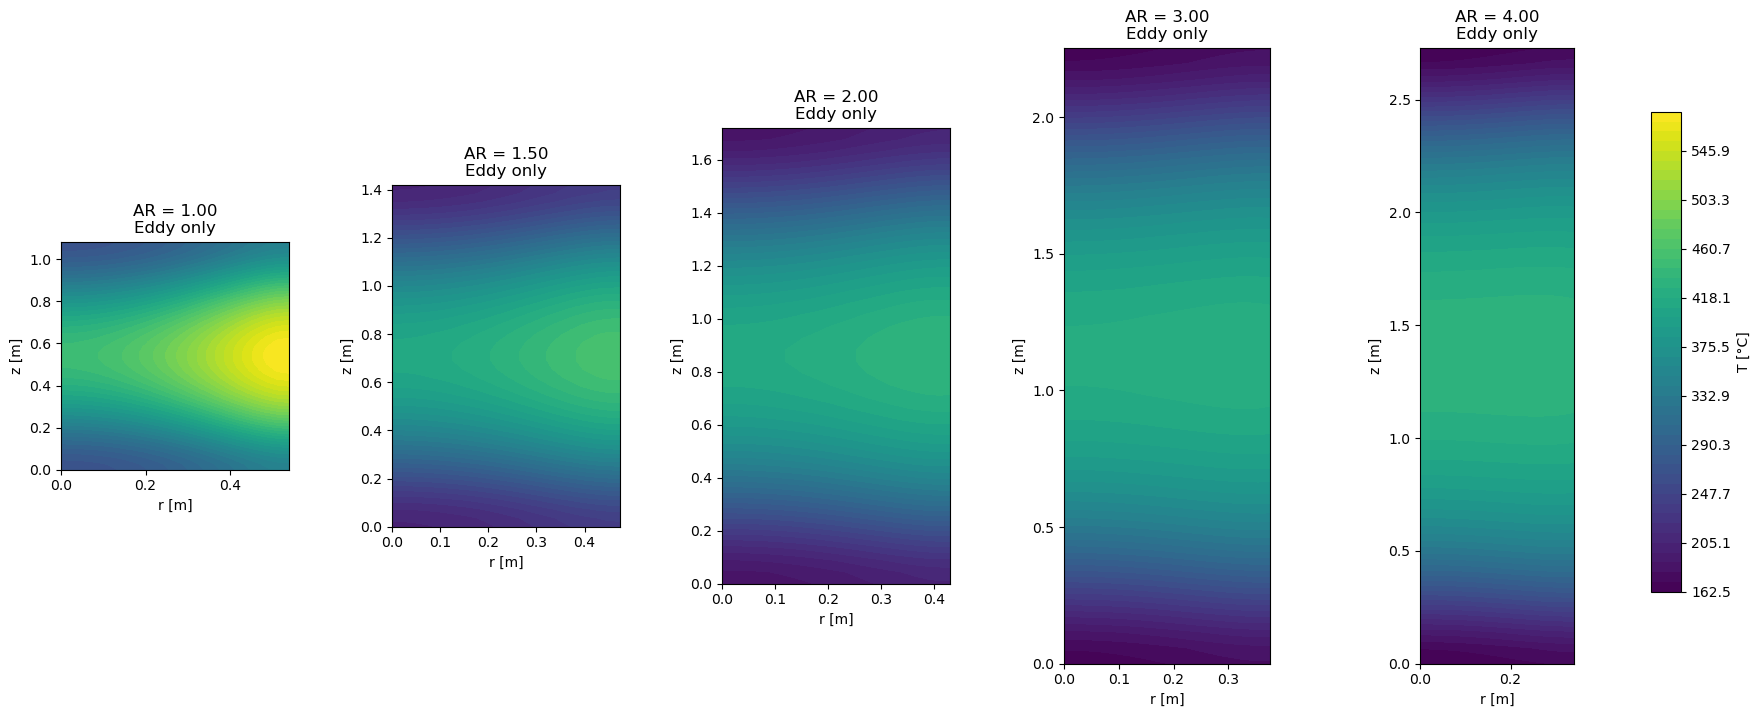

In [24]:
# ============================================================
# Temperature maps - HYSTERESIS ONLY
# ============================================================

Tmin_hys = min(np.min(m["T_final_hys"] - 273.15) for m in maps_AR_corrected)
Tmax_hys = max(np.max(m["T_final_hys"] - 273.15) for m in maps_AR_corrected)

levels_hys = np.linspace(Tmin_hys, Tmax_hys, 50)

n = len(maps_AR_corrected)
fig, axes = plt.subplots(1, n, figsize=(4*n, 8), sharey=False)

if n == 1:
    axes = [axes]

for ax, m in zip(axes, maps_AR_corrected):
    T_C = m["T_final_hys"] - 273.15

    cont = ax.contourf(
        m["r"],
        m["z"],
        T_C.T,
        levels=levels_hys,
        cmap="viridis"
    )

    ax.set_title(f"AR = {m['AR']:.2f}\nHysteresis only")
    ax.set_xlabel("r [m]")
    ax.set_ylabel("z [m]")
    ax.set_box_aspect(m["AR"])

fig.subplots_adjust(right=0.90, wspace=0.45)
cbar_ax = fig.add_axes([0.92, 0.20, 0.015, 0.60])
cbar = fig.colorbar(cont, cax=cbar_ax)
cbar.set_label("T [°C]")

plt.show()


# ============================================================
# Temperature maps - EDDY ONLY
# ============================================================

Tmin_eddy = min(np.min(m["T_final_eddy"] - 273.15) for m in maps_AR_corrected)
Tmax_eddy = max(np.max(m["T_final_eddy"] - 273.15) for m in maps_AR_corrected)

levels_eddy = np.linspace(Tmin_eddy, Tmax_eddy, 50)

n = len(maps_AR_corrected)
fig, axes = plt.subplots(1, n, figsize=(4*n, 8), sharey=False)

if n == 1:
    axes = [axes]

for ax, m in zip(axes, maps_AR_corrected):
    T_C = m["T_final_eddy"] - 273.15

    cont = ax.contourf(
        m["r"],
        m["z"],
        T_C.T,
        levels=levels_eddy,
        cmap="viridis"
    )

    ax.set_title(f"AR = {m['AR']:.2f}\nEddy only")
    ax.set_xlabel("r [m]")
    ax.set_ylabel("z [m]")
    ax.set_box_aspect(m["AR"])

fig.subplots_adjust(right=0.90, wspace=0.45)
cbar_ax = fig.add_axes([0.92, 0.20, 0.015, 0.60])
cbar = fig.colorbar(cont, cax=cbar_ax)
cbar.set_label("T [°C]")

plt.show()

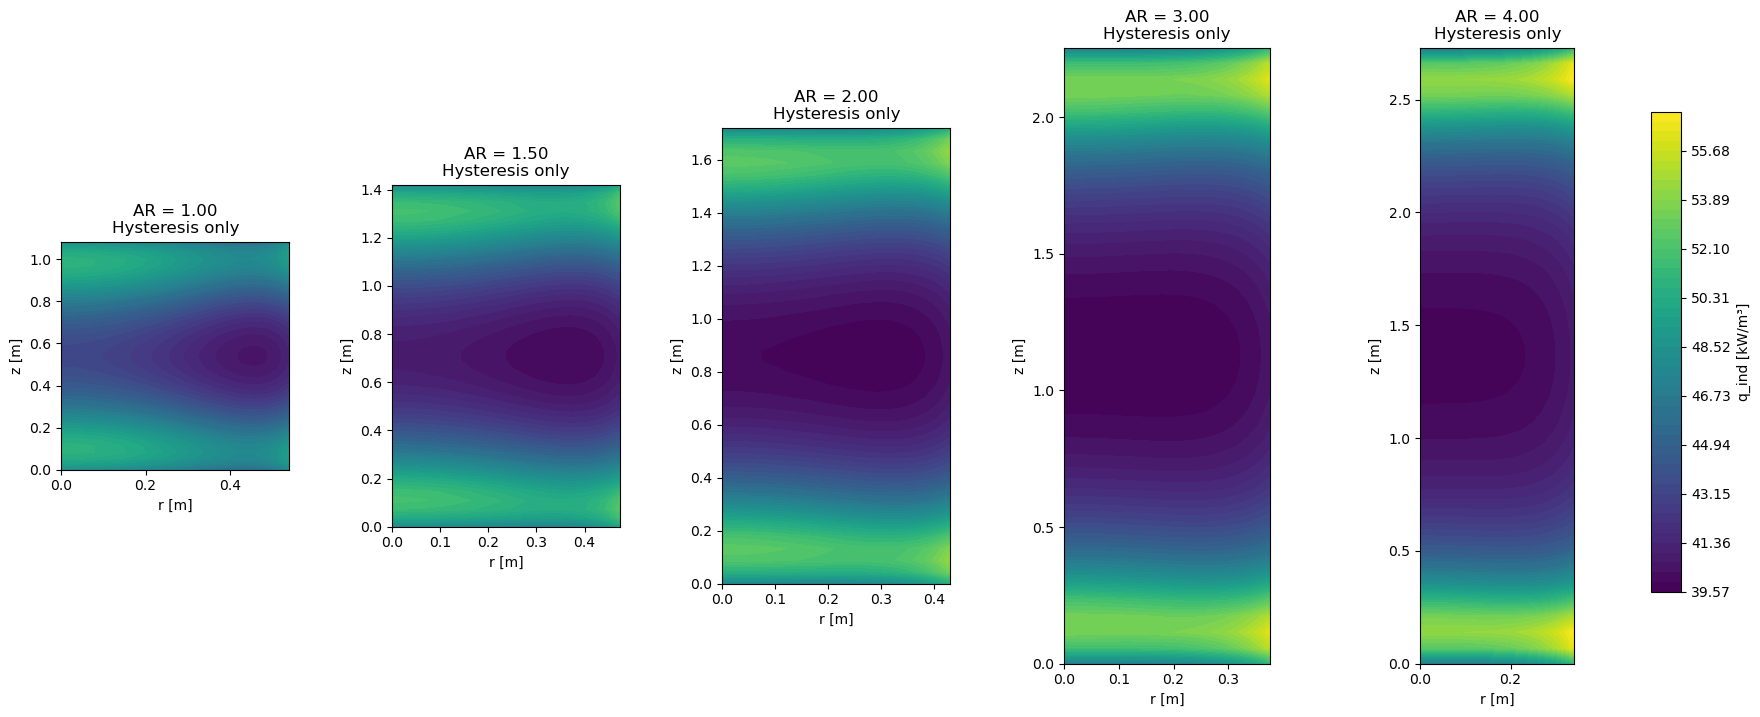

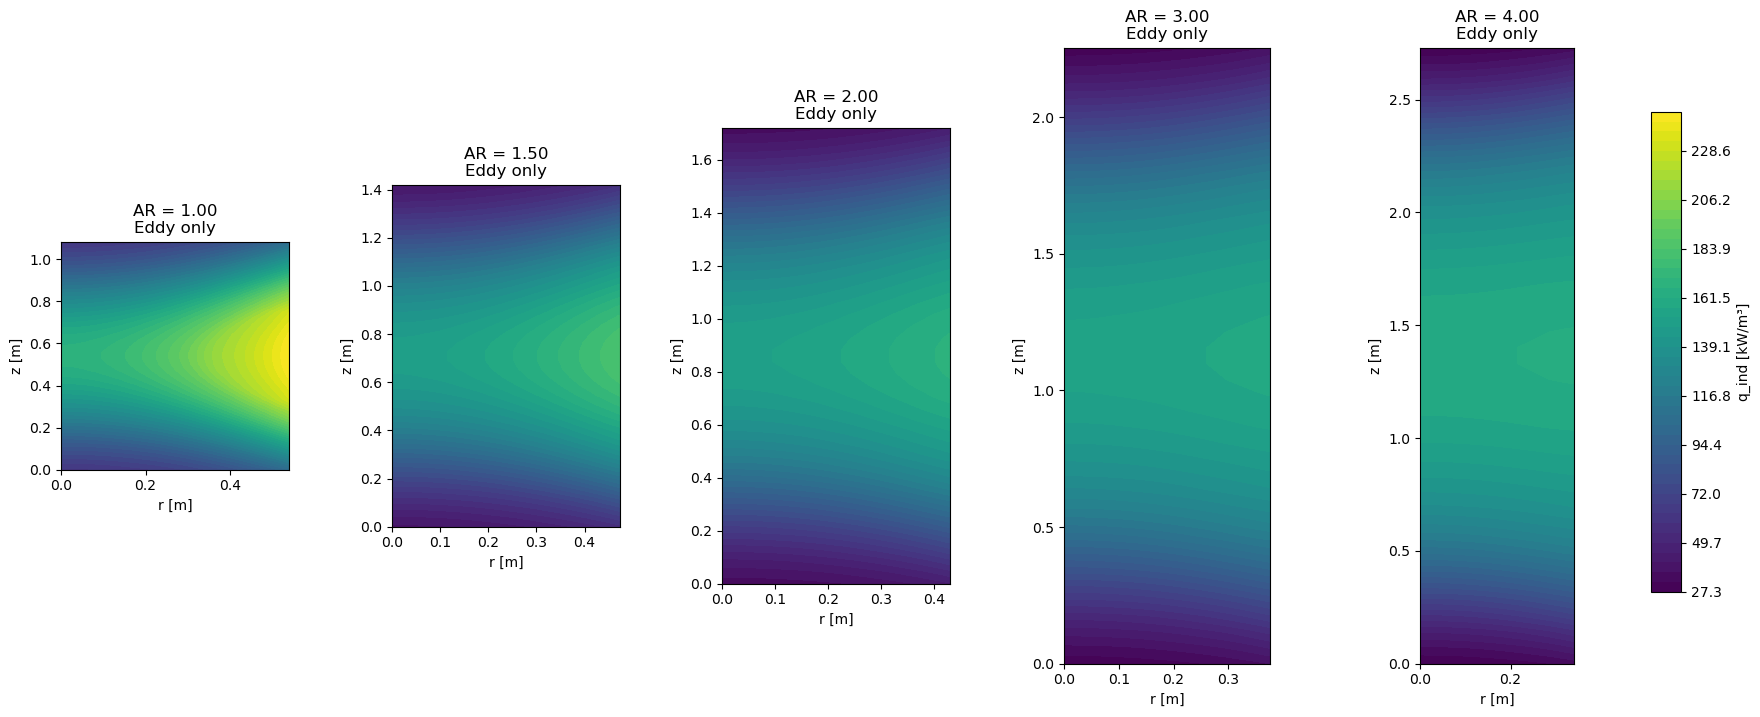

In [25]:
# ============================================================
# Power density maps - HYSTERESIS ONLY
# ============================================================

qmin_hys = min(np.min(m["q_src_hys"] / 1000) for m in maps_AR_corrected)
qmax_hys = max(np.max(m["q_src_hys"] / 1000) for m in maps_AR_corrected)

levels_q_hys = np.linspace(qmin_hys, qmax_hys, 50)

n = len(maps_AR_corrected)
fig, axes = plt.subplots(1, n, figsize=(4*n, 8), sharey=False)

if n == 1:
    axes = [axes]

for ax, m in zip(axes, maps_AR_corrected):
    q_map = m["q_src_hys"] / 1000

    cont = ax.contourf(
        m["r"],
        m["z"],
        q_map.T,
        levels=levels_q_hys,
        cmap="viridis"
    )

    ax.set_title(f"AR = {m['AR']:.2f}\nHysteresis only")
    ax.set_xlabel("r [m]")
    ax.set_ylabel("z [m]")
    ax.set_box_aspect(m["AR"])

fig.subplots_adjust(right=0.90, wspace=0.45)
cbar_ax = fig.add_axes([0.92, 0.20, 0.015, 0.60])
cbar = fig.colorbar(cont, cax=cbar_ax)
cbar.set_label("q_ind [kW/m³]")

plt.show()


# ============================================================
# Power density maps - EDDY ONLY
# ============================================================

qmin_eddy = min(np.min(m["q_src_eddy"] / 1000) for m in maps_AR_corrected)
qmax_eddy = max(np.max(m["q_src_eddy"] / 1000) for m in maps_AR_corrected)

levels_q_eddy = np.linspace(qmin_eddy, qmax_eddy, 50)

n = len(maps_AR_corrected)
fig, axes = plt.subplots(1, n, figsize=(4*n, 8), sharey=False)

if n == 1:
    axes = [axes]

for ax, m in zip(axes, maps_AR_corrected):
    q_map = m["q_src_eddy"] / 1000

    cont = ax.contourf(
        m["r"],
        m["z"],
        q_map.T,
        levels=levels_q_eddy,
        cmap="viridis"
    )

    ax.set_title(f"AR = {m['AR']:.2f}\nEddy only")
    ax.set_xlabel("r [m]")
    ax.set_ylabel("z [m]")
    ax.set_box_aspect(m["AR"])

fig.subplots_adjust(right=0.90, wspace=0.45)
cbar_ax = fig.add_axes([0.92, 0.20, 0.015, 0.60])
cbar = fig.colorbar(cont, cax=cbar_ax)
cbar.set_label("q_ind [kW/m³]")

plt.show()

In [1]:
#SIMULAZIONE DISCHARGING

In [16]:
# ============================================================
# IMPORT AND RELOAD CORRECTED DISCHARGING MODEL
# ============================================================

import os
import sys
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Cartella dove hai i file .py
CODE_DIR = r"C:\Users\lolle\OneDrive\Desktop\TESI_MAGISTRALE\codice"

if CODE_DIR not in sys.path:
    sys.path.append(CODE_DIR)

# Import della classe principale del charging
from class_IHTES_2D_Tdep import IHTES2D_Tdep

# Import del modello discharging corretto
import discharging_model
importlib.reload(discharging_model)

from discharging_model import attach_discharging_model, h_air, T_from_h_air

# Attacco la funzione di discharging alla classe IHTES2D_Tdep
attach_discharging_model(IHTES2D_Tdep)

print("Corrected discharging model loaded.")

Discharging model attached to IHTES2D_Tdep.
Corrected discharging model loaded.


In [18]:
# ============================================================
# CREATE TES2D OBJECT IF IT DOES NOT EXIST
# ============================================================

# Controllo che le variabili base del charging esistano
base_vars = ["TH_mag", "EM_mag", "HYS_mag", "geom_1"]

missing_base = [v for v in base_vars if v not in globals()]

if missing_base:
    raise NameError(
        "Missing variables from the charging setup: "
        + ", ".join(missing_base)
        + "\nRun the previous charging/setup cells before this one."
    )

# Creo l'oggetto tes2d
tes2d = IHTES2D_Tdep(
    TH_mag,
    EM_mag,
    HYS_mag,
    geom_1,
    mesh=(20, 40)
)

print("tes2d object created.")
print("Full PB length [cm] =", tes2d.H_TES * 100)
print("Half PB length [cm] =", tes2d.H_TES * 100 / 2)

tes2d object created.
Full PB length [cm] = 172.0
Half PB length [cm] = 86.0


In [20]:
# ============================================================
# RECREATE FINAL CHARGING MAPS FOR DISCHARGING INITIAL CONDITION
# ============================================================

T_init = 293.15
T_amb = 293.15

ch_time = 3 * 3600   # 3 hours
dt_ch = 10.0

# ------------------------------------------------------------
# HYSTERESIS-ONLY CHARGING
# ------------------------------------------------------------

freq_hys = 80.0
I_hys = 2203.0

(
    time_hys,
    T_mean_hys,
    T_max_hys,
    T_final_hys,
    snapshot_times_hys,
    snapshots_hys,
    q_src_hys,
    h_eq_hys,
    q_mean_hys,
    q_max_hys,
) = tes2d.charging_2D_nonuniform_Tdep(
    freq=freq_hys,
    I=I_hys,
    T_init=T_init,
    T_amb=T_amb,
    ch_time=ch_time,
    dt=dt_ch,
    save_every=30,
    source_mode="hys_only",
)

print("Hysteresis-only charging completed.")
print("T_mean_final_hys [°C] =", T_mean_hys[-1] - 273.15)
print("T_max_final_hys  [°C] =", T_max_hys[-1] - 273.15)


# ------------------------------------------------------------
# EDDY-ONLY CHARGING
# ------------------------------------------------------------

freq_eddy = 50_000.0
I_eddy = 100.0

(
    time_eddy,
    T_mean_eddy,
    T_max_eddy,
    T_final_eddy,
    snapshot_times_eddy,
    snapshots_eddy,
    q_src_eddy,
    h_eq_eddy,
    q_mean_eddy,
    q_max_eddy,
) = tes2d.charging_2D_nonuniform_Tdep(
    freq=freq_eddy,
    I=I_eddy,
    T_init=T_init,
    T_amb=T_amb,
    ch_time=ch_time,
    dt=dt_ch,
    save_every=30,
    source_mode="eddy_only",
)

print("Eddy-only charging completed.")
print("T_mean_final_eddy [°C] =", T_mean_eddy[-1] - 273.15)
print("T_max_final_eddy  [°C] =", T_max_eddy[-1] - 273.15)

Hysteresis-only charging completed.
T_mean_final_hys [°C] = 417.9179580196318
T_max_final_hys  [°C] = 446.4467967719079
Eddy-only charging completed.
T_mean_final_eddy [°C] = 331.1310857218002
T_max_final_eddy  [°C] = 434.9291855294463


In [21]:
# ============================================================
# CHECK REQUIRED VARIABLES FROM CHARGING
# ============================================================

required_vars = ["tes2d", "T_final_hys", "T_final_eddy"]

for var in required_vars:
    if var not in globals():
        raise NameError(
            f"Missing variable: {var}. "
            "You must run the charging cells before starting the discharge simulation."
        )

T_TARGET_C = 300.0
T_TARGET_K = T_TARGET_C + 273.15

print("All required charging variables are available.")
print("Full PB length [cm] =", tes2d.H_TES * 100)
print("Half PB length [cm] =", tes2d.H_TES * 100 / 2)

All required charging variables are available.
Full PB length [cm] = 172.0
Half PB length [cm] = 86.0


In [ ]:
#SIMULAZIONE 30 MINUTI DI SCARICA CON 3 PORTATE DIVERSE NEL CASO HYSTERESYS CONSIDERANDO a quale z arriviamo all'inizio della simulazione a 300 gradi e a quale z arriviamo per raggiungere i 300 gradi dopo 30 minuit di simulazione 

In [23]:
# ============================================================
# QUICK CHECK - HYSTERESIS CASE
# Does z_300 depend on mass flow rate now?
# ============================================================

quick_mdot_list = [0.20, 1.00, 4.00]

quick_results_hys = {}

for m_dot in quick_mdot_list:

    print("\n======================================")
    print(f"Quick HYSTERESIS test, m_dot_total = {m_dot:.2f} kg/s")
    print("======================================")

    res = tes2d.discharging_2D_air_final(
        T_s_init_full=T_final_hys,
        m_dot_total=m_dot,
        T_air_in=293.15,
        T_amb=293.15,
        T_target=T_TARGET_K,
        dis_time=30 * 60,      # 30 minutes
        dt=5.0,
        d_p=0.02,
        half_method="average_two_ends",
        save_every=60,
        verbose=True,
    )

    quick_results_hys[m_dot] = res

    print("T_out max [°C] =", np.max(res["T_out"] - 273.15))
    print("T_out final [°C] =", res["T_out"][-1] - 273.15)
    print("P_rec max [kW] =", np.max(res["P_rec"]) / 1000)
    print("P_rec final [kW] =", res["P_rec"][-1] / 1000)

    if np.all(np.isnan(res["z_target_cm"])):
        print("z_300: target not reached")
    else:
        print("z_300 min [cm] =", np.nanmin(res["z_target_cm"]))
        print("z_300 final [cm] =", res["z_target_cm"][-1])


Quick HYSTERESIS test, m_dot_total = 0.20 kg/s
========== DISCHARGE SETUP ==========
H_full  = 1.720 m = 172.0 cm
H_half  = 0.860 m = 86.0 cm
Nz_half = 20
dz_half = 0.0430 m = 4.30 cm
m_dot_total = 0.2000 kg/s
m_dot_half  = 0.1000 kg/s
G = 0.1722 kg/m2/s
u_D_ref     = 0.1429 m/s
u_int_ref   = 0.3573 m/s
Air is marched cell-by-cell along z using local NTU.
T_out max [°C] = 445.76691922605653
T_out final [°C] = 443.051279672232
P_rec max [kW] = 88.13782817898826
P_rec final [kW] = 87.55168800527807
z_300 min [cm] = 5.574746464361592
z_300 final [cm] = 22.990886340071675

Quick HYSTERESIS test, m_dot_total = 1.00 kg/s
========== DISCHARGE SETUP ==========
H_full  = 1.720 m = 172.0 cm
H_half  = 0.860 m = 86.0 cm
Nz_half = 20
dz_half = 0.0430 m = 4.30 cm
m_dot_total = 1.0000 kg/s
m_dot_half  = 0.5000 kg/s
G = 0.8608 kg/m2/s
u_D_ref     = 0.7146 m/s
u_int_ref   = 1.7864 m/s
Air is marched cell-by-cell along z using local NTU.
T_out max [°C] = 445.181863733476
T_out final [°C] = 301.44854413

In [ ]:
#commenti:
#0.20 kg/s → aria si scalda bene, arriva a 300 °C dopo circa 23 cm a 30 min
#1.00 kg/s → aria si scalda meno, arriva a 300 °C quasi all’uscita a 30 min
#4.00 kg/s → portata troppo alta, dopo 30 min non raggiunge più 300 °C

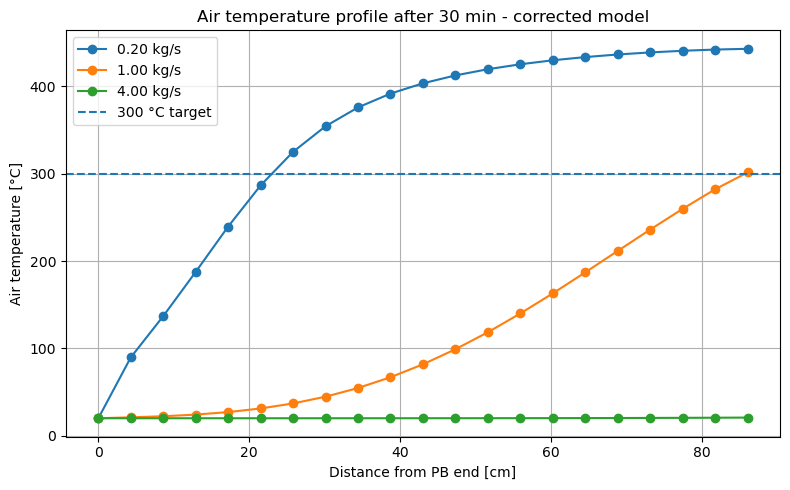

In [24]:
# ============================================================
# QUICK AIR PROFILE COMPARISON AFTER 30 MIN
# ============================================================

plt.figure(figsize=(8, 5))

for m_dot in quick_mdot_list:
    res = quick_results_hys[m_dot]

    Tf_edges = res["snapshots_Tf_edges"][-1]

    h_edges = h_air(Tf_edges)
    h_profile_edges = tes2d._area_average_profile_z(h_edges)
    T_profile_edges = T_from_h_air(h_profile_edges) - 273.15

    plt.plot(
        res["z_edges"] * 100,
        T_profile_edges,
        marker="o",
        label=f"{m_dot:.2f} kg/s"
    )

plt.axhline(T_TARGET_C, linestyle="--", label="300 °C target")
plt.xlabel("Distance from PB end [cm]")
plt.ylabel("Air temperature [°C]")
plt.title("Air temperature profile after 30 min - corrected model")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#altre simulazioni (DOPO 2 ORE DI SCARICA) con diversi valori di portata per entrambi i casi 

In [25]:
# ============================================================
# MASS FLOW RATE SWEEP - CORRECTED MODEL
# Hysteresis-only initial map vs Eddy-only initial map
# ============================================================

m_dot_list = np.array([0.20, 0.50, 1.00, 1.50, 2.00, 3.00, 4.00])

dis_time = 2 * 3600
dt_dis = 5.0

results_corrected = {
    "hys": {},
    "eddy": {},
}

for m_dot in m_dot_list:

    print("\n======================================")
    print(f"Running CORRECTED HYSTERESIS discharge, m_dot_total = {m_dot:.2f} kg/s")
    print("======================================")

    res = tes2d.discharging_2D_air_final(
        T_s_init_full=T_final_hys,
        m_dot_total=m_dot,
        T_air_in=293.15,
        T_amb=293.15,
        T_target=T_TARGET_K,
        dis_time=dis_time,
        dt=dt_dis,
        d_p=0.02,
        half_method="average_two_ends",
        save_every=120,
        verbose=False,
    )

    results_corrected["hys"][m_dot] = res

    print("T_out max [°C] =", np.max(res["T_out"] - 273.15))
    print("T_out final [°C] =", res["T_out"][-1] - 273.15)
    print("P_rec max [kW] =", np.max(res["P_rec"]) / 1000)
    print("P_rec final [kW] =", res["P_rec"][-1] / 1000)
    print("E_rec final [kWh] =", res["E_rec"][-1] / 3.6e6)

    if np.all(np.isnan(res["z_target_cm"])):
        print("z_300: target not reached")
    else:
        print("z_300 final [cm] =", res["z_target_cm"][-1])


for m_dot in m_dot_list:

    print("\n======================================")
    print(f"Running CORRECTED EDDY discharge, m_dot_total = {m_dot:.2f} kg/s")
    print("======================================")

    res = tes2d.discharging_2D_air_final(
        T_s_init_full=T_final_eddy,
        m_dot_total=m_dot,
        T_air_in=293.15,
        T_amb=293.15,
        T_target=T_TARGET_K,
        dis_time=dis_time,
        dt=dt_dis,
        d_p=0.02,
        half_method="average_two_ends",
        save_every=120,
        verbose=False,
    )

    results_corrected["eddy"][m_dot] = res

    print("T_out max [°C] =", np.max(res["T_out"] - 273.15))
    print("T_out final [°C] =", res["T_out"][-1] - 273.15)
    print("P_rec max [kW] =", np.max(res["P_rec"]) / 1000)
    print("P_rec final [kW] =", res["P_rec"][-1] / 1000)
    print("E_rec final [kWh] =", res["E_rec"][-1] / 3.6e6)

    if np.all(np.isnan(res["z_target_cm"])):
        print("z_300: target not reached")
    else:
        print("z_300 final [cm] =", res["z_target_cm"][-1])

print("\nCorrected sweep completed.")


Running CORRECTED HYSTERESIS discharge, m_dot_total = 0.20 kg/s
T_out max [°C] = 445.76691922605653
T_out final [°C] = 391.16533084334344
P_rec max [kW] = 88.13782817898826
P_rec final [kW] = 76.42082956442216
E_rec final [kWh] = 170.09736251876828
z_300 final [cm] = 65.53892577829433

Running CORRECTED HYSTERESIS discharge, m_dot_total = 0.50 kg/s
T_out max [°C] = 445.5676423458726
T_out final [°C] = 43.169559203167466
P_rec max [kW] = 220.23701099068515
P_rec final [kW] = 11.660922957343836
E_rec final [kWh] = 266.8603544719989
z_300 final [cm] = nan

Running CORRECTED HYSTERESIS discharge, m_dot_total = 1.00 kg/s
T_out max [°C] = 445.181863733476
T_out final [°C] = 20.05457046424891
P_rec max [kW] = 440.0576038735433
P_rec final [kW] = 0.054905691572348585
E_rec final [kWh] = 269.63866913090544
z_300 final [cm] = nan

Running CORRECTED HYSTERESIS discharge, m_dot_total = 1.50 kg/s
T_out max [°C] = 444.7501287631684
T_out final [°C] = 20.00017927665658
P_rec max [kW] = 659.387430435

In [26]:
# ============================================================
# SUMMARY TABLE - CORRECTED DISCHARGE SWEEP
# ============================================================

def value_at_time(time_array, y_array, target_time_s):
    idx = np.argmin(np.abs(time_array - target_time_s))
    return y_array[idx]


def summarize_corrected_case(case_name, m_dot, res):
    time = res["time"]

    T_out_C = res["T_out"] - 273.15
    P_kW = res["P_rec"] / 1000
    E_kWh = res["E_rec"] / 3.6e6
    z_cm = res["z_target_cm"]

    mask_30 = time <= 30 * 60
    mask_60 = time <= 60 * 60
    mask_120 = time <= 120 * 60

    return {
        "case": case_name,
        "m_dot_total [kg/s]": m_dot,

        "T_out_max [°C]": np.max(T_out_C),
        "T_out_30min [°C]": value_at_time(time, T_out_C, 30 * 60),
        "T_out_60min [°C]": value_at_time(time, T_out_C, 60 * 60),
        "T_out_120min [°C]": value_at_time(time, T_out_C, 120 * 60),

        "P_rec_max [kW]": np.max(P_kW),
        "P_rec_30min [kW]": value_at_time(time, P_kW, 30 * 60),
        "P_rec_60min [kW]": value_at_time(time, P_kW, 60 * 60),
        "P_rec_120min [kW]": value_at_time(time, P_kW, 120 * 60),

        "P_mean_30min [kW]": np.mean(P_kW[mask_30]),
        "P_mean_60min [kW]": np.mean(P_kW[mask_60]),
        "P_mean_120min [kW]": np.mean(P_kW[mask_120]),

        "E_rec_30min [kWh]": value_at_time(time, E_kWh, 30 * 60),
        "E_rec_60min [kWh]": value_at_time(time, E_kWh, 60 * 60),
        "E_rec_120min [kWh]": value_at_time(time, E_kWh, 120 * 60),

        "z_300_30min [cm]": value_at_time(time, z_cm, 30 * 60),
        "z_300_60min [cm]": value_at_time(time, z_cm, 60 * 60),
        "z_300_120min [cm]": value_at_time(time, z_cm, 120 * 60),
    }


summary_rows = []

for case_name in ["hys", "eddy"]:
    for m_dot in m_dot_list:
        summary_rows.append(
            summarize_corrected_case(
                case_name,
                m_dot,
                results_corrected[case_name][m_dot]
            )
        )

df_discharge_corrected = pd.DataFrame(summary_rows)

df_discharge_corrected

,case,m_dot_total [kg/s],T_out_max [°C],T_out_30min [°C],T_out_60min [°C],T_out_120min [°C],P_rec_max [kW],P_rec_30min [kW],P_rec_60min [kW],P_rec_120min [kW],P_mean_30min [kW],P_mean_60min [kW],P_mean_120min [kW],E_rec_30min [kWh],E_rec_60min [kWh],E_rec_120min [kWh],z_300_30min [cm],z_300_60min [cm],z_300_120min [cm]
0,hys,0.2,445.766919,443.051280,437.015837,391.165331,88.137828,87.551688,86.250274,7.642083e+01,87.645018,87.312759,84.989661,43.944238,87.434026,170.097363,22.990886,37.692641,65.538926
1,hys,0.5,445.567642,427.431305,316.197057,43.169559,220.237011,210.467938,151.412569,1.166092e+01,216.426953,201.820873,133.337582,108.514070,202.101180,266.860354,47.701615,82.423836,NaN
2,hys,1.0,445.181864,301.448544,52.412248,20.054570,440.057604,287.382091,32.632134,5.490569e-02,393.074801,263.859948,134.725775,197.083337,264.226421,269.638669,85.676858,NaN,NaN
3,hys,1.5,444.750129,144.827436,22.538844,20.000179,659.387430,189.151168,3.831816,2.705669e-04,484.834864,268.735501,134.674060,243.090814,269.108745,269.535166,NaN,NaN,NaN
4,hys,2.0,444.268974,65.245307,20.221067,20.000001,878.144698,91.134563,0.444852,1.639429e-06,519.463345,269.109417,134.666793,260.453150,269.483180,269.520623,NaN,NaN,NaN
5,hys,3.0,443.160996,25.607382,20.002106,20.000000,1313.630428,16.927025,0.006358,1.093140e-10,535.363229,269.189430,134.688302,268.425174,269.563304,269.563672,NaN,NaN,NaN
6,hys,4.0,441.897365,20.767501,20.000026,20.000000,1746.054714,3.088901,0.000104,9.546056e-12,537.454771,269.257862,134.722361,269.473851,269.631832,269.631836,NaN,NaN,NaN
7,eddy,0.2,428.333588,412.795363,383.815495,278.260921,84.381206,81.045277,74.854567,5.264008e+01,82.710117,80.452995,72.674397,41.469934,80.564735,145.449731,47.726965,61.118374,NaN
8,eddy,0.5,427.017444,358.654593,204.448854,31.287529,210.245475,173.780665,93.483300,5.679517e+00,195.237642,165.683011,100.408675,97.889985,165.913126,200.956806,70.409191,NaN,NaN
9,eddy,1.0,424.670817,202.398233,36.251291,20.027194,417.968960,184.863554,16.355781,2.736137e-02,322.534531,199.696811,101.277762,161.715230,199.974168,202.696188,NaN,NaN,NaN


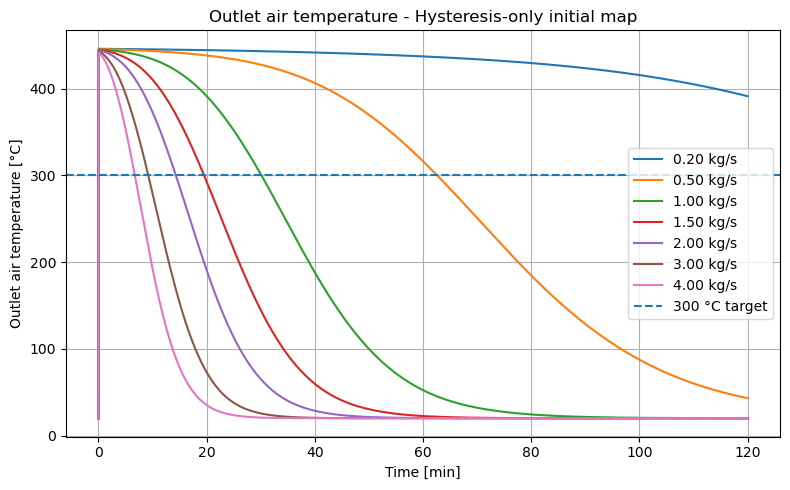

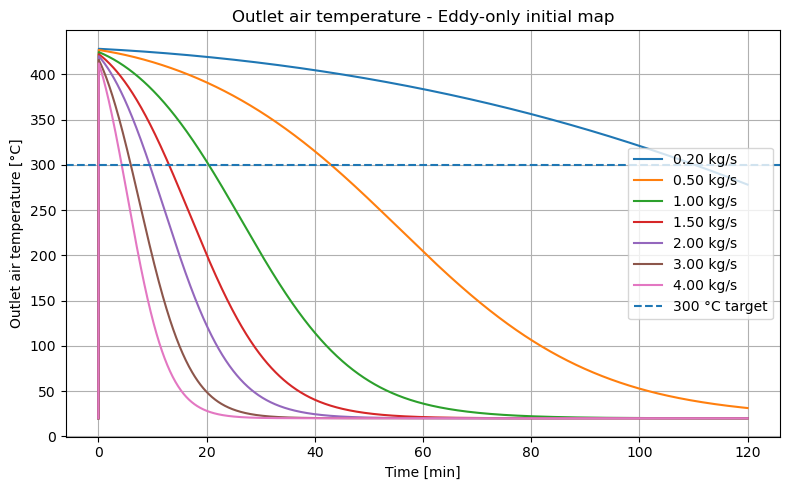

In [27]:
# ============================================================
# OUTLET TEMPERATURE VS TIME - CORRECTED MODEL
# ============================================================

for case_name, title in [
    ("hys", "Hysteresis-only initial map"),
    ("eddy", "Eddy-only initial map"),
]:

    plt.figure(figsize=(8, 5))

    for m_dot in m_dot_list:
        res = results_corrected[case_name][m_dot]

        plt.plot(
            res["time"] / 60,
            res["T_out"] - 273.15,
            label=f"{m_dot:.2f} kg/s"
        )

    plt.axhline(300, linestyle="--", label="300 °C target")
    plt.xlabel("Time [min]")
    plt.ylabel("Outlet air temperature [°C]")
    plt.title(f"Outlet air temperature - {title}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

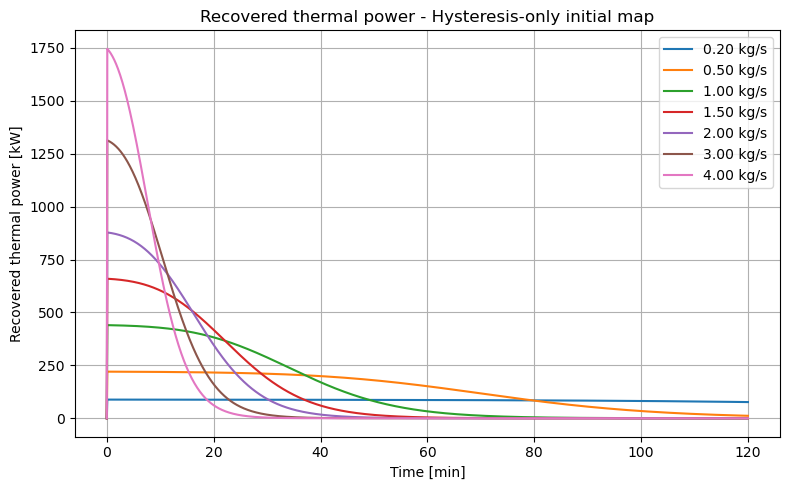

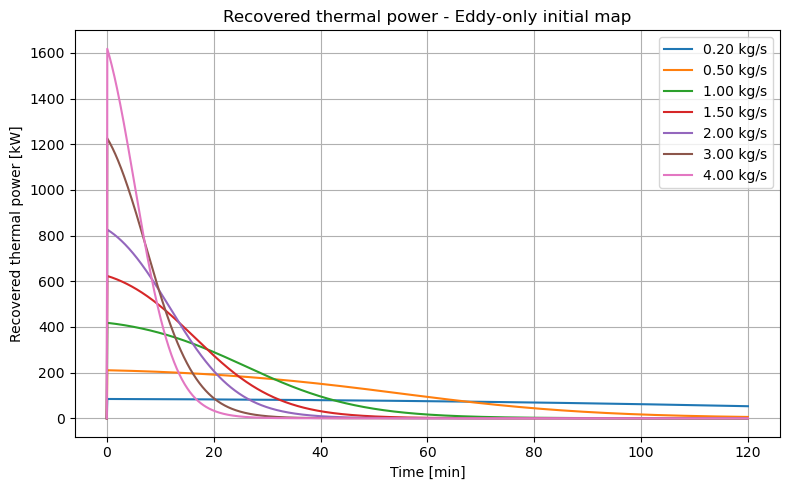

In [28]:
# ============================================================
# RECOVERED POWER VS TIME - CORRECTED MODEL
# ============================================================

for case_name, title in [
    ("hys", "Hysteresis-only initial map"),
    ("eddy", "Eddy-only initial map"),
]:

    plt.figure(figsize=(8, 5))

    for m_dot in m_dot_list:
        res = results_corrected[case_name][m_dot]

        plt.plot(
            res["time"] / 60,
            res["P_rec"] / 1000,
            label=f"{m_dot:.2f} kg/s"
        )

    plt.xlabel("Time [min]")
    plt.ylabel("Recovered thermal power [kW]")
    plt.title(f"Recovered thermal power - {title}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

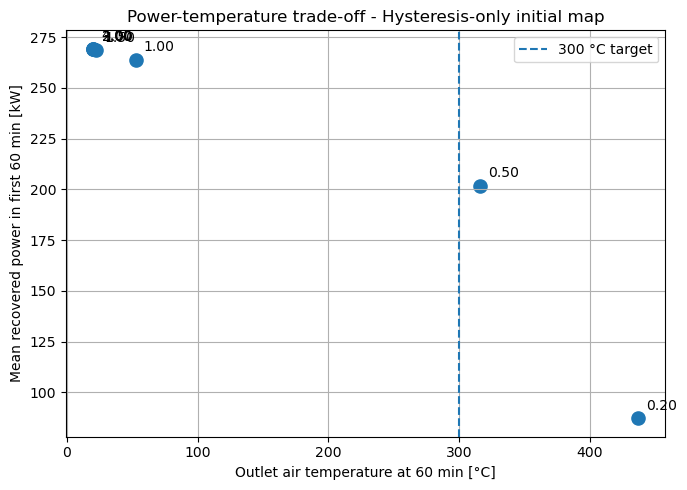

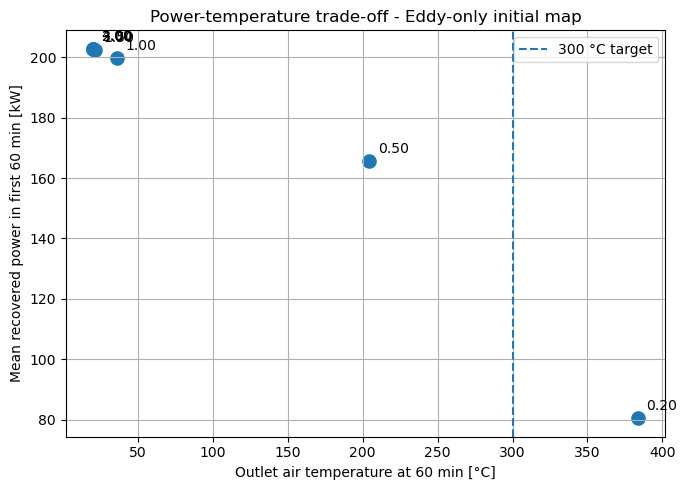

In [29]:
# ============================================================
# INDUSTRIAL TRADE-OFF:
# Mean recovered power vs outlet temperature after 60 min
# ============================================================

for case_name, title in [
    ("hys", "Hysteresis-only initial map"),
    ("eddy", "Eddy-only initial map"),
]:

    df_case = df_discharge_corrected[
        df_discharge_corrected["case"] == case_name
    ]

    plt.figure(figsize=(7, 5))

    plt.scatter(
        df_case["T_out_60min [°C]"],
        df_case["P_mean_60min [kW]"],
        s=90
    )

    for _, row in df_case.iterrows():
        plt.annotate(
            f"{row['m_dot_total [kg/s]']:.2f}",
            (
                row["T_out_60min [°C]"],
                row["P_mean_60min [kW]"]
            ),
            textcoords="offset points",
            xytext=(6, 6)
        )

    plt.axvline(300, linestyle="--", label="300 °C target")
    plt.xlabel("Outlet air temperature at 60 min [°C]")
    plt.ylabel("Mean recovered power in first 60 min [kW]")
    plt.title(f"Power-temperature trade-off - {title}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
#SIMULAZIONE CICLI CON SAME ENERGY INPUT

In [ ]:
#CASO CICLO UNICO

In [7]:
# ============================================================
# SAME ENERGY INPUT CYCLES - IMPORT
# ============================================================

import os
import sys
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CODE_DIR = r"C:\Users\lolle\OneDrive\Desktop\TESI_MAGISTRALE\codice"

if CODE_DIR not in sys.path:
    sys.path.append(CODE_DIR)

import class_IHTES
import class_IHTES_2D_Tdep
import discharging_model
import cycles_same_energy_input

importlib.reload(class_IHTES)
importlib.reload(class_IHTES_2D_Tdep)
importlib.reload(discharging_model)
importlib.reload(cycles_same_energy_input)

from class_IHTES_2D_Tdep import IHTES2D_Tdep
from cycles_same_energy_input import attach_same_energy_cycle_model

attach_same_energy_cycle_model(IHTES2D_Tdep)

print("Same-energy-input cycling model ready.")

Discharging model attached to IHTES2D_Tdep.
Same-energy-input cycle model attached to IHTES2D_Tdep.
Same-energy-input cycling model ready.


In [8]:
# ============================================================
# CREATE TES OBJECT
# ============================================================

tes_cycle = IHTES2D_Tdep(
    TH_mag,
    EM_mag,
    HYS_mag,
    geom_1,
    mesh=(20, 40)
)

print("TES object created.")
print("Nr =", tes_cycle.Nr)
print("Nz =", tes_cycle.Nz)
print("H_TES [m] =", tes_cycle.H_TES)
print("D_TES [m] =", tes_cycle.D_TES)
print("V_TES [m3] =", tes_cycle.V_TES)

TES object created.
Nr = 20
Nz = 40
H_TES [m] = 1.72
D_TES [m] = 0.86
V_TES [m3] = 0.9991144284358546


In [9]:
# ============================================================
# SAME ENERGY INPUT - ONE CYCLE TEST
# ============================================================

cases_same_energy = [
    {
        "case_name": "Hysteresis-only",
        "freq": 80,
        "I": 2203,
        "source_mode": "hys_only",
    },
    {
        "case_name": "Eddy-only",
        "freq": 50000,
        "I": 100.0,
        "source_mode": "eddy_only",
    },
]

results_same_energy_1cycle = tes_cycle.run_same_energy_input_comparison(
    cases=cases_same_energy,
    E_input_target_kWh=300.0,      # stessa energia elettrica in input
    n_cycles=1,

    T_init_full=293.15,
    T_amb=293.15,
    T_coil=333.15,

    electrical_input="coil",       # E_input = integral(P_ind + P_coil) dt

    charging_dt=10.0,
    max_ch_time=8 * 3600,
    Tmax_safety_C=650,

    m_dot_total=0.20,
    T_air_in=293.15,
    T_out_stop=300 + 273.15,       # stop discharge when T_out < 300 °C
    discharging_dt=5.0,
    max_dis_time=4 * 3600,

    d_p=0.02,
    half_method="average_two_ends",
    verbose=True,
)



####################################################
CASE: Hysteresis-only | CYCLE 1/1
####################################################
========== CHARGING: SAME ENERGY INPUT ==========
source_mode             = hys_only
freq                    = 80.000 Hz
I                       = 2203.000 A
electrical_input        = coil
E_input_target          = 300.000 kWh
T_mean initial          = 20.00 °C
T_max initial           = 20.00 °C
========== CHARGING RESULT ==========
stop reason         = E_input_target_reached
charging time       = 2.191 h
E_input_charge      = 300.000 kWh
E_ind_charge        = 240.990 kWh
E_coil_loss         = 59.010 kWh
E_conv_loss         = 0.000 kWh
T_mean final        = 359.63 °C
T_max final         = 395.08 °C
========== DISCHARGE SETUP ==========
H_full  = 1.720 m = 172.0 cm
H_half  = 0.860 m = 86.0 cm
Nz_half = 20
dz_half = 0.0430 m = 4.30 cm
m_dot_total = 0.2000 kg/s
m_dot_half  = 0.1000 kg/s
G = 0.1722 kg/m2/s
u_D_ref     = 0.1429 m/s
u_int_ref   = 0.35

In [10]:
# ============================================================
# SUMMARY TABLE - ONE CYCLE
# ============================================================

df_same_energy_1cycle = pd.DataFrame(results_same_energy_1cycle["summary"])
display(df_same_energy_1cycle.round(3))

,case,cycle,source_mode,freq_Hz,I_A,electrical_input,E_input_charge_kWh,E_ind_charge_kWh,E_coil_loss_kWh,E_conv_loss_kWh,...,E_rec_discharge_kWh,discharge_time_h,T_out_final_C,T_s_mean_end_discharge_C,T_s_max_end_discharge_C,T_s_min_end_discharge_C,round_trip_efficiency,round_trip_efficiency_percent,charge_stop_reason,discharge_stop_reason
0,Hysteresis-only,1,hys_only,80,2203.0,coil,300.0,240.990,59.010,0.0,...,160.491,2.238,299.827,130.45,304.626,23.933,0.535,53.497,E_input_target_reached,T_out_below_threshold
1,Eddy-only,1,eddy_only,50000,100.0,coil,300.0,294.603,5.397,0.0,...,217.912,2.408,299.777,116.73,308.435,22.617,0.726,72.637,E_input_target_reached,T_out_below_threshold


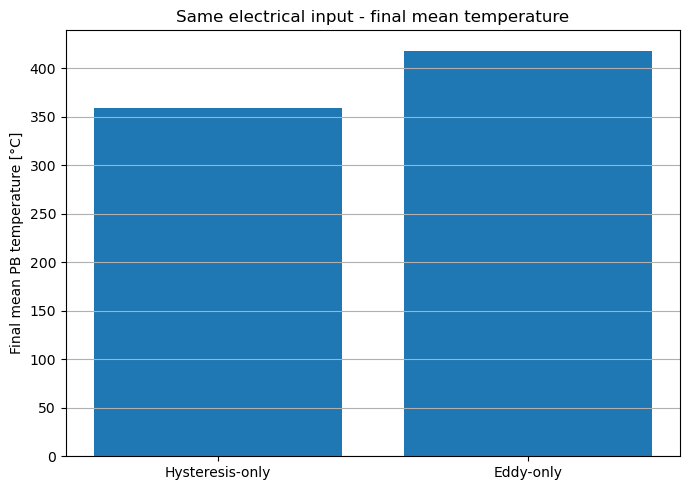

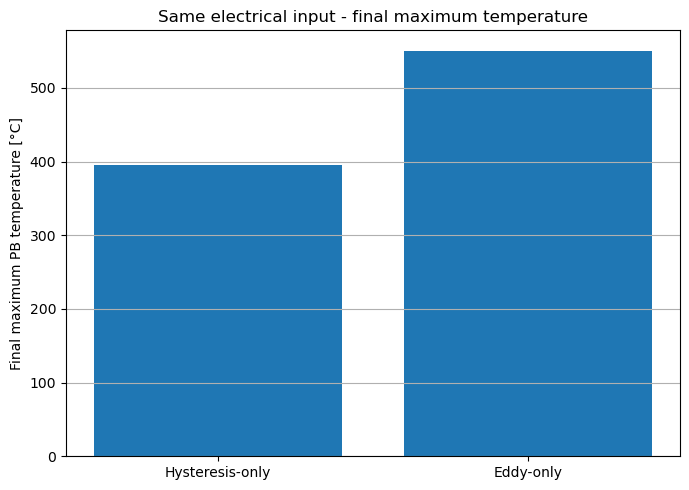

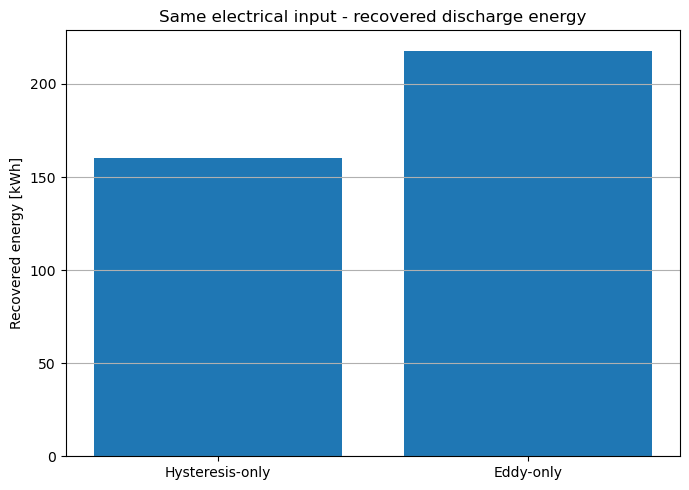

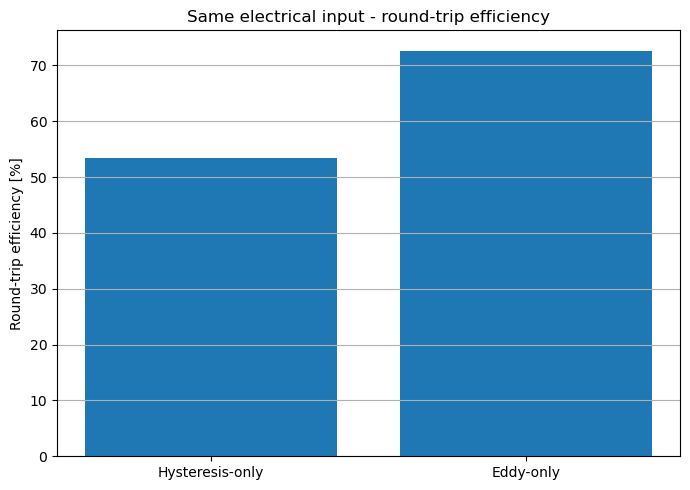

In [11]:
# ============================================================
# SIMPLE COMPARISON PLOTS
# ============================================================

df = df_same_energy_1cycle.copy()

plt.figure(figsize=(7, 5))
plt.bar(df["case"], df["T_mean_end_charge_C"])
plt.ylabel("Final mean PB temperature [°C]")
plt.title("Same electrical input - final mean temperature")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.bar(df["case"], df["T_max_end_charge_C"])
plt.ylabel("Final maximum PB temperature [°C]")
plt.title("Same electrical input - final maximum temperature")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.bar(df["case"], df["E_rec_discharge_kWh"])
plt.ylabel("Recovered energy [kWh]")
plt.title("Same electrical input - recovered discharge energy")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.bar(df["case"], df["round_trip_efficiency_percent"])
plt.ylabel("Round-trip efficiency [%]")
plt.title("Same electrical input - round-trip efficiency")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [12]:
cols_check = [
    "case",
    "E_input_charge_kWh",
    "E_ind_charge_kWh",
    "E_coil_loss_kWh",
    "charge_time_h",
    "T_mean_end_charge_C",
    "T_max_end_charge_C",
    "T_min_end_charge_C",
    "E_rec_discharge_kWh",
    "discharge_time_h",
    "round_trip_efficiency_percent"
]

display(df_same_energy_1cycle[cols_check].round(3))

,case,E_input_charge_kWh,E_ind_charge_kWh,E_coil_loss_kWh,charge_time_h,T_mean_end_charge_C,T_max_end_charge_C,T_min_end_charge_C,E_rec_discharge_kWh,discharge_time_h,round_trip_efficiency_percent
0,Hysteresis-only,300.0,240.990,59.010,2.191,359.629,395.076,267.761,160.491,2.238,53.497
1,Eddy-only,300.0,294.603,5.397,3.572,418.288,550.481,231.098,217.912,2.408,72.637


In [ ]:
#FINE CASO CICLO UNICO

In [ ]:
#CASO 3 CICLI

In [13]:
# ============================================================
# SAME ENERGY INPUT CYCLES - IMPORT
# ============================================================

import os
import sys
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CODE_DIR = r"C:\Users\lolle\OneDrive\Desktop\TESI_MAGISTRALE\codice"

if CODE_DIR not in sys.path:
    sys.path.append(CODE_DIR)

import class_IHTES
import class_IHTES_2D_Tdep
import discharging_model
import cycles_same_energy_input

importlib.reload(class_IHTES)
importlib.reload(class_IHTES_2D_Tdep)
importlib.reload(discharging_model)
importlib.reload(cycles_same_energy_input)

from class_IHTES_2D_Tdep import IHTES2D_Tdep
from cycles_same_energy_input import attach_same_energy_cycle_model

attach_same_energy_cycle_model(IHTES2D_Tdep)

print("Same-energy-input cycling model ready.")


Discharging model attached to IHTES2D_Tdep.
Same-energy-input cycle model attached to IHTES2D_Tdep.
Same-energy-input cycling model ready.


In [14]:
# ============================================================
# CREATE TES OBJECT FOR CYCLES
# ============================================================

tes_cycle = IHTES2D_Tdep(
    TH_mag,
    EM_mag,
    HYS_mag,
    geom_1,
    mesh=(20, 40)
)

print("TES object created.")
print("Nr =", tes_cycle.Nr)
print("Nz =", tes_cycle.Nz)
print("H_TES [m] =", tes_cycle.H_TES)
print("D_TES [m] =", tes_cycle.D_TES)
print("V_TES [m3] =", tes_cycle.V_TES)

TES object created.
Nr = 20
Nz = 40
H_TES [m] = 1.72
D_TES [m] = 0.86
V_TES [m3] = 0.9991144284358546


In [15]:
# ============================================================
# CASES TO COMPARE
# ============================================================

cases_same_energy = [
    {
        "case_name": "Hysteresis-only",
        "freq": 80,
        "I": 2203.0,
        "source_mode": "hys_only",
    },
    {
        "case_name": "Eddy-only",
        "freq": 50000,
        "I": 100.0,
        "source_mode": "eddy_only",
    },
]

In [16]:
# ============================================================
# SAME ENERGY INPUT - MULTIPLE CHARGE/DISCHARGE CYCLES
# ============================================================

results_same_energy_cycles = tes_cycle.run_same_energy_input_comparison(
    cases=cases_same_energy,

    # stessa energia elettrica in ingresso per ogni charging phase
    E_input_target_kWh=300.0,

    # numero di cicli
    n_cycles=3,

    # initial condition first cycle
    T_init_full=293.15,

    # ambient and coil temperature
    T_amb=293.15,
    T_coil=333.15,

    # electrical input definition
    electrical_input="coil",       # E_input = E_ind + E_coil_loss

    # charging numerical parameters
    charging_dt=10.0,
    max_ch_time=8 * 3600,
    Tmax_safety_C=650,

    # discharging parameters
    m_dot_total=0.20,
    T_air_in=293.15,
    T_out_stop=300 + 273.15,       # stop when outlet air falls below 300 °C
    discharging_dt=5.0,
    max_dis_time=4 * 3600,

    # packed bed / discharge assumptions
    d_p=0.02,
    half_method="average_two_ends",

    verbose=True,
)



####################################################
CASE: Hysteresis-only | CYCLE 1/3
####################################################
========== CHARGING: SAME ENERGY INPUT ==========
source_mode             = hys_only
freq                    = 80.000 Hz
I                       = 2203.000 A
electrical_input        = coil
E_input_target          = 300.000 kWh
T_mean initial          = 20.00 °C
T_max initial           = 20.00 °C
========== CHARGING RESULT ==========
stop reason         = E_input_target_reached
charging time       = 2.191 h
E_input_charge      = 300.000 kWh
E_ind_charge        = 240.990 kWh
E_coil_loss         = 59.010 kWh
E_conv_loss         = 0.000 kWh
T_mean final        = 359.63 °C
T_max final         = 395.08 °C
========== DISCHARGE SETUP ==========
H_full  = 1.720 m = 172.0 cm
H_half  = 0.860 m = 86.0 cm
Nz_half = 20
dz_half = 0.0430 m = 4.30 cm
m_dot_total = 0.2000 kg/s
m_dot_half  = 0.1000 kg/s
G = 0.1722 kg/m2/s
u_D_ref     = 0.1429 m/s
u_int_ref   = 0.35

In [17]:
# ============================================================
# SUMMARY TABLE - MULTIPLE CYCLES
# ============================================================

df_same_energy_cycles = pd.DataFrame(results_same_energy_cycles["summary"])

display(df_same_energy_cycles.round(3))

,case,cycle,source_mode,freq_Hz,I_A,electrical_input,E_input_charge_kWh,E_ind_charge_kWh,E_coil_loss_kWh,E_conv_loss_kWh,...,E_rec_discharge_kWh,discharge_time_h,T_out_final_C,T_s_mean_end_discharge_C,T_s_max_end_discharge_C,T_s_min_end_discharge_C,round_trip_efficiency,round_trip_efficiency_percent,charge_stop_reason,discharge_stop_reason
0,Hysteresis-only,1,hys_only,80,2203.0,coil,300.000,240.990,59.010,0.0,...,160.491,2.238,299.827,130.450,304.626,23.933,0.535,53.497,E_input_target_reached,T_out_below_threshold
1,Hysteresis-only,2,hys_only,80,2203.0,coil,300.000,226.457,73.543,0.0,...,223.057,2.660,299.989,117.872,305.559,22.586,0.744,74.352,E_input_target_reached,T_out_below_threshold
2,Hysteresis-only,3,hys_only,80,2203.0,coil,300.000,228.387,71.613,0.0,...,216.207,2.611,299.897,119.003,305.397,22.699,0.721,72.069,E_input_target_reached,T_out_below_threshold
3,Eddy-only,1,eddy_only,50000,100.0,coil,300.000,294.603,5.397,0.0,...,217.912,2.408,299.777,116.730,308.435,22.617,0.726,72.637,E_input_target_reached,T_out_below_threshold
4,Eddy-only,2,eddy_only,50000,100.0,coil,189.726,186.805,2.921,0.0,...,175.401,1.821,299.894,117.410,308.652,23.220,0.924,92.449,Tmax_safety_reached,T_out_below_threshold
5,Eddy-only,3,eddy_only,50000,100.0,coil,191.608,188.669,2.938,0.0,...,177.276,1.842,299.945,117.659,308.641,23.217,0.925,92.520,Tmax_safety_reached,T_out_below_threshold


In [18]:
# ============================================================
# CLEAN SUMMARY TABLE
# ============================================================

cols_clean = [
    "case",
    "cycle",
    "source_mode",
    "freq_Hz",
    "I_A",
    "E_input_charge_kWh",
    "E_ind_charge_kWh",
    "E_coil_loss_kWh",
    "charge_time_h",
    "T_mean_end_charge_C",
    "T_max_end_charge_C",
    "T_min_end_charge_C",
    "E_rec_discharge_kWh",
    "discharge_time_h",
    "T_out_final_C",
    "T_s_mean_end_discharge_C",
    "T_s_max_end_discharge_C",
    "T_s_min_end_discharge_C",
    "round_trip_efficiency_percent",
    "charge_stop_reason",
    "discharge_stop_reason",
]

df_clean = df_same_energy_cycles[cols_clean]

display(df_clean.round(3))

,case,cycle,source_mode,freq_Hz,I_A,E_input_charge_kWh,E_ind_charge_kWh,E_coil_loss_kWh,charge_time_h,T_mean_end_charge_C,...,T_min_end_charge_C,E_rec_discharge_kWh,discharge_time_h,T_out_final_C,T_s_mean_end_discharge_C,T_s_max_end_discharge_C,T_s_min_end_discharge_C,round_trip_efficiency_percent,charge_stop_reason,discharge_stop_reason
0,Hysteresis-only,1,hys_only,80,2203.0,300.000,240.990,59.010,2.191,359.629,...,267.761,160.491,2.238,299.827,130.450,304.626,23.933,53.497,E_input_target_reached,T_out_below_threshold
1,Hysteresis-only,2,hys_only,80,2203.0,300.000,226.457,73.543,2.731,426.341,...,331.349,223.057,2.660,299.989,117.872,305.559,22.586,74.352,E_input_target_reached,T_out_below_threshold
2,Hysteresis-only,3,hys_only,80,2203.0,300.000,228.387,71.613,2.659,419.077,...,321.973,216.207,2.611,299.897,119.003,305.397,22.699,72.069,E_input_target_reached,T_out_below_threshold
3,Eddy-only,1,eddy_only,50000,100.0,300.000,294.603,5.397,3.572,418.288,...,231.098,217.912,2.408,299.777,116.730,308.435,22.617,72.637,E_input_target_reached,T_out_below_threshold
4,Eddy-only,2,eddy_only,50000,100.0,189.726,186.805,2.921,1.933,360.591,...,123.975,175.401,1.821,299.894,117.410,308.652,23.220,92.449,Tmax_safety_reached,T_out_below_threshold
5,Eddy-only,3,eddy_only,50000,100.0,191.608,188.669,2.938,1.944,363.447,...,127.357,177.276,1.842,299.945,117.659,308.641,23.217,92.520,Tmax_safety_reached,T_out_below_threshold


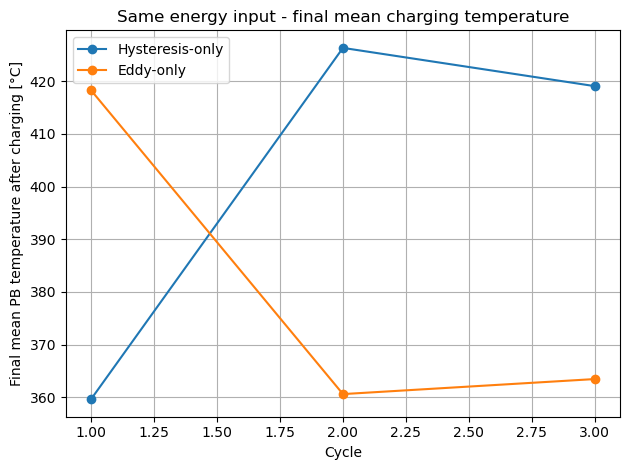

In [19]:
# ============================================================
# PLOT - FINAL MEAN TEMPERATURE AFTER CHARGING
# ============================================================

for case_name in df_clean["case"].unique():
    df_case = df_clean[df_clean["case"] == case_name]

    plt.plot(
        df_case["cycle"],
        df_case["T_mean_end_charge_C"],
        marker="o",
        label=case_name
    )

plt.xlabel("Cycle")
plt.ylabel("Final mean PB temperature after charging [°C]")
plt.title("Same energy input - final mean charging temperature")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

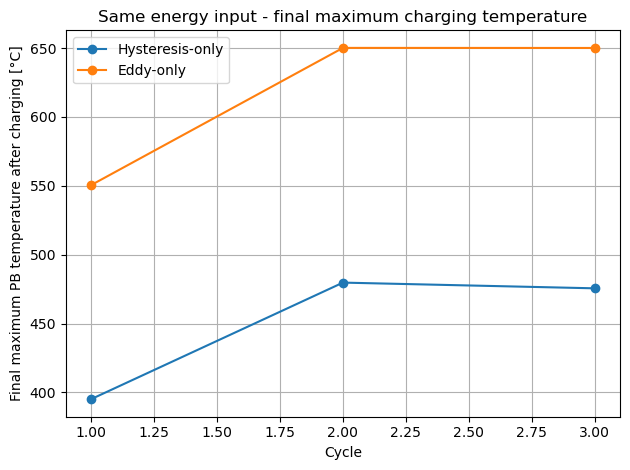

In [20]:
# ============================================================
# PLOT - FINAL MAX TEMPERATURE AFTER CHARGING
# ============================================================

for case_name in df_clean["case"].unique():
    df_case = df_clean[df_clean["case"] == case_name]

    plt.plot(
        df_case["cycle"],
        df_case["T_max_end_charge_C"],
        marker="o",
        label=case_name
    )

plt.xlabel("Cycle")
plt.ylabel("Final maximum PB temperature after charging [°C]")
plt.title("Same energy input - final maximum charging temperature")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

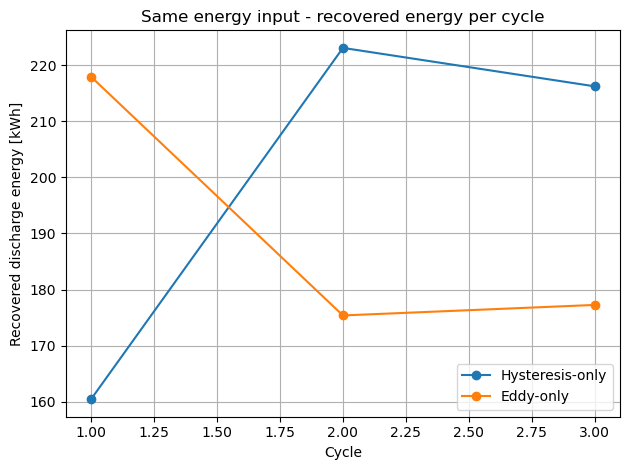

In [21]:
# ============================================================
# PLOT - RECOVERED DISCHARGE ENERGY
# ============================================================

for case_name in df_clean["case"].unique():
    df_case = df_clean[df_clean["case"] == case_name]

    plt.plot(
        df_case["cycle"],
        df_case["E_rec_discharge_kWh"],
        marker="o",
        label=case_name
    )

plt.xlabel("Cycle")
plt.ylabel("Recovered discharge energy [kWh]")
plt.title("Same energy input - recovered energy per cycle")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

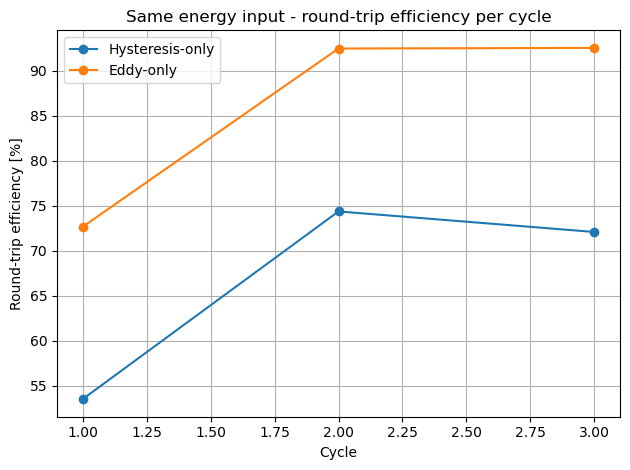

In [22]:
# ============================================================
# PLOT - ROUND-TRIP EFFICIENCY
# ============================================================

for case_name in df_clean["case"].unique():
    df_case = df_clean[df_clean["case"] == case_name]

    plt.plot(
        df_case["cycle"],
        df_case["round_trip_efficiency_percent"],
        marker="o",
        label=case_name
    )

plt.xlabel("Cycle")
plt.ylabel("Round-trip efficiency [%]")
plt.title("Same energy input - round-trip efficiency per cycle")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

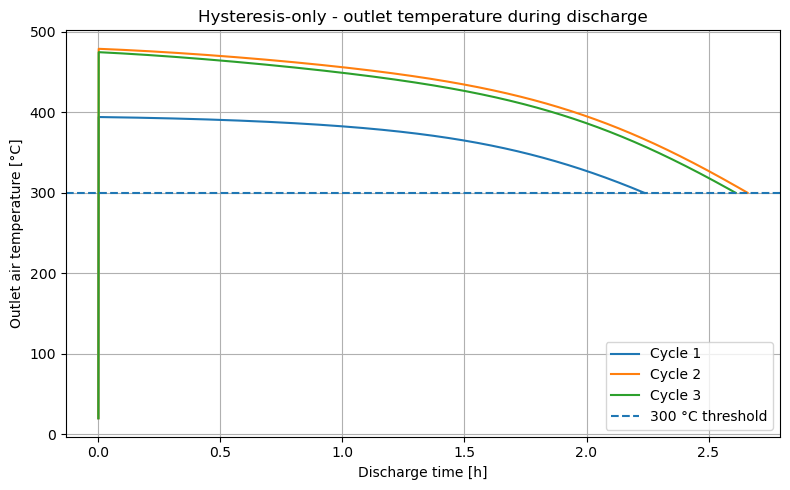

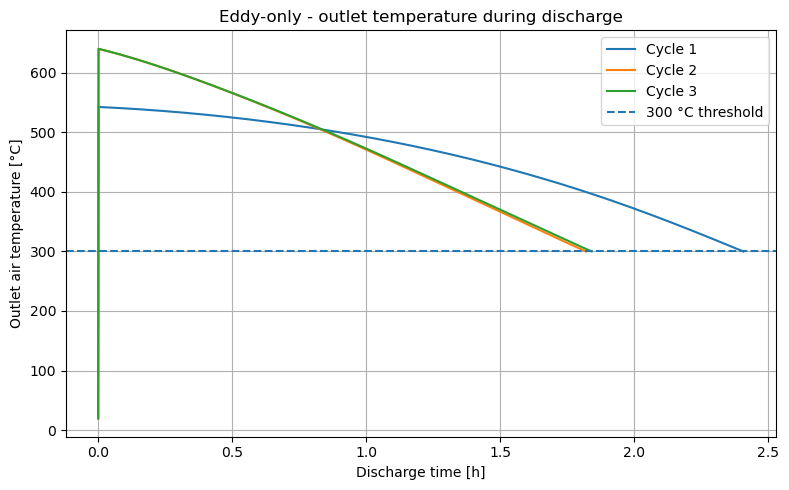

In [23]:
# ============================================================
# PLOT - OUTLET TEMPERATURE DURING EACH DISCHARGE
# ============================================================

for case_name, res_case in results_same_energy_cycles["results"].items():

    plt.figure(figsize=(8, 5))

    for cyc_data in res_case["cycles"]:
        cyc = cyc_data["cycle"]
        dis = cyc_data["discharge"]

        plt.plot(
            dis["time"] / 3600,
            dis["T_out"] - 273.15,
            label=f"Cycle {cyc}"
        )

    plt.axhline(300, linestyle="--", label="300 °C threshold")

    plt.xlabel("Discharge time [h]")
    plt.ylabel("Outlet air temperature [°C]")
    plt.title(f"{case_name} - outlet temperature during discharge")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

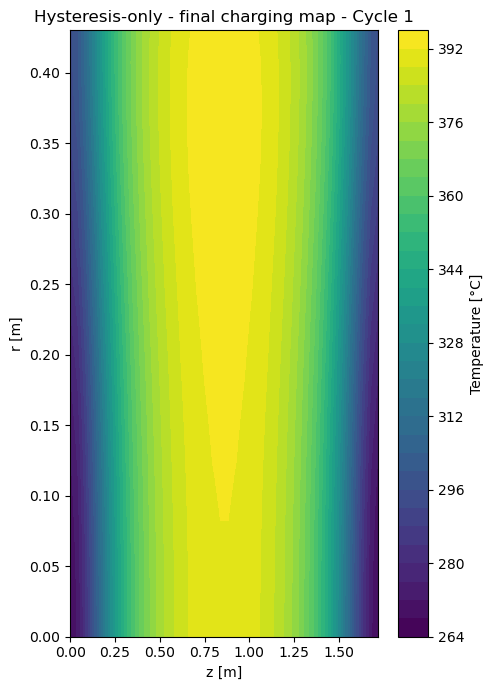

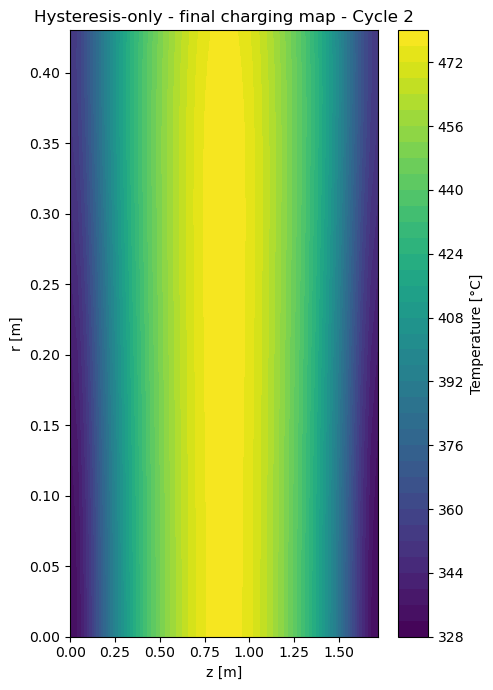

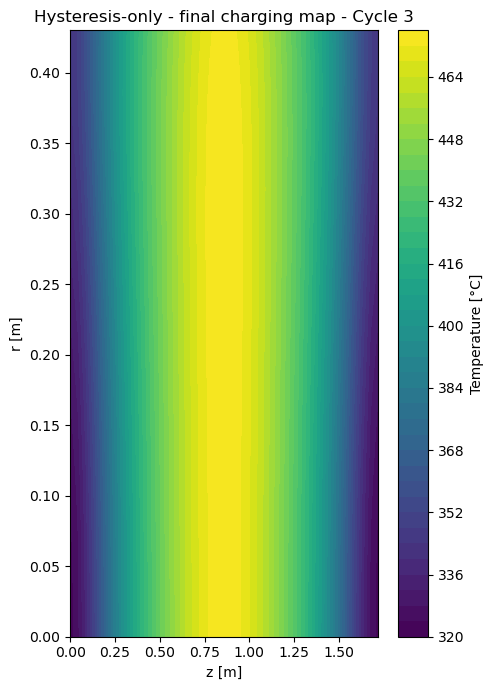

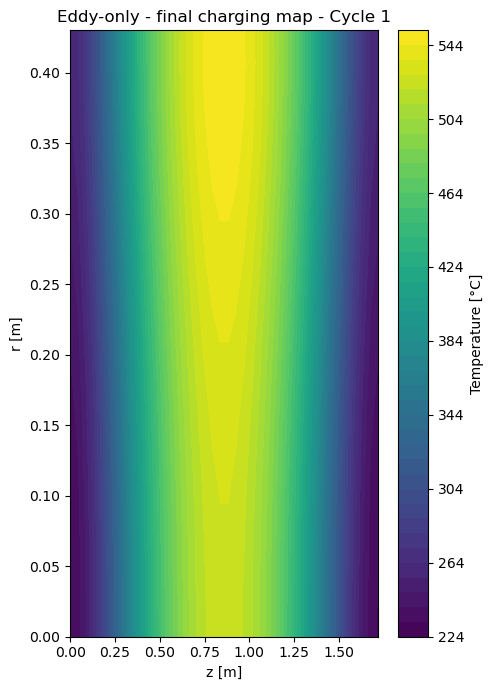

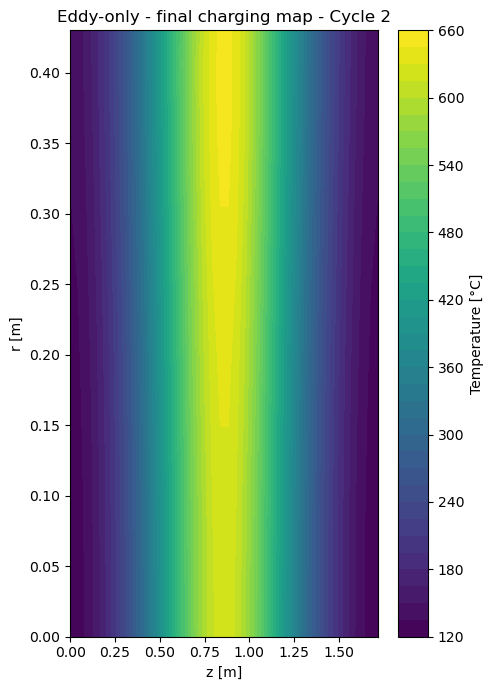

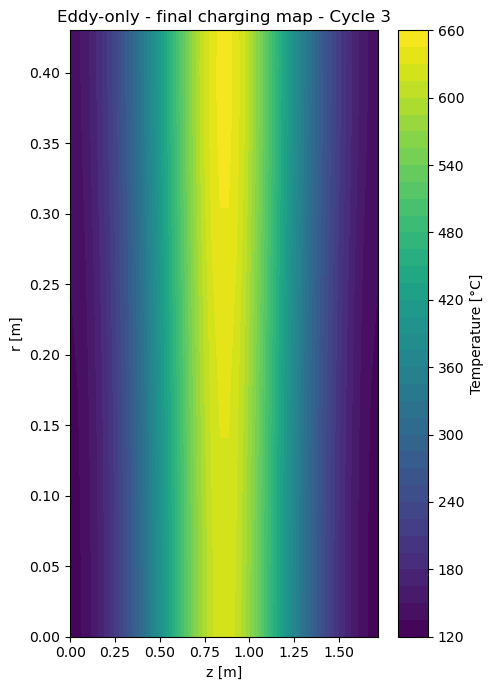

In [24]:
# ============================================================
# FINAL CHARGING MAPS FOR EACH CYCLE
# ============================================================

for case_name, res_case in results_same_energy_cycles["results"].items():

    for cyc_data in res_case["cycles"]:
        cyc = cyc_data["cycle"]
        T_charge = cyc_data["charge"]["T_final"]

        plt.figure(figsize=(5, 7))
        cp = plt.contourf(
            tes_cycle.z,
            tes_cycle.r,
            T_charge - 273.15,
            levels=40
        )
        plt.colorbar(cp, label="Temperature [°C]")
        plt.xlabel("z [m]")
        plt.ylabel("r [m]")
        plt.title(f"{case_name} - final charging map - Cycle {cyc}")
        plt.tight_layout()
        plt.show()

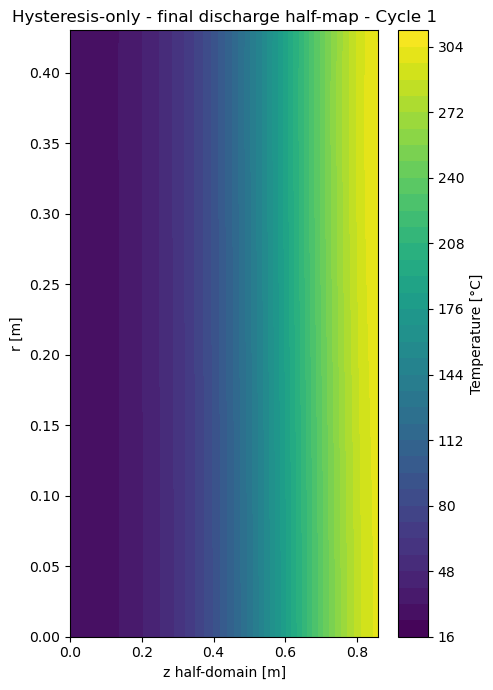

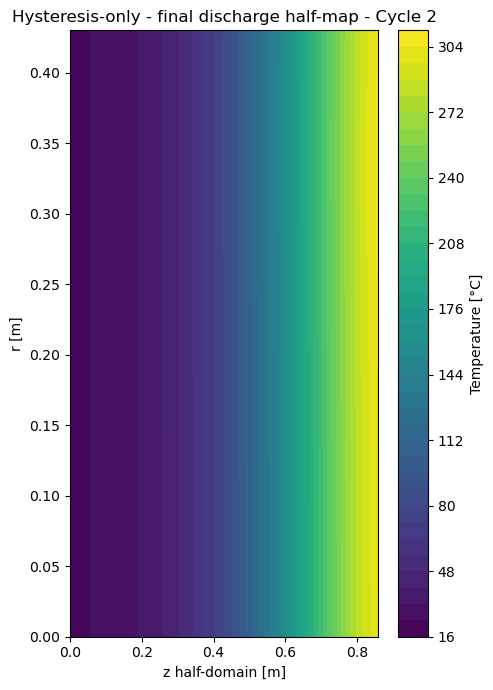

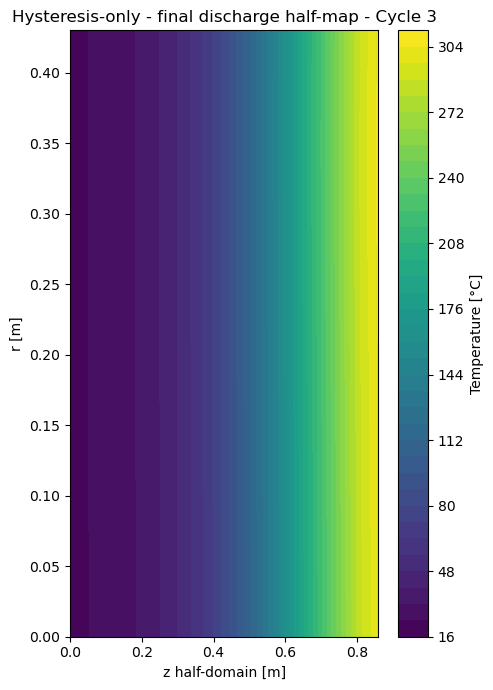

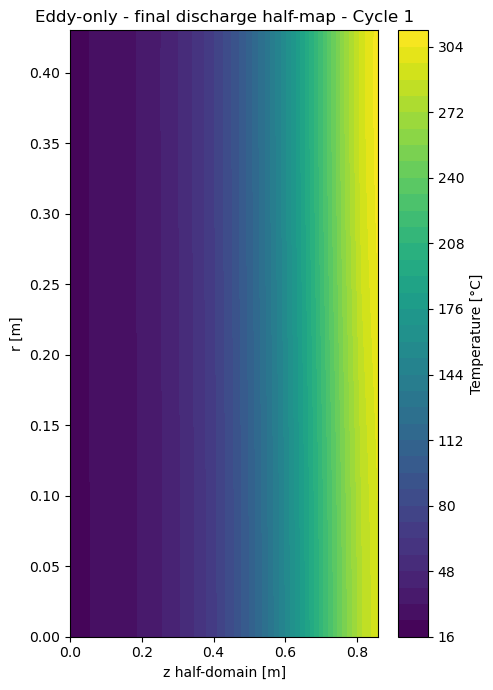

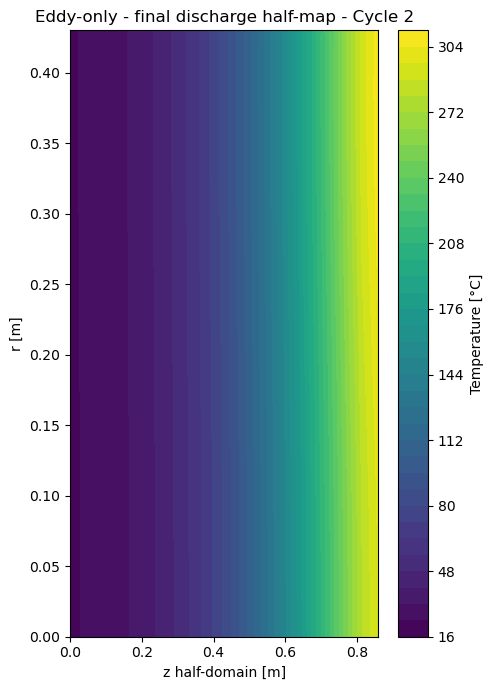

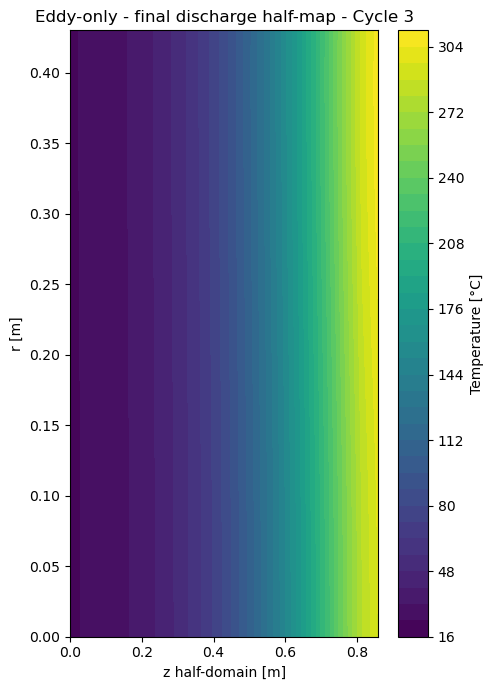

In [25]:
# ============================================================
# FINAL DISCHARGING MAPS FOR EACH CYCLE
# ============================================================

for case_name, res_case in results_same_energy_cycles["results"].items():

    for cyc_data in res_case["cycles"]:
        cyc = cyc_data["cycle"]
        T_half_discharge = cyc_data["discharge"]["T_s_final_half"]

        plt.figure(figsize=(5, 7))
        cp = plt.contourf(
            np.linspace(0, tes_cycle.H_TES / 2, T_half_discharge.shape[1]),
            tes_cycle.r,
            T_half_discharge - 273.15,
            levels=40
        )
        plt.colorbar(cp, label="Temperature [°C]")
        plt.xlabel("z half-domain [m]")
        plt.ylabel("r [m]")
        plt.title(f"{case_name} - final discharge half-map - Cycle {cyc}")
        plt.tight_layout()
        plt.show()

In [7]:
# ============================================================
# SAME TMEAN TARGET CYCLES - IMPORT
# ============================================================

import os
import sys
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CODE_DIR = r"C:\Users\lolle\OneDrive\Desktop\TESI_MAGISTRALE\codice"

if CODE_DIR not in sys.path:
    sys.path.append(CODE_DIR)

import class_IHTES
import class_IHTES_2D_Tdep
import discharging_model
import cycles_same_Tmean_target

importlib.reload(class_IHTES)
importlib.reload(class_IHTES_2D_Tdep)
importlib.reload(discharging_model)
importlib.reload(cycles_same_Tmean_target)

from class_IHTES_2D_Tdep import IHTES2D_Tdep
from cycles_same_Tmean_target import attach_same_Tmean_cycle_model

attach_same_Tmean_cycle_model(IHTES2D_Tdep)

print("Same-Tmean-target cycling model ready.")

Discharging model attached to IHTES2D_Tdep.
Same-Tmean-target cycle model attached to IHTES2D_Tdep.
Same-Tmean-target cycling model ready.


In [8]:
# ============================================================
# CREATE TES OBJECT FOR SAME TMEAN CYCLES
# ============================================================

tes_Tmean = IHTES2D_Tdep(
    TH_mag,
    EM_mag,
    HYS_mag,
    geom_1,
    mesh=(20, 40)
)

print("TES object created.")
print("Nr =", tes_Tmean.Nr)
print("Nz =", tes_Tmean.Nz)
print("H_TES [m] =", tes_Tmean.H_TES)
print("D_TES [m] =", tes_Tmean.D_TES)
print("V_TES [m3] =", tes_Tmean.V_TES)

TES object created.
Nr = 20
Nz = 40
H_TES [m] = 1.72
D_TES [m] = 0.86
V_TES [m3] = 0.9991144284358546


In [9]:
# ============================================================
# CASES TO COMPARE
# ============================================================

cases_same_Tmean = [
    {
        "case_name": "Hysteresis-only",
        "freq": 80,
        "I": 2203.0,
        "source_mode": "hys_only",
    },
    {
        "case_name": "Eddy-only",
        "freq": 50000,
        "I": 100.0,
        "source_mode": "eddy_only",
    },
]

In [10]:
# ============================================================
# SAME TMEAN TARGET - MULTIPLE CHARGE/DISCHARGE CYCLES
# ============================================================

results_same_Tmean_cycles = tes_Tmean.run_same_Tmean_target_comparison(
    cases=cases_same_Tmean,

    # stessa temperatura media finale del packed bed
    T_mean_target_C=400.0,

    # numero di cicli
    n_cycles=3,

    # initial condition first cycle
    T_init_full=293.15,

    # ambient and coil temperature
    T_amb=293.15,
    T_coil=333.15,

    # electrical input definition
    electrical_input="coil",       # E_input = E_ind + E_coil_loss

    # charging numerical parameters
    charging_dt=10.0,
    max_ch_time=10 * 3600,
    Tmax_safety_C=650,

    # discharging parameters
    m_dot_total=0.20,
    T_air_in=293.15,
    T_out_stop=300 + 273.15,       # stop when outlet air falls below 300 °C
    discharging_dt=5.0,
    max_dis_time=4 * 3600,

    # packed bed / discharge assumptions
    d_p=0.02,
    half_method="average_two_ends",

    verbose=True,
)



####################################################
CASE: Hysteresis-only | CYCLE 1/3
####################################################
========== CHARGING: SAME TMEAN TARGET ==========
source_mode             = hys_only
freq                    = 80.000 Hz
I                       = 2203.000 A
electrical_input        = coil
T_mean_target           = 400.00 °C
T_mean initial          = 20.00 °C
T_max initial           = 20.00 °C
========== CHARGING RESULT ==========
stop reason         = T_mean_target_reached
charging time       = 2.716 h
E_input_charge      = 348.661 kWh
E_ind_charge        = 275.501 kWh
E_coil_loss         = 73.160 kWh
E_conv_loss         = 0.000 kWh
T_mean final        = 400.00 °C
T_max final         = 430.94 °C
========== DISCHARGE SETUP ==========
H_full  = 1.720 m = 172.0 cm
H_half  = 0.860 m = 86.0 cm
Nz_half = 20
dz_half = 0.0430 m = 4.30 cm
m_dot_total = 0.2000 kg/s
m_dot_half  = 0.1000 kg/s
G = 0.1722 kg/m2/s
u_D_ref     = 0.1429 m/s
u_int_ref   = 0.3573 

In [11]:
# ============================================================
# SUMMARY TABLE - SAME TMEAN TARGET
# ============================================================

df_same_Tmean_cycles = pd.DataFrame(results_same_Tmean_cycles["summary"])

display(df_same_Tmean_cycles.round(3))

,case,cycle,source_mode,freq_Hz,I_A,electrical_input,T_mean_target_C,E_input_charge_kWh,E_ind_charge_kWh,E_coil_loss_kWh,...,E_rec_discharge_kWh,discharge_time_h,T_out_final_C,T_s_mean_end_discharge_C,T_s_max_end_discharge_C,T_s_min_end_discharge_C,round_trip_efficiency,round_trip_efficiency_percent,charge_stop_reason,discharge_stop_reason
0,Hysteresis-only,1,hys_only,80,2203.0,coil,400.0,348.661,275.501,73.160,...,198.918,2.553,299.893,121.597,305.186,22.928,0.571,57.052,T_mean_target_reached,T_out_below_threshold
1,Hysteresis-only,2,hys_only,80,2203.0,coil,400.0,272.195,209.358,62.837,...,198.385,2.467,299.781,122.050,305.107,23.028,0.729,72.883,T_mean_target_reached,T_out_below_threshold
2,Hysteresis-only,3,hys_only,80,2203.0,coil,400.0,271.849,209.078,62.771,...,198.382,2.467,299.807,122.056,305.134,23.028,0.730,72.975,T_mean_target_reached,T_out_below_threshold
3,Eddy-only,1,eddy_only,50000,100.0,coil,400.0,283.685,278.464,5.221,...,200.997,2.308,299.983,119.347,308.358,22.890,0.709,70.852,T_mean_target_reached,T_out_below_threshold
4,Eddy-only,2,eddy_only,50000,100.0,coil,400.0,189.883,186.979,2.903,...,177.367,1.838,299.885,117.075,308.659,23.163,0.934,93.409,Tmax_safety_reached,T_out_below_threshold
5,Eddy-only,3,eddy_only,50000,100.0,coil,400.0,191.464,188.524,2.939,...,176.940,1.839,299.870,117.662,308.562,23.223,0.924,92.415,Tmax_safety_reached,T_out_below_threshold


In [13]:
# ============================================================
# CLEAN SUMMARY TABLE
# ============================================================

cols_clean_Tmean = [
    "case",
    "cycle",
    "source_mode",
    "freq_Hz",
    "I_A",
    "T_mean_target_C",
    "E_input_charge_kWh",
    "E_ind_charge_kWh",
    "E_coil_loss_kWh",
    "charge_time_h",
    "T_mean_end_charge_C",
    "T_max_end_charge_C",
    "T_min_end_charge_C",
    "E_rec_discharge_kWh",
    "discharge_time_h",
    "T_out_final_C",
    "T_s_mean_end_discharge_C",
    "T_s_max_end_discharge_C",
    "T_s_min_end_discharge_C",
    "round_trip_efficiency_percent",
    "charge_stop_reason",
    "discharge_stop_reason",
]

df_Tmean_clean = df_same_Tmean_cycles[cols_clean_Tmean]

display(df_Tmean_clean.round(3))

,case,cycle,source_mode,freq_Hz,I_A,T_mean_target_C,E_input_charge_kWh,E_ind_charge_kWh,E_coil_loss_kWh,charge_time_h,...,T_min_end_charge_C,E_rec_discharge_kWh,discharge_time_h,T_out_final_C,T_s_mean_end_discharge_C,T_s_max_end_discharge_C,T_s_min_end_discharge_C,round_trip_efficiency_percent,charge_stop_reason,discharge_stop_reason
0,Hysteresis-only,1,hys_only,80,2203.0,400.0,348.661,275.501,73.160,2.716,...,320.333,198.918,2.553,299.893,121.597,305.186,22.928,57.052,T_mean_target_reached,T_out_below_threshold
1,Hysteresis-only,2,hys_only,80,2203.0,400.0,272.195,209.358,62.837,2.333,...,291.315,198.385,2.467,299.781,122.050,305.107,23.028,72.883,T_mean_target_reached,T_out_below_threshold
2,Hysteresis-only,3,hys_only,80,2203.0,400.0,271.849,209.078,62.771,2.331,...,291.288,198.382,2.467,299.807,122.056,305.134,23.028,72.975,T_mean_target_reached,T_out_below_threshold
3,Eddy-only,1,eddy_only,50000,100.0,400.0,283.685,278.464,5.221,3.455,...,220.830,200.997,2.308,299.983,119.347,308.358,22.890,70.852,T_mean_target_reached,T_out_below_threshold
4,Eddy-only,2,eddy_only,50000,100.0,400.0,189.883,186.979,2.903,1.921,...,124.646,177.367,1.838,299.885,117.075,308.659,23.163,93.409,Tmax_safety_reached,T_out_below_threshold
5,Eddy-only,3,eddy_only,50000,100.0,400.0,191.464,188.524,2.939,1.945,...,127.110,176.940,1.839,299.870,117.662,308.562,23.223,92.415,Tmax_safety_reached,T_out_below_threshold


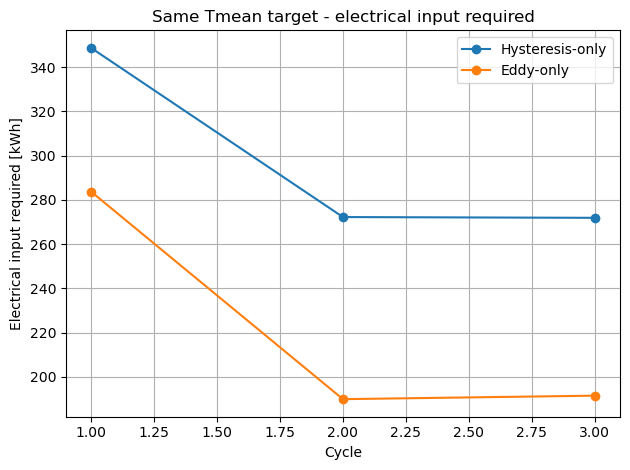

In [14]:
# ============================================================
# PLOT - ELECTRICAL INPUT REQUIRED TO REACH TMEAN TARGET
# ============================================================

for case_name in df_Tmean_clean["case"].unique():
    df_case = df_Tmean_clean[df_Tmean_clean["case"] == case_name]

    plt.plot(
        df_case["cycle"],
        df_case["E_input_charge_kWh"],
        marker="o",
        label=case_name
    )

plt.xlabel("Cycle")
plt.ylabel("Electrical input required [kWh]")
plt.title("Same Tmean target - electrical input required")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

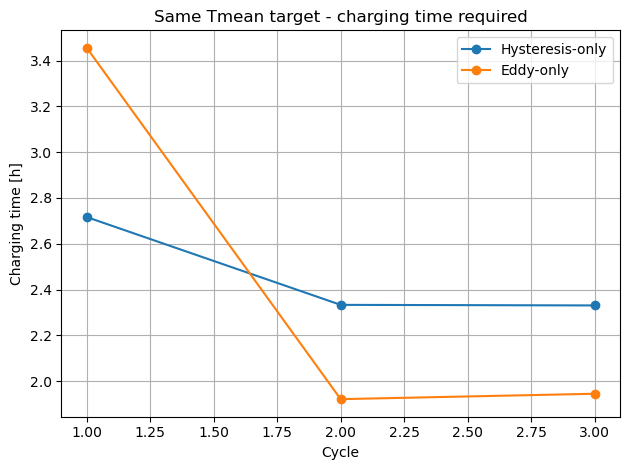

In [15]:
# ============================================================
# PLOT - CHARGING TIME REQUIRED
# ============================================================

for case_name in df_Tmean_clean["case"].unique():
    df_case = df_Tmean_clean[df_Tmean_clean["case"] == case_name]

    plt.plot(
        df_case["cycle"],
        df_case["charge_time_h"],
        marker="o",
        label=case_name
    )

plt.xlabel("Cycle")
plt.ylabel("Charging time [h]")
plt.title("Same Tmean target - charging time required")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

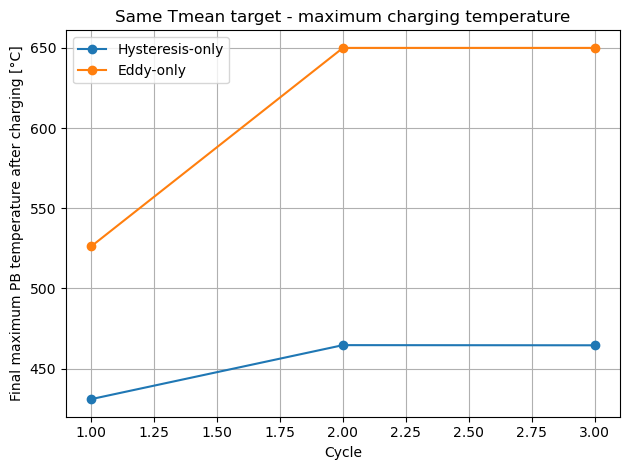

In [16]:
# ============================================================
# PLOT - FINAL MAX TEMPERATURE AFTER CHARGING
# ============================================================

for case_name in df_Tmean_clean["case"].unique():
    df_case = df_Tmean_clean[df_Tmean_clean["case"] == case_name]

    plt.plot(
        df_case["cycle"],
        df_case["T_max_end_charge_C"],
        marker="o",
        label=case_name
    )

plt.xlabel("Cycle")
plt.ylabel("Final maximum PB temperature after charging [°C]")
plt.title("Same Tmean target - maximum charging temperature")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

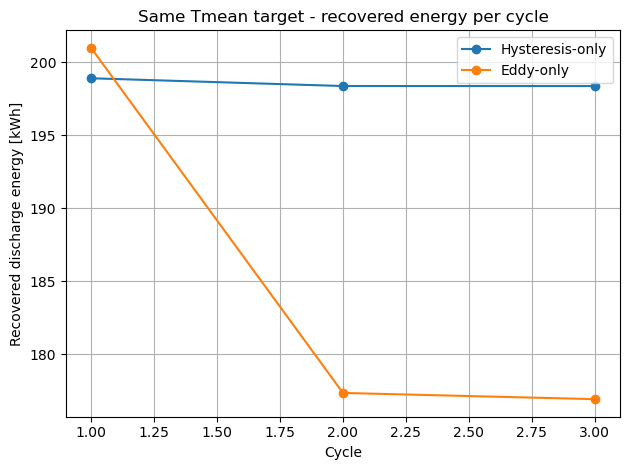

In [17]:
# ============================================================
# PLOT - RECOVERED DISCHARGE ENERGY
# ============================================================

for case_name in df_Tmean_clean["case"].unique():
    df_case = df_Tmean_clean[df_Tmean_clean["case"] == case_name]

    plt.plot(
        df_case["cycle"],
        df_case["E_rec_discharge_kWh"],
        marker="o",
        label=case_name
    )

plt.xlabel("Cycle")
plt.ylabel("Recovered discharge energy [kWh]")
plt.title("Same Tmean target - recovered energy per cycle")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

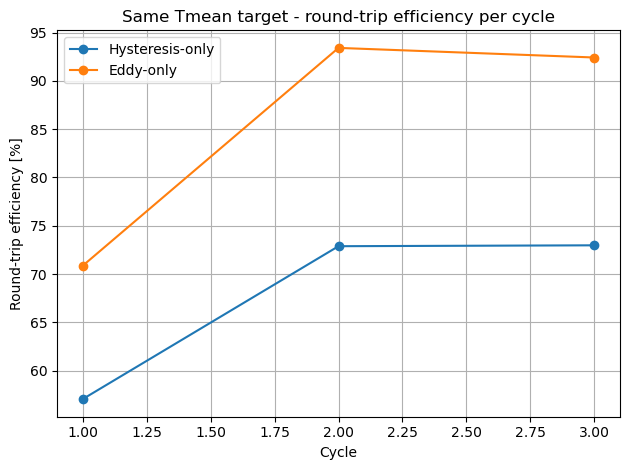

In [18]:
# ============================================================
# PLOT - ROUND-TRIP EFFICIENCY
# ============================================================

for case_name in df_Tmean_clean["case"].unique():
    df_case = df_Tmean_clean[df_Tmean_clean["case"] == case_name]

    plt.plot(
        df_case["cycle"],
        df_case["round_trip_efficiency_percent"],
        marker="o",
        label=case_name
    )

plt.xlabel("Cycle")
plt.ylabel("Round-trip efficiency [%]")
plt.title("Same Tmean target - round-trip efficiency per cycle")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

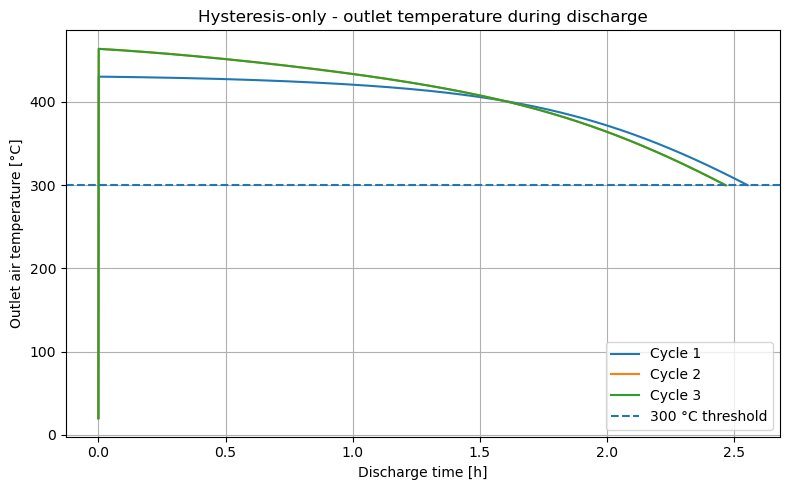

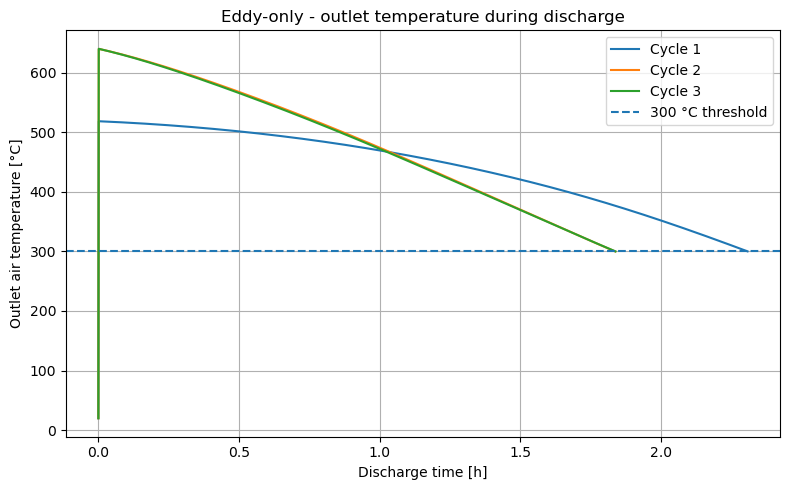

In [19]:
# ============================================================
# PLOT - OUTLET TEMPERATURE DURING EACH DISCHARGE
# ============================================================

for case_name, res_case in results_same_Tmean_cycles["results"].items():

    plt.figure(figsize=(8, 5))

    for cyc_data in res_case["cycles"]:
        cyc = cyc_data["cycle"]
        dis = cyc_data["discharge"]

        plt.plot(
            dis["time"] / 3600,
            dis["T_out"] - 273.15,
            label=f"Cycle {cyc}"
        )

    plt.axhline(300, linestyle="--", label="300 °C threshold")

    plt.xlabel("Discharge time [h]")
    plt.ylabel("Outlet air temperature [°C]")
    plt.title(f"{case_name} - outlet temperature during discharge")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

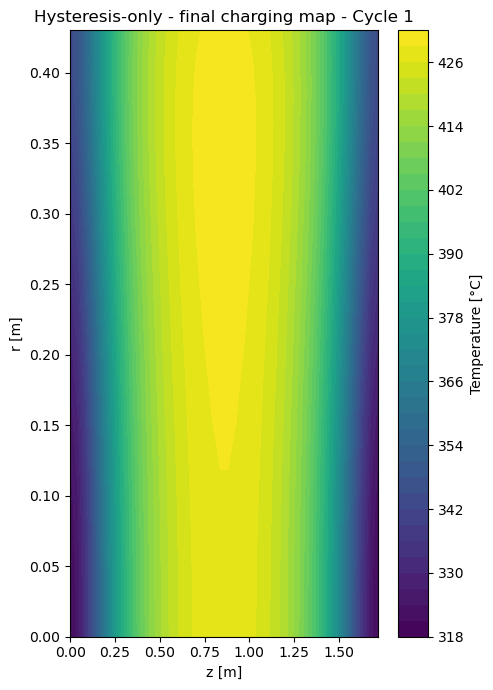

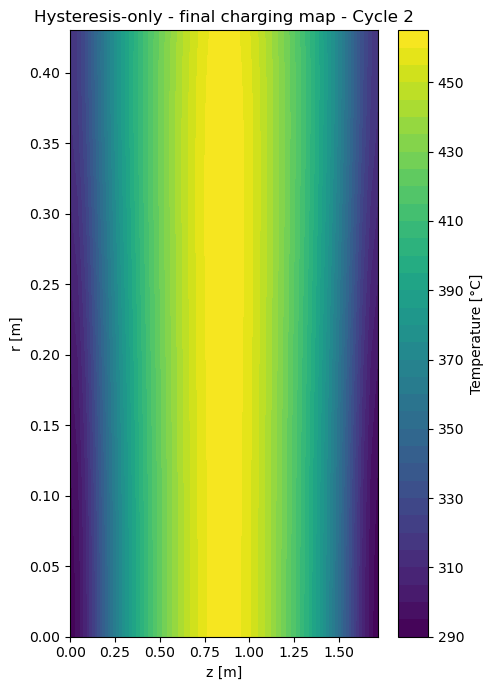

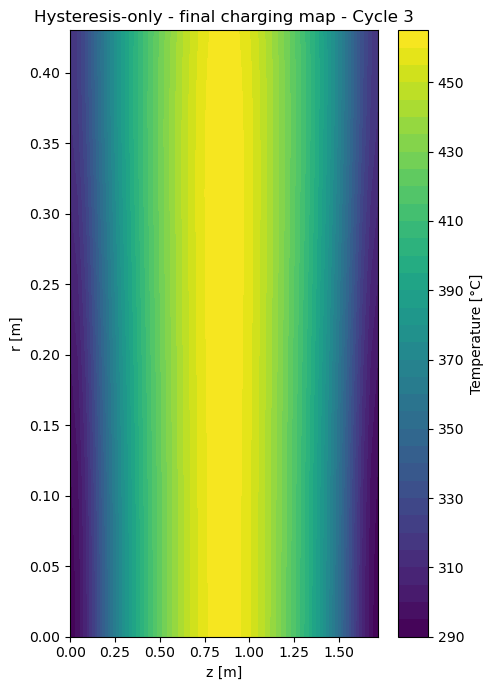

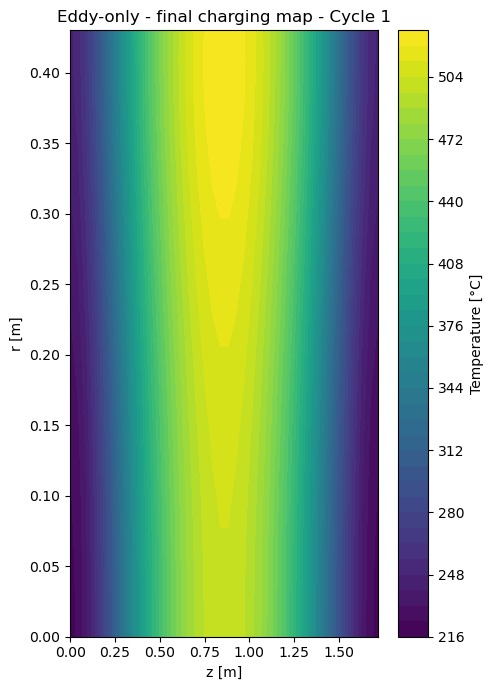

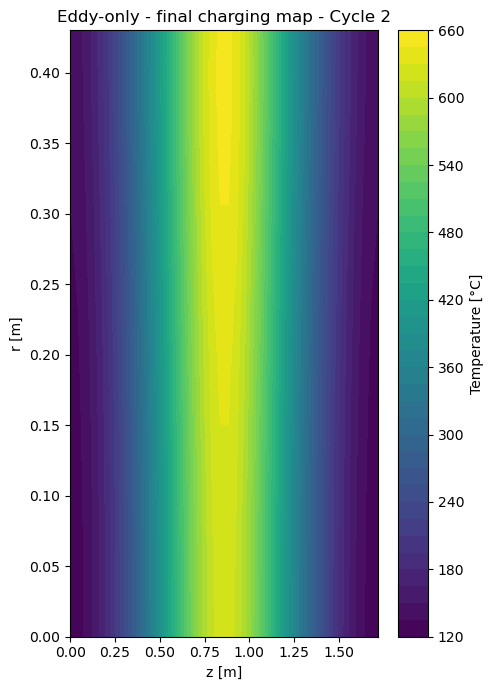

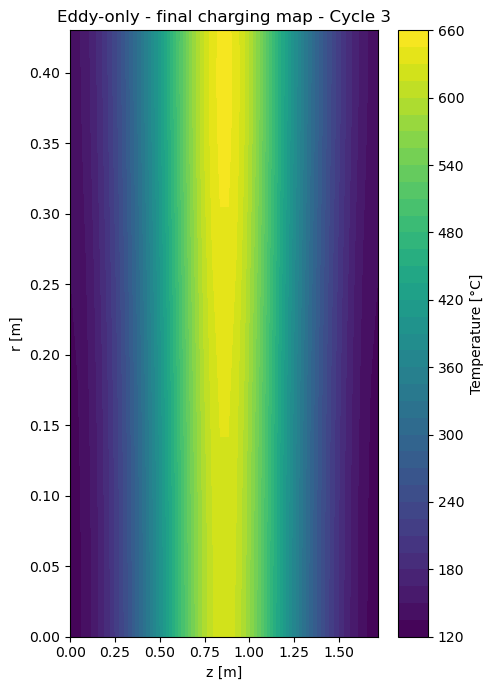

In [20]:
# ============================================================
# FINAL CHARGING MAPS FOR EACH CYCLE
# ============================================================

for case_name, res_case in results_same_Tmean_cycles["results"].items():

    for cyc_data in res_case["cycles"]:
        cyc = cyc_data["cycle"]
        T_charge = cyc_data["charge"]["T_final"]

        plt.figure(figsize=(5, 7))
        cp = plt.contourf(
            tes_Tmean.z,
            tes_Tmean.r,
            T_charge - 273.15,
            levels=40
        )
        plt.colorbar(cp, label="Temperature [°C]")
        plt.xlabel("z [m]")
        plt.ylabel("r [m]")
        plt.title(f"{case_name} - final charging map - Cycle {cyc}")
        plt.tight_layout()
        plt.show()

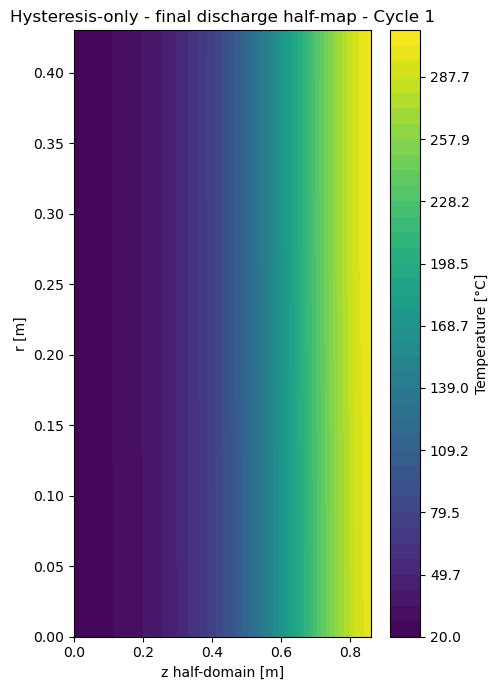

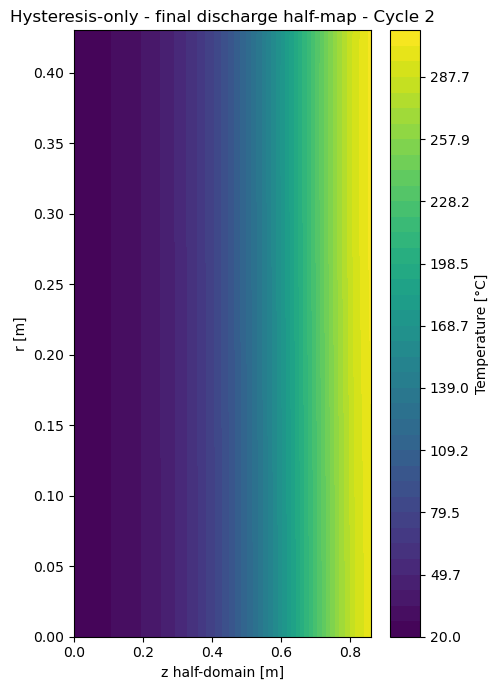

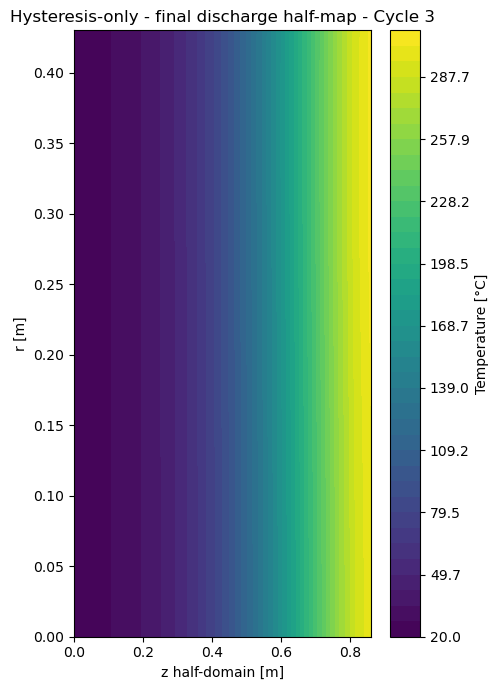

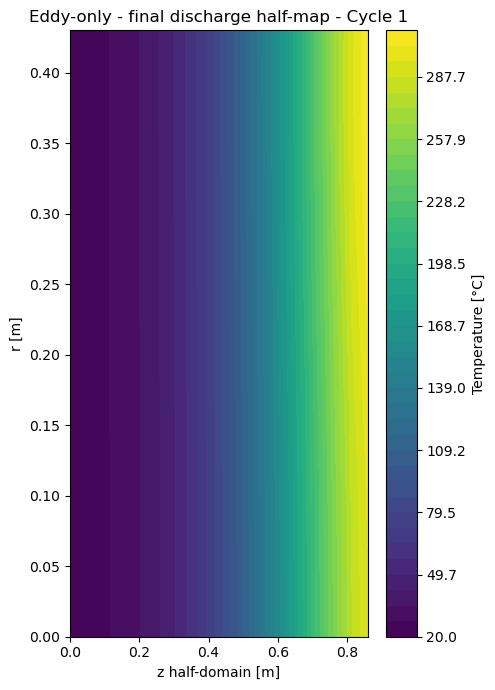

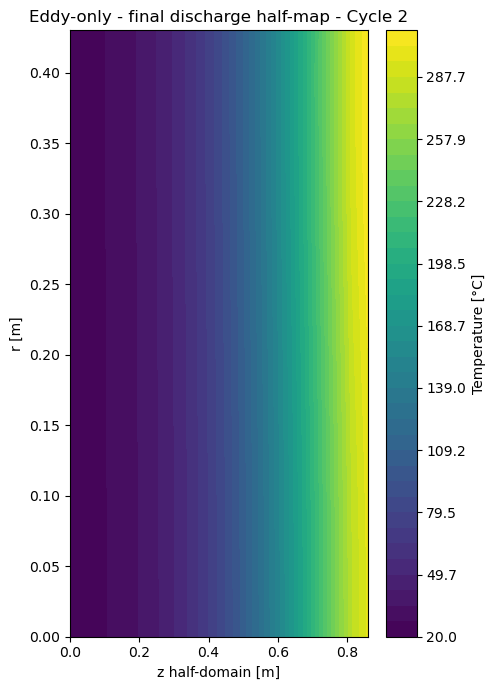

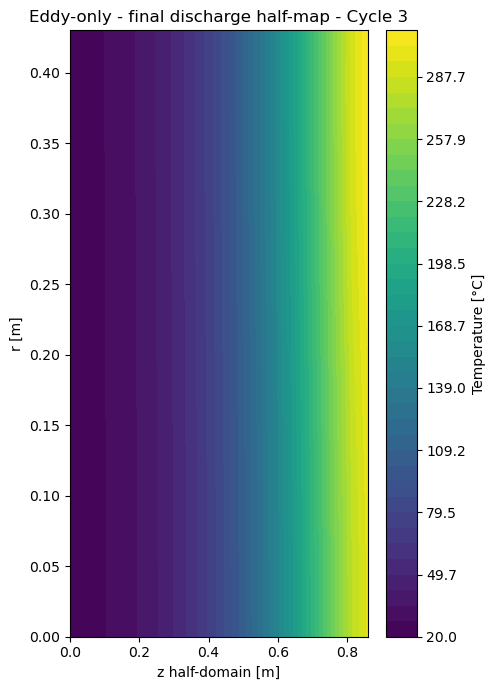

In [21]:
# ============================================================
# FINAL DISCHARGING MAPS FOR EACH CYCLE
# fixed color scale
# ============================================================

for case_name, res_case in results_same_Tmean_cycles["results"].items():

    for cyc_data in res_case["cycles"]:
        cyc = cyc_data["cycle"]
        T_half_discharge_C = cyc_data["discharge"]["T_s_final_half"] - 273.15

        plt.figure(figsize=(5, 7))

        levels = np.linspace(20, 310, 40)

        cp = plt.contourf(
            np.linspace(0, tes_Tmean.H_TES / 2, T_half_discharge_C.shape[1]),
            tes_Tmean.r,
            T_half_discharge_C,
            levels=levels
        )

        plt.colorbar(cp, label="Temperature [°C]")
        plt.xlabel("z half-domain [m]")
        plt.ylabel("r [m]")
        plt.title(f"{case_name} - final discharge half-map - Cycle {cyc}")
        plt.tight_layout()
        plt.show()

In [22]:
# ============================================================
# CHECK ACTUAL MIN/MAX OF FINAL DISCHARGE MAPS
# ============================================================

for case_name, res_case in results_same_Tmean_cycles["results"].items():

    for cyc_data in res_case["cycles"]:
        cyc = cyc_data["cycle"]
        T_half_C = cyc_data["discharge"]["T_s_final_half"] - 273.15

        print(
            case_name,
            "cycle", cyc,
            "Tmin =", np.min(T_half_C),
            "Tmax =", np.max(T_half_C)
        )

Hysteresis-only cycle 1 Tmin = 22.92761513846 Tmax = 305.18603241736275
Hysteresis-only cycle 2 Tmin = 23.02826499322191 Tmax = 305.10748262902155
Hysteresis-only cycle 3 Tmin = 23.02811216320646 Tmax = 305.1340064747411
Eddy-only cycle 1 Tmin = 22.88978803334328 Tmax = 308.3583619565808
Eddy-only cycle 2 Tmin = 23.162511587153972 Tmax = 308.65938909540296
Eddy-only cycle 3 Tmin = 23.22296381574364 Tmax = 308.5622567900284


In [23]:
# ============================================================
# CHECK CHARGING TEMPERATURES BEFORE DISCHARGE
# ============================================================

cols_check_Tmean = [
    "case",
    "cycle",
    "charge_stop_reason",
    "T_mean_target_C",
    "T_mean_end_charge_C",
    "T_max_end_charge_C",
    "T_min_end_charge_C",
    "E_input_charge_kWh",
    "E_rec_discharge_kWh",
    "round_trip_efficiency_percent"
]

display(df_same_Tmean_cycles[cols_check_Tmean].round(3))

,case,cycle,charge_stop_reason,T_mean_target_C,T_mean_end_charge_C,T_max_end_charge_C,T_min_end_charge_C,E_input_charge_kWh,E_rec_discharge_kWh,round_trip_efficiency_percent
0,Hysteresis-only,1,T_mean_target_reached,400.0,400.000,430.938,320.333,348.661,198.918,57.052
1,Hysteresis-only,2,T_mean_target_reached,400.0,400.000,464.628,291.315,272.195,198.385,72.883
2,Hysteresis-only,3,T_mean_target_reached,400.0,400.000,464.530,291.288,271.849,198.382,72.975
3,Eddy-only,1,T_mean_target_reached,400.0,400.000,526.167,220.830,283.685,200.997,70.852
4,Eddy-only,2,Tmax_safety_reached,400.0,362.827,650.000,124.646,189.883,177.367,93.409
5,Eddy-only,3,Tmax_safety_reached,400.0,363.012,650.000,127.110,191.464,176.940,92.415


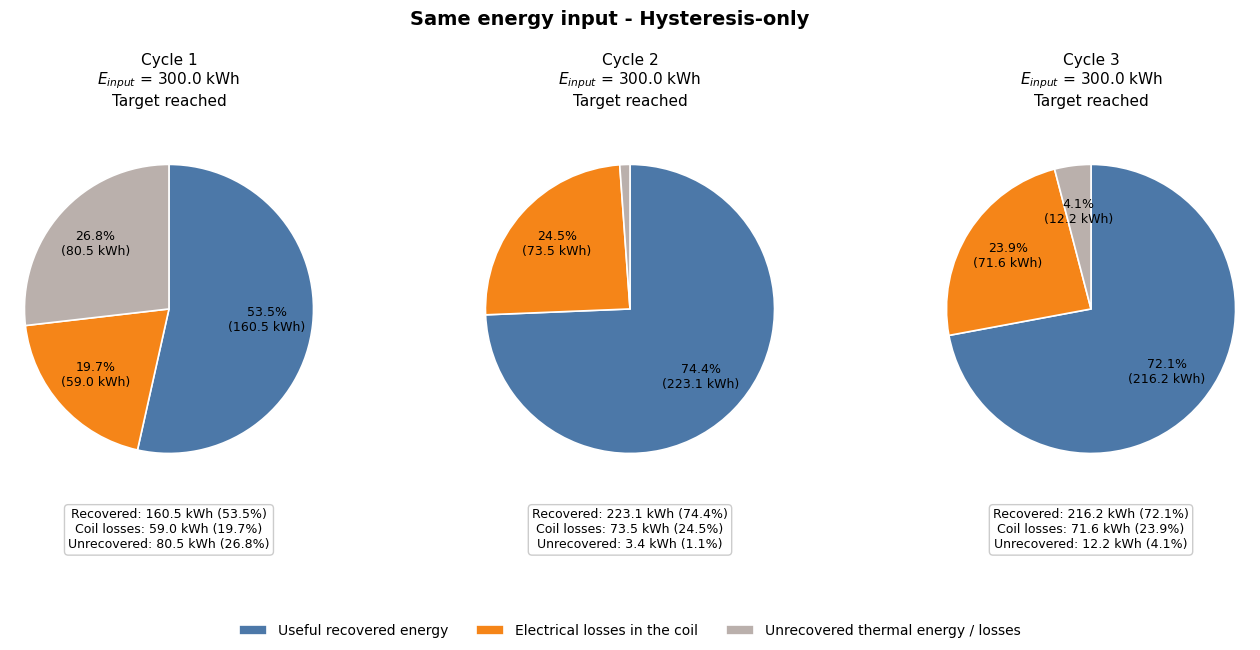

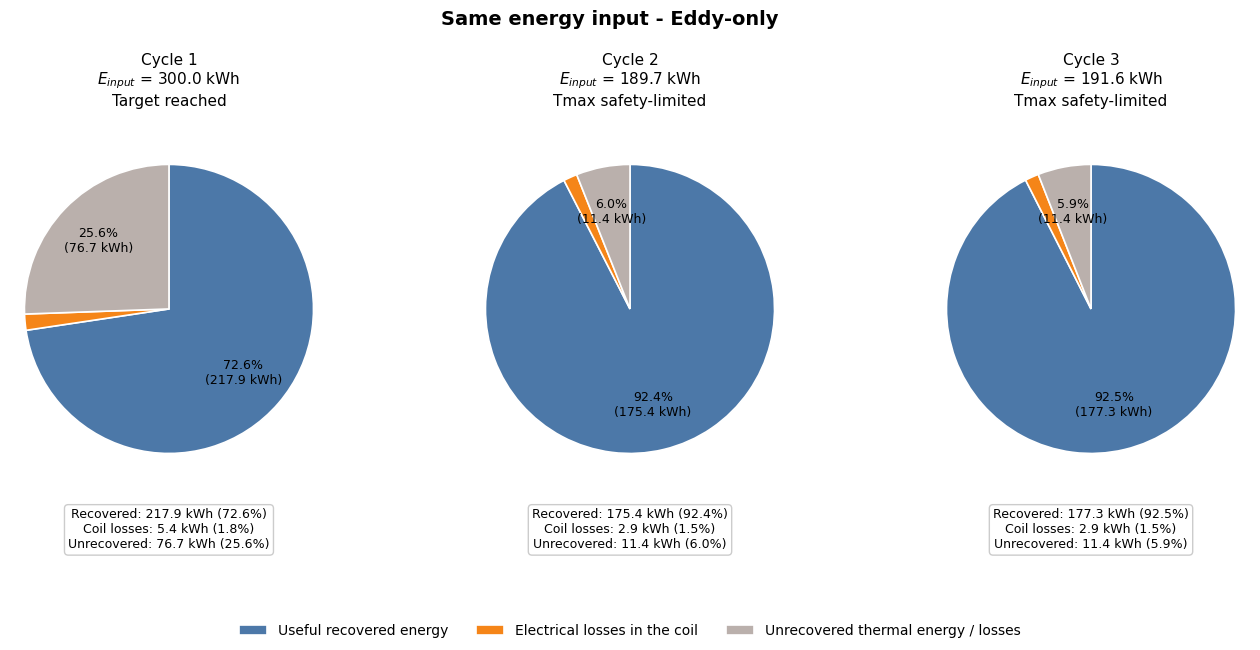

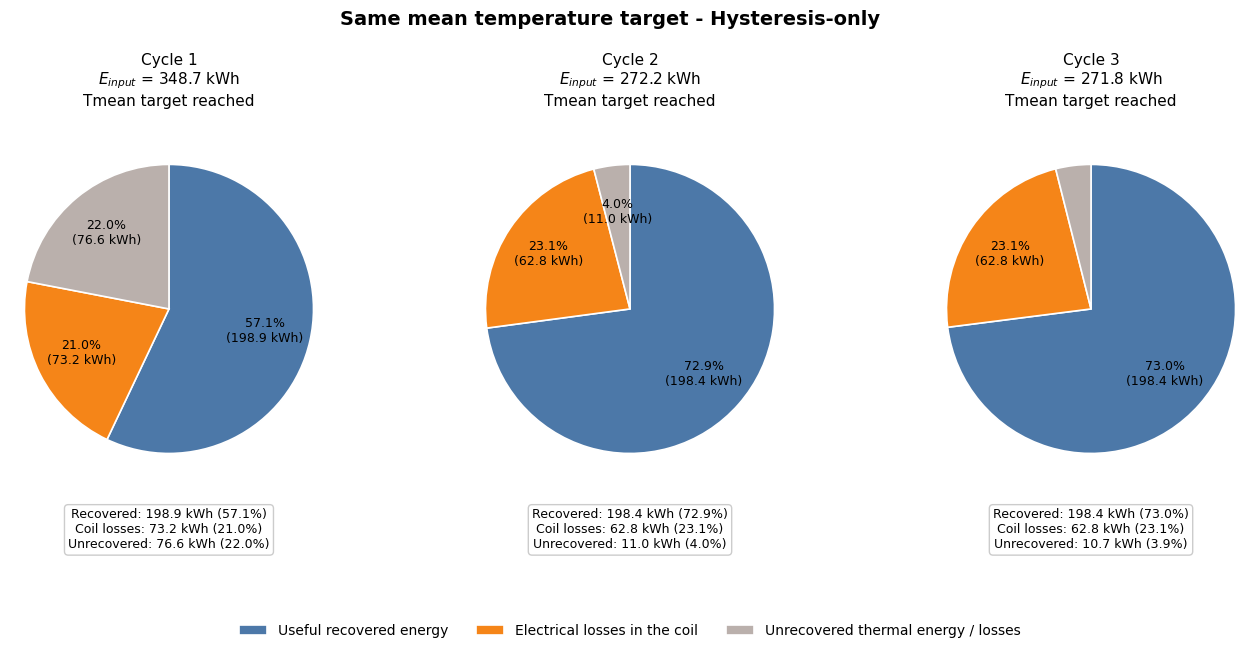

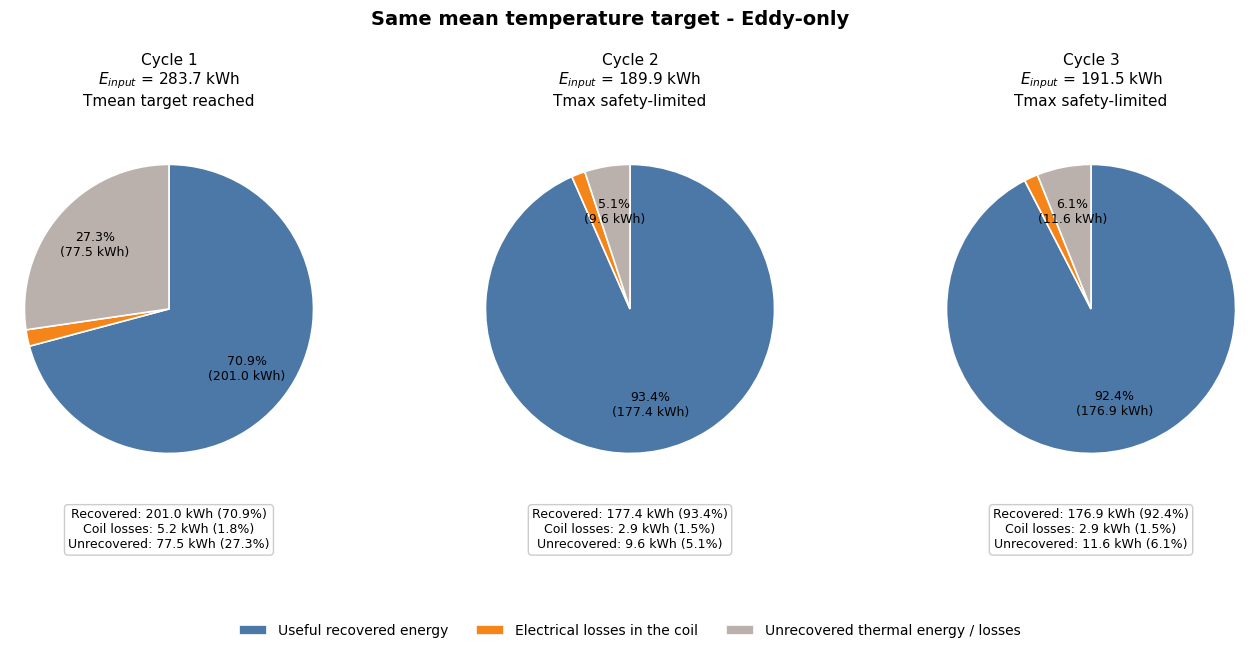

In [25]:
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# ENERGY BALANCE DATA
# E_unrecovered = E_input - E_recovered - E_coil_loss
# Units: kWh
# ============================================================

cases = {

    "Same energy input - Hysteresis-only": [
        {"cycle": 1, "E_input": 300.000, "E_rec": 160.491, "E_coil": 59.010,
         "status": "Target reached"},
        {"cycle": 2, "E_input": 300.000, "E_rec": 223.057, "E_coil": 73.543,
         "status": "Target reached"},
        {"cycle": 3, "E_input": 300.000, "E_rec": 216.207, "E_coil": 71.613,
         "status": "Target reached"},
    ],

    "Same energy input - Eddy-only": [
        {"cycle": 1, "E_input": 300.000, "E_rec": 217.912, "E_coil": 5.397,
         "status": "Target reached"},
        {"cycle": 2, "E_input": 189.726, "E_rec": 175.401, "E_coil": 2.921,
         "status": "Tmax safety-limited"},
        {"cycle": 3, "E_input": 191.608, "E_rec": 177.276, "E_coil": 2.938,
         "status": "Tmax safety-limited"},
    ],

    "Same mean temperature target - Hysteresis-only": [
        {"cycle": 1, "E_input": 348.661, "E_rec": 198.918, "E_coil": 73.160,
         "status": "Tmean target reached"},
        {"cycle": 2, "E_input": 272.195, "E_rec": 198.385, "E_coil": 62.837,
         "status": "Tmean target reached"},
        {"cycle": 3, "E_input": 271.849, "E_rec": 198.382, "E_coil": 62.771,
         "status": "Tmean target reached"},
    ],

    "Same mean temperature target - Eddy-only": [
        {"cycle": 1, "E_input": 283.685, "E_rec": 200.997, "E_coil": 5.221,
         "status": "Tmean target reached"},
        {"cycle": 2, "E_input": 189.883, "E_rec": 177.367, "E_coil": 2.903,
         "status": "Tmax safety-limited"},
        {"cycle": 3, "E_input": 191.464, "E_rec": 176.940, "E_coil": 2.939,
         "status": "Tmax safety-limited"},
    ],
}

# ============================================================
# OUTPUT FOLDER
# ============================================================

output_dir = Path("energy_balance_pie_charts")
output_dir.mkdir(exist_ok=True)

# Consistent colors across all charts
colors = [
    "#4C78A8",  # Useful recovered energy
    "#F58518",  # Electrical losses in the coil
    "#BAB0AC",  # Unrecovered thermal energy / losses
]

labels = [
    "Useful recovered energy",
    "Electrical losses in the coil",
    "Unrecovered thermal energy / losses",
]

# ============================================================
# AUTOPCT FUNCTION
# Show labels only for sufficiently large slices
# ============================================================

def make_autopct(values, threshold=4.0):
    def autopct(pct):
        total = sum(values)
        value = pct * total / 100.0
        if pct < threshold:
            return ""
        return f"{pct:.1f}%\n({value:.1f} kWh)"
    return autopct

# ============================================================
# PLOTTING FUNCTION
# ============================================================

def plot_case(case_name, cycles, filename):

    fig, axes = plt.subplots(1, 3, figsize=(16, 6.5))

    for ax, data in zip(axes, cycles):

        E_input = data["E_input"]
        E_rec = data["E_rec"]
        E_coil = data["E_coil"]
        E_unrecovered = E_input - E_rec - E_coil

        # Avoid negative tiny numerical values
        if abs(E_unrecovered) < 1e-10:
            E_unrecovered = 0.0

        values = [E_rec, E_coil, E_unrecovered]

        p_rec = 100 * E_rec / E_input
        p_coil = 100 * E_coil / E_input
        p_unrec = 100 * E_unrecovered / E_input

        ax.pie(
            values,
            colors=colors,
            startangle=90,
            counterclock=False,
            autopct=make_autopct(values, threshold=4.0),
            pctdistance=0.68,
            wedgeprops={"edgecolor": "white", "linewidth": 1.2},
            textprops={"fontsize": 9}
        )

        ax.set_title(
            f"Cycle {data['cycle']}\n"
            f"$E_{{input}}$ = {E_input:.1f} kWh\n"
            f"{data['status']}",
            fontsize=11
        )

        ax.axis("equal")

        # Summary box below each pie
        summary_text = (
            f"Recovered: {E_rec:.1f} kWh ({p_rec:.1f}%)\n"
            f"Coil losses: {E_coil:.1f} kWh ({p_coil:.1f}%)\n"
            f"Unrecovered: {E_unrecovered:.1f} kWh ({p_unrec:.1f}%)"
        )

        ax.text(
            0, -1.38, summary_text,
            ha="center", va="top", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="0.8")
        )

    fig.suptitle(case_name, fontsize=14, fontweight="bold")

    fig.legend(
        labels,
        loc="lower center",
        ncol=3,
        frameon=False,
        fontsize=10
    )

    plt.subplots_adjust(top=0.82, bottom=0.22, wspace=0.45)

    # Save PNG
    plt.savefig(
        output_dir / f"{filename}.png",
        dpi=300,
        bbox_inches="tight"
    )

    # Save PDF
    plt.savefig(
        output_dir / f"{filename}.pdf",
        bbox_inches="tight"
    )

    plt.show()

# ============================================================
# GENERATE THE FOUR FIGURES
# ============================================================

plot_case(
    "Same energy input - Hysteresis-only",
    cases["Same energy input - Hysteresis-only"],
    "same_energy_hysteresis"
)

plot_case(
    "Same energy input - Eddy-only",
    cases["Same energy input - Eddy-only"],
    "same_energy_eddy"
)

plot_case(
    "Same mean temperature target - Hysteresis-only",
    cases["Same mean temperature target - Hysteresis-only"],
    "same_Tmean_hysteresis"
)

plot_case(
    "Same mean temperature target - Eddy-only",
    cases["Same mean temperature target - Eddy-only"],
    "same_Tmean_eddy"
)

# analysis


In [ ]:
#comparison
# Diameter TES, Aspect ratio TES,insulation thickness,tube diameter,tube thikness, distance between turns/tube diameter ext.
geom_ref=(2.5,2,0.2,0.025,0.002,2)


# magnetita 


In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(10, 8))
# Conversiones de unidades
freqx_kHz = freqx / 1e3
freq1_kHz = freq1 / 1e3

W_to_kW = 1e-3
Wm3_to_kWm3 = 1e-3
# =====================================================
# Potencias vs corriente (frecuencia fija) — STACKED
# =====================================================
P_eddy = IHTES_mag.Peddy(freq1, Ix) * W_to_kW
P_hys  = IHTES_mag.Phys(freq1, Ix, T_TES_ref) * W_to_kW
P_coil = IHTES_mag.Pcoil(freq1, Ix, Tcoil_ref) * W_to_kW
P_conv = IHTES_mag.Pconv(freq1, Ix, Tcoil_ref, T_TES_ref) * W_to_kW
P_in=IHTES_mag.Pin(freq1, Ix, Tcoil_ref, T_TES_ref) * W_to_kW

P0 = np.zeros_like(Ix)
P1 = P_eddy
P2 = P1 + P_hys
P3 = P2 + P_coil
P4 = P3 + P_conv

ax[0, 0].fill_between(Ix, P0, P1, label=r'$P_{\mathrm{eddy}}$', alpha=0.8)
ax[0, 0].fill_between(Ix, P1, P2, label=r'$P_{\mathrm{hys}}$', alpha=0.8)
ax[0, 0].fill_between(Ix, P2, P3, label=r'$P_{\mathrm{coil}}$', alpha=0.8)
ax[0, 0].fill_between(Ix, P3, P4, label=r'$P_{\mathrm{conv}}$', alpha=0.8)

ax[0, 0].plot(Ix, P_in, 'k--', lw=1.5, label=r'$P_{\mathrm{in}}$')

ax[0, 0].set_xlabel(r'$I\;[\mathrm{A}]$')
ax[0, 0].set_ylabel(r'$P\;[\mathrm{kW}]$')
ax[0, 0].set_title(rf'$f = {freq1_kHz:.1f}\,\mathrm{{kHz}}$')
ax[0, 0].legend(fontsize=8)

# =====================================================
# Potencias vs frecuencia (corriente fija) — STACKED
# =====================================================
P_eddy = IHTES_mag.Peddy(freqx, I1) * W_to_kW
P_hys  = IHTES_mag.Phys(freqx, I1, T_TES_ref) * W_to_kW
P_coil = IHTES_mag.Pcoil(freqx, I1, Tcoil_ref) * W_to_kW
P_conv = IHTES_mag.Pconv(freqx, I1, Tcoil_ref, T_TES_ref) * W_to_kW
P_in = IHTES_mag.Pin(freqx, I1, Tcoil_ref, T_TES_ref) * W_to_kW
P0 = np.zeros_like(freqx_kHz)
P1 = P_eddy
P2 = P1 + P_hys
P3 = P2 + P_coil
P4 = P3 + P_conv

ax[0, 1].fill_between(freqx_kHz, P0, P1, label=r'$P_{\mathrm{eddy}}$', alpha=0.8)
ax[0, 1].fill_between(freqx_kHz, P1, P2, label=r'$P_{\mathrm{hys}}$', alpha=0.8)
ax[0, 1].fill_between(freqx_kHz, P2, P3, label=r'$P_{\mathrm{coil}}$', alpha=0.8)
ax[0, 1].fill_between(freqx_kHz, P3, P4, label=r'$P_{\mathrm{conv}}$', alpha=0.8)

ax[0, 1].plot(freqx_kHz, P_in, 'k--', lw=1.5, label=r'$P_{\mathrm{in}}$')

ax[0, 1].set_xlabel(r'$f\;[\mathrm{kHz}]$')
ax[0, 1].set_ylabel(r'$P\;[\mathrm{kW}]$')
ax[0, 1].set_title(rf'$I = {I1}\,\mathrm{{A}}$')
ax[0, 1].legend(fontsize=8)
# =====================================================
# Densidad de potencia vs corriente — STACKED
# =====================================================
qv_eddy = IHTES_mag.qv_eddy(freq1, Ix) * Wm3_to_kWm3
qv_hys  = IHTES_mag.qv_hys(freq1, Ix, T_TES_ref) * Wm3_to_kWm3

q0 = np.zeros_like(Ix)
q1 = qv_eddy
q2 = q1 + qv_hys

ax[1, 0].fill_between(Ix, q0, q1, label=r'$q_{v,\mathrm{eddy}}$', alpha=0.8)
ax[1, 0].fill_between(Ix, q1, q2, label=r'$q_{v,\mathrm{hys}}$', alpha=0.8)
ax[1, 0].plot(Ix, q2, 'k--', lw=1.5, label=r'$q_v$')

qvplot2 = ax[1, 0].twinx()
qvplot2.plot(Ix, IHTES_mag.eta_ind(freq1, Ix, Tcoil_ref, T_TES_ref),
             ls='-',c='darkred', label=r'$\eta_{\mathrm{ind}}$')
qvplot2.plot(Ix,
             IHTES_mag.eta_ind(freq1, Ix, Tcoil_ref, T_TES_ref)
             * IHTES_mag.eta_conv(freq1),
             ls='-', c='black',label=r'$\eta_{\mathrm{ind}}\eta_{\mathrm{conv}}$')

ax[1, 0].set_xlabel(r'$I\;[\mathrm{A}]$')
ax[1, 0].set_ylabel(r'$q_v\;[\mathrm{kW\,m^{-3}}]$')
qvplot2.set_ylabel(r'$\eta\;[-]$')

ax[1, 0].set_title(rf'$f = {freq1_kHz:.1f}\,\mathrm{{kHz}}$')
ax[1, 0].legend(loc='upper left', fontsize=8)
qvplot2.legend(loc='upper right', fontsize=8)

# =====================================================
# Densidad de potencia vs frecuencia — STACKED
# =====================================================
qv_eddy = IHTES_mag.qv_eddy(freqx, I1) * Wm3_to_kWm3
qv_hys  = IHTES_mag.qv_hys(freqx, I1, T_TES_ref) * Wm3_to_kWm3

q0 = np.zeros_like(freqx_kHz)
q1 = qv_eddy
q2 = q1 + qv_hys

ax[1, 1].fill_between(freqx_kHz, q0, q1, label=r'$q_{v,\mathrm{eddy}}$', alpha=0.8)
ax[1, 1].fill_between(freqx_kHz, q1, q2, label=r'$q_{v,\mathrm{hys}}$', alpha=0.8)
ax[1, 1].plot(freqx_kHz, q2, 'k--', lw=1.5, label=r'$q_v$')

qvplot22 = ax[1, 1].twinx()
qvplot22.plot(freqx_kHz,
              IHTES_mag.eta_ind(freqx, I1, Tcoil_ref, T_TES_ref),
              ls='-',c='darkred', label=r'$\eta_{\mathrm{ind}}$')
qvplot22.plot(freqx_kHz,
              IHTES_mag.eta_ind(freqx, I1, Tcoil_ref, T_TES_ref)
              * IHTES_mag.eta_conv(freqx),
              ls='-',c='black', label=r'$\eta_{\mathrm{ind}}\eta_{\mathrm{conv}}$')

ax[1, 1].set_xlabel(r'$f\;[\mathrm{kHz}]$')
ax[1, 1].set_ylabel(r'$q_v\;[\mathrm{kW\,m^{-3}}]$')
qvplot22.set_ylabel(r'$\eta\;[-]$')

ax[1, 1].set_title(rf'$I = {I1}\,\mathrm{{A}}$')
ax[1, 1].legend(loc='upper left', fontsize=8)
qvplot22.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('case_study_mag.png', dpi=300)
plt.show()

In [ ]:

IHTES_mag = IHTES(TH_mag, EM_mag, HYS_mag, geom_ref)
